# MODELADO Libere Con PCA

In [ ]:
# Cargar librerias
import numpy as np 
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split 
np.random.seed(0)

from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')


from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

import os

In [2]:
# Cargar datos
path = os.path.join('Datos', 'Transformados', 'df_limpio_con_clusters.csv')
df = pd.read_csv(path)

path_clustering = os.path.join('Datos', 'Transformados', 'df_modelado_clustering.csv')
df_clustering = pd.read_csv(path_clustering, sep=",", low_memory=False)

path_tiempo = os.path.join('Datos', 'Transformados', 'datos_meteorologicos_2023.csv')
df_tiempo = pd.read_csv(path_tiempo)


In [46]:
#Tamaño
print(f"Df_Limpio: {df.shape}")
print(f"Df_Tiempo: {df_tiempo.shape}")

Df_Limpio: (51707, 47)
Df_Tiempo: (3285, 22)


In [47]:
#Tipo de variables
print(df.dtypes)
print(df_tiempo.dtypes)

booked_at                          object
checkin_time                       object
lead_time                           int64
lenght_of_stay                      int64
checkin_month                      object
checkin_day                        object
adult_count                         int64
child_count                         int64
origin                             object
travel_agency_name                 object
requested_category                 object
requested_category_name            object
asset                              object
asset_type                         object
brand                              object
available_units                     int64
business_segment                   object
rate                               object
rate_group_name                    object
rate_type                          object
completed_entry_forms_count       float64
all_entry_forms_completed          object
returning_inhabitant               object
recurrence                        

In [48]:
#Visualizar las primeras 10 filas:
print(f"Df_limpio: {df.head(10)}")
print(f"Df_tiempo: {df_tiempo.head(10)}")


Df_limpio:              booked_at         checkin_time  lead_time  lenght_of_stay  \
0  2022-11-26 16:10:00  2023-01-01 12:00:00         36               1   
1  2022-12-21 17:27:00  2023-01-01 13:09:00         11               9   
2  2022-09-21 19:46:00  2023-01-01 15:00:00        102               6   
3  2022-09-24 12:09:00  2023-01-01 15:00:00         99               1   
4  2022-10-18 07:12:00  2023-01-01 15:00:00         75               1   
5  2022-11-25 17:50:00  2023-01-01 15:00:00         37               1   
6  2022-11-26 04:10:00  2023-01-01 15:00:00         36               2   
7  2022-12-02 20:02:00  2023-01-01 15:00:00         30               1   
8  2022-12-04 23:18:00  2023-01-01 15:00:00         28               2   
9  2022-12-11 12:51:00  2023-01-01 15:00:00         21               7   

  checkin_month checkin_day  adult_count  child_count           origin  \
0       January      Sunday            1            0  channel_manager   
1       January      Sunda

Quedarnos con las variables del df que no tiene relacion con cancelaciones.

In [49]:
columnas_sin_inf_cancelaciones = [
    'checkin_time','lead_time','lenght_of_stay','checkin_month','checkin_day','adult_count','child_count',
    'origin','requested_category','asset','asset_type','business_segment','rate_type',
    'returning_inhabitant','recurrence','libere_community','reservation_net_value',
    'zona_roja_mes','Estacion_Estancia',
    'Estacion_Reserva','estancia_en_festivo','estancia_en_finde','City', 'mes_checkin_numerico',
    'reservation_checkin_month_diff', 'Reserva_Dia_Semana', 'status'
]


df_sin_inf_cancell = df[columnas_sin_inf_cancelaciones]
print(df_sin_inf_cancell)

              checkin_time  lead_time  lenght_of_stay checkin_month  \
0      2023-01-01 12:00:00         36               1       January   
1      2023-01-01 13:09:00         11               9       January   
2      2023-01-01 15:00:00        102               6       January   
3      2023-01-01 15:00:00         99               1       January   
4      2023-01-01 15:00:00         75               1       January   
...                    ...        ...             ...           ...   
51702  2023-12-31 15:00:00         79               1      December   
51703  2023-12-31 15:00:00         79               1      December   
51704  2023-12-31 15:00:00         75               1      December   
51705  2023-12-31 15:00:00         75               1      December   
51706  2023-12-31 15:00:00          1               2      December   

      checkin_day  adult_count  child_count           origin  \
0          Sunday            1            0  channel_manager   
1          Sunday  

Juntar ambos df-s por (Fecha, Hora, Ciudad)

In [50]:
# Cambiar nombre a la ciudad Donosti (Salen diferente)
df_sin_inf_cancell['City'] = df_sin_inf_cancell['City'].replace({'Donostia': 'Donosti'})

In [51]:
# 1. Crear FECHA desde checkin_time en df reservas
df_sin_inf_cancell['checkin_time'] = pd.to_datetime(df_sin_inf_cancell['checkin_time'])
df_sin_inf_cancell['fecha'] = df_sin_inf_cancell['checkin_time'].dt.date

# 2. Convertir FECHA en df_tiempo (es diaria)
df_tiempo['fecha'] = pd.to_datetime(df_tiempo['fecha']).dt.date


# 3. Merge SOLO por ciudad + fecha
df_junto = df_sin_inf_cancell.merge(
    df_tiempo,
    left_on=['City', 'fecha'],
    right_on=['ciudad', 'fecha'],
    how='left'
)
print(df_junto)

             checkin_time  lead_time  lenght_of_stay checkin_month  \
0     2023-01-01 12:00:00         36               1       January   
1     2023-01-01 13:09:00         11               9       January   
2     2023-01-01 15:00:00        102               6       January   
3     2023-01-01 15:00:00         99               1       January   
4     2023-01-01 15:00:00         75               1       January   
...                   ...        ...             ...           ...   
51702 2023-12-31 15:00:00         79               1      December   
51703 2023-12-31 15:00:00         79               1      December   
51704 2023-12-31 15:00:00         75               1      December   
51705 2023-12-31 15:00:00         75               1      December   
51706 2023-12-31 15:00:00          1               2      December   

      checkin_day  adult_count  child_count           origin  \
0          Sunday            1            0  channel_manager   
1          Sunday            1 

 Transformación Variables:
 - Eliminar variable "checkin_time" (Necesaria para el merge).
 - Tranfromar variable target "status" a tipo booleana

In [52]:
#Eliminar "checkin_time"
df_junto = df_junto.drop(columns="checkin_time")

#Tranformar Variable "status"
df_junto["status_bool"] = df_junto["status"].map(
    {"checked_out": False,
     "cancelled": True}
)
df_junto["status_bool"]

0        False
1        False
2        False
3        False
4        False
         ...  
51702    False
51703    False
51704    False
51705    False
51706     True
Name: status_bool, Length: 51707, dtype: bool

In [53]:
# Reemplazar la "," po el "." en la variables numericas sobre el tiempo:

# Primero asegurarnos de que las columnas de temperatura sean string
cols_temp = ['tmax', 'tmin', 'tmed', 'hrMedia', 'hrMax', 'hrMin', 'prec', 'dir', 'velmedia', 'racha']  

for col in cols_temp:
    # Convertir category a str
    df_junto[col] = df_junto[col].astype(str)
    # Reemplazar coma por punto
    df_junto[col] = df_junto[col].str.replace(',', '.', regex=False)
    # Convertir a float
    df_junto[col] = df_junto[col].astype(float)

# Comprobar
print(df_junto['tmax'].head(2))


0    21.4
1    21.4
Name: tmax, dtype: float64


In [54]:
#COnvertir al tipo correspodinete, sobre todo las varibales en relacion al tiempo. (Las otras ya estan)
# Bucle para convertir tipos correctamente
for col in df_junto.columns:
    # Si es object
    if df_junto[col].dtype == 'object':
        unique_vals = df_junto[col].dropna().astype(str).unique()  # asegurar que sean strings
        
        # Solo 0/1 → booleano
        if set(unique_vals).issubset({'0', '1', 0, 1}):
            df_junto[col] = df_junto[col].astype(bool)
        
        else:
            # Intentar convertir a float
            try:
                df_junto[col] = pd.to_numeric(df_junto[col], errors='raise')
            except:
                # Si no se puede → category
                df_junto[col] = df_junto[col].astype('category')
                
    # Si ya es booleano → opcional convertir a int
    elif df_junto[col].dtype == 'bool':
        df_junto[col] = df_junto[col].astype(int)


# Comprobar tipos finales
print("tmax:", df_junto["tmax"].dtypes)        # Debe salir float64
print("status_bool:", df_junto["status_bool"].dtypes)  # Debe seguir siendo int64


tmax: float64
status_bool: int64


### Seleccion Variables para los Modelos
1. Numericas: Se analizara su correlacion
2. Booleanas: 
3. Categoricas:

#### NUMERICAS

In [55]:
# 1. NUMERICAS:
# Seleccionar todas las columnas numéricas (int + float)

# Asegurarse de que status_bool es numérico
df_junto['status_bool'] = df_junto['status_bool'].astype(int)
# Extraer nombres de columnas numéricas
variables_numericas = df_junto.select_dtypes(include=['number']).columns.tolist()


# Verificar que 'status_bool' esté incluido
if 'status_bool' not in variables_numericas:
    variables_numericas.append('status_bool')

# Calcular correlación con status_bool
corr_df = df_junto[variables_numericas].corr()
corr_num = corr_df['status_bool'].drop('status_bool').sort_values(ascending=False)

print(corr_num.head(5))



lead_time                         0.215193
reservation_checkin_month_diff    0.210555
zona_roja_mes                     0.164497
lenght_of_stay                    0.132539
adult_count                       0.099740
Name: status_bool, dtype: float64


Total de NaN en variables meteorológicas después de imputación:
tmed    0
tmin    0
tmax    0
prec    0
dtype: int64
Variables numéricas seleccionadas (|corr| >= 0.05 + variables climáticas):
['lead_time', 'reservation_checkin_month_diff', 'zona_roja_mes', 'lenght_of_stay', 'adult_count', 'reservation_net_value', 'estancia_en_finde', 'tmed', 'tmin', 'tmax', 'prec']
Matriz de correlación entre variables seleccionadas:
                                lead_time  reservation_checkin_month_diff  \
lead_time                        1.000000                        0.975990   
reservation_checkin_month_diff   0.975990                        1.000000   
zona_roja_mes                    0.560852                        0.596894   
lenght_of_stay                   0.097910                        0.096510   
adult_count                      0.217532                        0.215002   
reservation_net_value            0.177165                        0.175387   
estancia_en_finde                0.09869

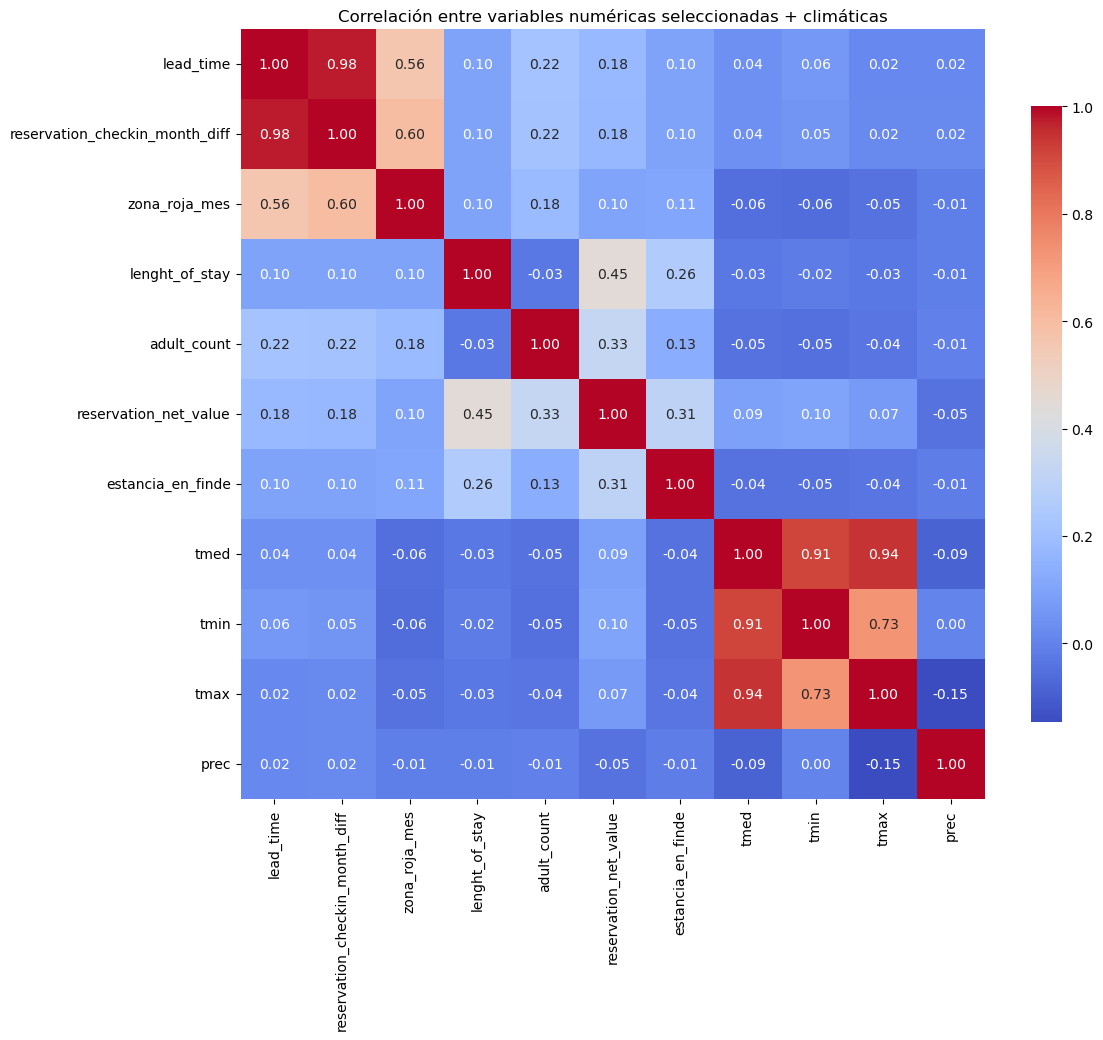

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# -----------------------------
# Umbral de correlación con el target
umbral = 0.05

# Variables numéricas con |corr| >= 0.05
vars_numericas_filtradas = corr_num[corr_num.abs() >= umbral].index.tolist()

# Agregar explícitamente variables meteorológicas aunque no superen el umbral
vars_adicionales = ["tmed", "tmin", "tmax", "prec"]

# -----------------------------
# Imputar valores faltantes en variables meteorológicas
# Explicación:
# - interpolate(): rellena NaN usando interpolación lineal
# - ffill(): rellena NaN restantes hacia adelante
# - bfill(): rellena NaN restantes hacia atrás
df_junto[vars_adicionales] = df_junto[vars_adicionales].interpolate(method='linear')
df_junto[vars_adicionales] = df_junto[vars_adicionales].fillna(method='ffill')
df_junto[vars_adicionales] = df_junto[vars_adicionales].fillna(method='bfill')

# Verificar que no queden NaN en las variables meteorológicas
print("Total de NaN en variables meteorológicas después de imputación:")
print(df_junto[vars_adicionales].isna().sum())

# -----------------------------
# Combinar todas las variables para modelado
for var in vars_adicionales:
    if var not in vars_numericas_filtradas:
        vars_numericas_filtradas.append(var)

print("Variables numéricas seleccionadas (|corr| >= 0.05 + variables climáticas):")
print(vars_numericas_filtradas)

# -----------------------------
# Revisar multicolinealidad entre las variables seleccionadas
corr_variables = df_junto[vars_numericas_filtradas].corr()

print("Matriz de correlación entre variables seleccionadas:")
print(corr_variables)

# Heatmap de correlación
plt.figure(figsize=(12, 10))
sns.heatmap(corr_variables, annot=True, fmt=".2f", cmap="coolwarm", cbar_kws={'shrink': 0.8})
plt.title("Correlación entre variables numéricas seleccionadas + climáticas")
plt.show()

# -----------------------------
# Observaciones sobre la decisión:
# - Variables con mayor correlación con el target:
#   lead_time, reservation_checkin_month_diff, zona_roja_mes, lenght_of_stay
# - Variables con señal débil pero incluidas (|corr| ~ 0.05-0.08):
#   adult_count, reservation_net_value, estancia_en_finde
# - Se incluyen también variables meteorológicas:
#   tmed, tmin, tmax, prec
# - Ninguna variable presenta alta correlación entre sí (>0.7)
# - Decisión final: usar todas las variables seleccionadas con |corr| >= 0.05
#   y las variables climáticas para modelar cancelaciones
# -----------------------------


#### BINARIAS

In [57]:
# 2.  BINARIAS

# 2.1 Detectar columnas binarias (0/1 o True/False)
binarias_vars = []

for columna in df_junto.columns:
    valores_unicos = df_junto[columna].dropna().unique()
    valores_set = set(valores_unicos)
    
    if valores_set.issubset({0, 1}) or valores_set.issubset({True, False}):
        # Excluir el target
        if columna != 'status_bool':
            binarias_vars.append(columna)

print("Variables binarias detectadas:")
print(binarias_vars)

Variables binarias detectadas:
['zona_roja_mes', 'estancia_en_festivo', 'estancia_en_finde']


In [58]:
# 2.2 Revisar impacto sobre el target
target_col = 'status_bool'

for columna in binarias_vars:
    medias = df_junto.groupby(columna)[target_col].mean()
    print(f'\nColumna: {columna}')
    print(medias)


Columna: zona_roja_mes
zona_roja_mes
0    0.191143
1    0.352428
Name: status_bool, dtype: float64

Columna: estancia_en_festivo
estancia_en_festivo
0    0.229083
1    0.254162
Name: status_bool, dtype: float64

Columna: estancia_en_finde
estancia_en_finde
0    0.198288
1    0.267638
Name: status_bool, dtype: float64


In [59]:
# 2.3 Filtrar variables binarias relevantes
bin_vars_relevantes = []

umbral_diferencia = 0.02  # 2%

for columna in binarias_vars:
    medias = df_junto.groupby(columna)[target_col].mean()
    diferencia = abs(medias.iloc[1] - medias.iloc[0])
    
    if diferencia > umbral_diferencia:
        bin_vars_relevantes.append(columna)

print("\nVariables binarias relevantes (diferencia > 0.02):")
print(bin_vars_relevantes)


# -----------------------------
# Justificación:
# Consideramos relevantes aquellas variables binarias donde la diferencia 
# en la media del target entre los dos grupos supera el 2%. Diferencias pequeñas
# pueden aportar información combinada con otras variables, pero se priorizan
# aquellas con un impacto más claro sobre la cancelación.
# -----------------------------



Variables binarias relevantes (diferencia > 0.02):
['zona_roja_mes', 'estancia_en_festivo', 'estancia_en_finde']


#### CATEGORICAS

In [60]:
# 3.  CATEGÓRICAS 

# 3.1 Detectar columnas categóricas
cat_vars = []

for columna in df_junto.columns:
    if df_junto[columna].dtype.name in ['object', 'category']:
        # Excluir la columna target
        if columna != 'status_bool':
            cat_vars.append(columna)

print("Variables categóricas detectadas:")
print(cat_vars)

Variables categóricas detectadas:
['checkin_month', 'checkin_day', 'origin', 'requested_category', 'asset', 'asset_type', 'business_segment', 'rate_type', 'returning_inhabitant', 'libere_community', 'Estacion_Estancia', 'Estacion_Reserva', 'City', 'Reserva_Dia_Semana', 'status', 'fecha', 'indicativo', 'nombre', 'provincia', 'horatmin', 'horatmax', 'horaracha', 'horaHrMax', 'horaHrMin', 'ciudad', 'codigo_ccaa']


In [61]:
# 3.2 Analizar impacto de variables categóricas sobre el target

target_col = 'status_bool'

for columna in cat_vars:
    # Calcular la media del target por cada categoría
    medias = df_junto.groupby(columna)[target_col].mean().sort_values(ascending=False)
    
    #print(f'\nVariable categórica: {columna}')
    #display(medias.head(10))  # Mostrar las 10 categorías con mayor media

In [62]:
# 3.3 Selección de variables categóricas relevantes

cat_vars_significativas = []

umbral_cat = 0.03  # 3%

for col in cat_vars:
    # Calcular la media del target por cada categoría
    medias_target = df_junto.groupby(col)[target_col].mean()
    
    # Diferencia máxima entre las categorías
    diferencia_max = medias_target.max() - medias_target.min()
    
    # Filtrar si supera el umbral
    if diferencia_max > umbral_cat:
        cat_vars_significativas.append(col)

print("\nVariables categóricas consideradas relevantes (diferencia > 0.03):")
print(cat_vars_significativas)

# Justificación:
# Se consideran relevantes aquellas variables categóricas donde la diferencia
# entre la categoría con mayor y menor media del target ('status_bool')
# supera el 3%. Esto refleja un impacto más claro sobre la probabilidad
# de cancelación, mientras que diferencias menores podrían aportar menos información.



Variables categóricas consideradas relevantes (diferencia > 0.03):
['checkin_month', 'checkin_day', 'origin', 'requested_category', 'asset', 'business_segment', 'rate_type', 'returning_inhabitant', 'libere_community', 'Estacion_Reserva', 'City', 'Reserva_Dia_Semana', 'status', 'fecha', 'indicativo', 'nombre', 'provincia', 'horatmin', 'horatmax', 'horaracha', 'horaHrMax', 'horaHrMin', 'ciudad', 'codigo_ccaa']


### Crear DataFrame Final para Modelado 

In [63]:
# CREAR DATAFRAME FINAL PARA MODELADO

# Unir todas las variables seleccionadas con el target
df_modelado_final = df_junto[
    vars_numericas_filtradas +       # Variables numéricas seleccionadas
    bin_vars_relevantes +            # Variables binarias relevantes
    cat_vars_significativas +        # Variables categóricas relevantes
    [target_col]                     # Target
]

# Verificar dimensiones
print(f"Dimensiones: {df_modelado_final.shape}")


Dimensiones: (51707, 39)


In [64]:
# Variables meteorológicas
vars_meteorologicas = ["tmed", "tmin", "tmax", "prec"]

# Comprobar NaN en df_modelado_final
print("Valores faltantes en variables meteorológicas de df_modelado_final:")
print(df_modelado_final[vars_meteorologicas].isna().sum())

# Total de NaN en todas las variables meteorológicas
print("\nTotal de NaN en todas las variables meteorológicas:", 
      df_modelado_final[vars_meteorologicas].isna().sum().sum())


Valores faltantes en variables meteorológicas de df_modelado_final:
tmed    0
tmin    0
tmax    0
prec    0
dtype: int64

Total de NaN en todas las variables meteorológicas: 0


In [65]:
#Eliminar columnas de tipo fecha ya que no aportaran ningun tipo de informacion para el modelo 
df_modelado_final = df_modelado_final.drop(columns=["fecha", "horatmin", "horatmax", "horaracha", "horaHrMax", "horaHrMin", "status"])

### Train / Test

In [72]:
X = df_modelado_final.drop(columns=[target_col])
y = df_modelado_final[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Tamaño X_train: {X_train.shape}, X_test: {X_test.shape}")

Tamaño X_train: (41365, 31), X_test: (10342, 31)


### Formatear el Data Frame (Numericas = Escalar, Categoricas = Dummies)

#### Escalar Variables Numericas

In [73]:
# Función para escalar variables numéricas con MinMaxScaler 
from sklearn.preprocessing import MinMaxScaler

def escalar_numericas_train_test(X_train, X_test, columnas_numericas=None):
    """
    Escala únicamente las columnas numéricas de un DataFrame usando MinMaxScaler.
    Primero ajusta el scaler con el conjunto de entrenamiento y luego transforma
    tanto train como test para evitar data leakage.

    Parámetros
    ----------
    X_train : pd.DataFrame
        DataFrame de entrenamiento con todas las variables.
    X_test : pd.DataFrame
        DataFrame de test con todas las variables.
    columnas_numericas : list, opcional
        Lista de columnas numéricas a escalar. Si no se pasa, se detectan automáticamente.

    Retorna
    -------
    X_train_scaled : pd.DataFrame
        DataFrame de entrenamiento con las columnas numéricas escaladas entre 0 y 1.
    X_test_scaled : pd.DataFrame
        DataFrame de test con las columnas numéricas escaladas usando los parámetros del scaler ajustado en train.
    """
    X_train_copy = X_train.copy()
    X_test_copy = X_test.copy()

    # Detectar columnas numéricas si no se pasan
    if columnas_numericas is None:
        columnas_numericas = X_train_copy.select_dtypes(include=['int64', 'float64']).columns.tolist()

    scaler = MinMaxScaler()
    X_train_copy[columnas_numericas] = scaler.fit_transform(X_train_copy[columnas_numericas])
    X_test_copy[columnas_numericas] = scaler.transform(X_test_copy[columnas_numericas])

    return X_train_copy, X_test_copy

#### Convertir Categoricas a dummies

In [74]:
# Función para hacer dummies variables categoricas 

def convertir_a_dummies_train_test(X_train, X_test, columnas_categoricas=None, drop_first=True):
    """
    Convierte columnas categóricas en variables dummies (one-hot encoding), 
    ajustando solo sobre el conjunto de entrenamiento y alineando el test para 
    que tenga exactamente las mismas columnas que el train.

    Parámetros
    ----------
    X_train : pd.DataFrame
        DataFrame de entrenamiento.
    X_test : pd.DataFrame
        DataFrame de test.
    columnas_categoricas : list, opcional
        Lista de columnas categóricas a convertir. Si no se pasa, se detectan automáticamente.
    drop_first : bool, default True
        Si True, elimina la primera categoría de cada variable para evitar multicolinealidad.

    Retorna
    -------
    X_train_dummies : pd.DataFrame
        DataFrame de entrenamiento con las columnas categóricas convertidas a dummies.
    X_test_dummies : pd.DataFrame
        DataFrame de test con las mismas columnas que X_train_dummies, completando con ceros si alguna categoría no existía en test.
    """
    X_train_copy = X_train.copy()
    X_test_copy = X_test.copy()

    # Detectar columnas categóricas si no se pasan
    if columnas_categoricas is None:
        columnas_categoricas = X_train_copy.select_dtypes(include=['object', 'category']).columns.tolist()

    # Convertir a dummies
    X_train_dummies = pd.get_dummies(X_train_copy, columns=columnas_categoricas, drop_first=drop_first)
    X_test_dummies = pd.get_dummies(X_test_copy, columns=columnas_categoricas, drop_first=drop_first)

    # Alinear columnas de test con train
    X_test_dummies = X_test_dummies.reindex(columns=X_train_dummies.columns, fill_value=0)

    return X_train_dummies, X_test_dummies

In [76]:
# Aplicar funciones al dataset
# Escalar numéricas
X_train_scaled, X_test_scaled = escalar_numericas_train_test(
    X_train, X_test, 
    columnas_numericas=vars_numericas_filtradas
)

#-----------------------------------------------------------------------------------

#Filtrar columnas categoricas que existan en X_train:
columnas_categoricas_existentes = [col for col in cat_vars_significativas
                                   if col in X_train_scaled.columns]


# Convertir categóricas  a dummies
X_train, X_test = convertir_a_dummies_train_test(
    X_train_scaled, X_test_scaled,
    columnas_categoricas=columnas_categoricas_existentes,
    drop_first=True
)


print("Dimensiones finales X_train:", X_train.shape)
print("Dimensiones finales X_test:", X_test.shape)
print("Primeras filas de X_train final:")
print(X_train.head())

Dimensiones finales X_train: (41365, 120)
Dimensiones finales X_test: (10342, 120)
Primeras filas de X_train final:
       lead_time  reservation_checkin_month_diff  zona_roja_mes  \
45718   0.008830                        0.033333            0.0   
50340   0.038631                        0.066667            0.0   
16105   0.047461                        0.066667            0.0   
19465   0.009934                        0.033333            0.0   
49481   0.019868                        0.033333            0.0   

       lenght_of_stay  adult_count  reservation_net_value  estancia_en_finde  \
45718        0.025641          0.1               0.066519                1.0   
50340        0.000000          0.3               0.130728                0.0   
16105        0.025641          0.3               0.773998                1.0   
19465        0.000000          0.1               0.077941                0.0   
49481        0.000000          0.3               0.117836                0.0   



#### Eliminar filas duplicadas:

In [77]:
# Revisar duplicados considerando todas las columnas excepto el target 
subset_features = df_modelado_final.drop(columns=['status_bool']).columns
duplicados = df_modelado_final.duplicated(subset=subset_features, keep=False)
print("Filas duplicadas considerando solo features:", duplicados.sum())

# Eliminar duplicados exactos en las features, manteniendo el target
df_modelado_final = df_modelado_final.drop_duplicates(subset=subset_features, keep='first')
print("Nuevo tamaño del DataFrame después de eliminar duplicados:", df_modelado_final.shape)


Filas duplicadas considerando solo features: 5288
Nuevo tamaño del DataFrame después de eliminar duplicados: (48619, 32)


In [ ]:
#Funcion para revisar valores NAN
def revisar_nan(df, nombre="Dataset"):
    """
    Imprime resumen de valores faltantes en un DataFrame:
    - NaN por columna
    - Total de NaN
    - Porcentaje de NaN por columna
    """
    print(f" Valores faltantes en {nombre} ===")
    na_por_columna = df.isna().sum()
    print(na_por_columna[na_por_columna > 0])  # Mostrar solo columnas con NaN
    print(f"Total de NaN en {nombre}: {na_por_columna.sum()}")
    print("Porcentaje de NaN por columna (%):")
    porcentaje = (na_por_columna / len(df) * 100).sort_values(ascending=False)
    print(porcentaje[porcentaje > 0])

# Aplicar 
revisar_nan(X_train, nombre="X_train_final")
revisar_nan(X_test, nombre="X_test_final")

 Valores faltantes en X_train_final ===
Series([], dtype: int64)
Total de NaN en X_train_final: 0
Porcentaje de NaN por columna (%):
Series([], dtype: float64)
 Valores faltantes en X_test_final ===
Series([], dtype: int64)
Total de NaN en X_test_final: 0
Porcentaje de NaN por columna (%):
Series([], dtype: float64)


### ----------------------------------------------------------------------------------------------------------------------------------------

### PCA 

In [82]:
# 1. Preparar los datos para PCA
# Excluir el target 'status_bool' para PCA
X = X_train.copy()
y = y_train.copy()

# 2️. Aplicar PCA
# Crear el objeto PCA, podemos empezar con todas las componentes
pca = PCA()
X_pca = pca.fit_transform(X)

In [84]:
# 3. Explicación de la varianza
# Varianza explicada por cada componente
explained_variance = pca.explained_variance_ratio_

# Varianza acumulada
cumulative_variance = explained_variance.cumsum()

# Crear un DataFrame para visualizar
pca_df = pd.DataFrame({
    'Componente': [f'PC{i+1}' for i in range(len(explained_variance))],
    'Varianza Explicada': explained_variance,
    'Varianza Acumulada': cumulative_variance
})

print("Varianza explicada por cada componente:")
print(pca_df.head(10))

Varianza explicada por cada componente:
  Componente  Varianza Explicada  Varianza Acumulada
0        PC1            0.141307            0.141307
1        PC2            0.095870            0.237177
2        PC3            0.082304            0.319481
3        PC4            0.058699            0.378180
4        PC5            0.053884            0.432064
5        PC6            0.045957            0.478021
6        PC7            0.042831            0.520852
7        PC8            0.037117            0.557968
8        PC9            0.028852            0.586821
9       PC10            0.026433            0.613253


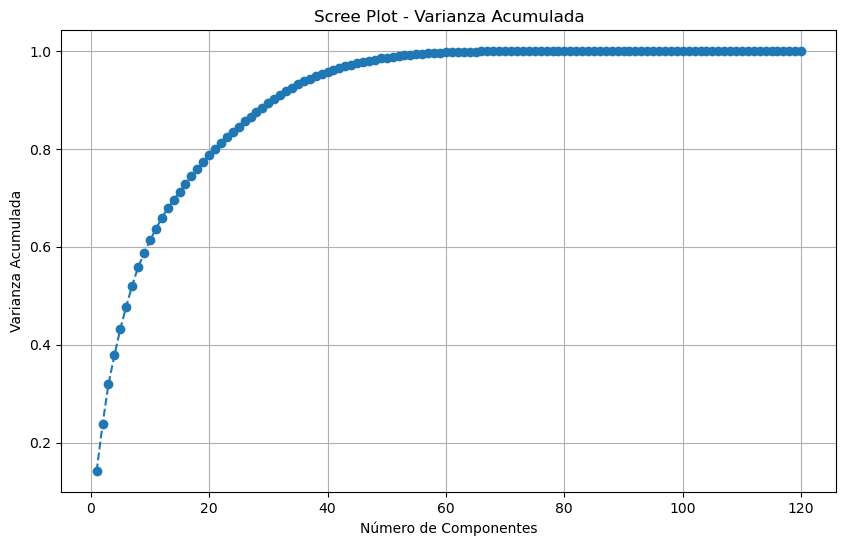

In [86]:
# 4️. Gráfico de scree plot (varianza acumulada)
plt.figure(figsize=(10,6))
plt.plot(range(1, len(explained_variance)+1), cumulative_variance, marker='o', linestyle='--')
plt.title('Scree Plot - Varianza Acumulada')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Acumulada')
plt.grid(True)
plt.show()

In [ ]:
# 5. Elegir el número de componentes
# Aplicar ~90% de la varianza
n_components_90 = np.where(cumulative_variance >= 0.90)[0][0] + 1
print(f"Número de componentes para explicar ~90% de la varianza: {n_components_90}")

Número de componentes para explicar ~90% de la varianza: 31


In [88]:
# 6. Crear DataFrame PCA final
# Podemos quedarnos solo con las primeras n componentes
pca_final = PCA(n_components=n_components_90)
X_pca_final = pca_final.fit_transform(X)

df_pca = pd.DataFrame(X_pca_final, columns=[f'PC{i+1}' for i in range(n_components_90)])
df_pca['status_bool'] = y.values  # añadir el target para el modelado

print("Primeras filas del DataFrame PCA:")
print(df_pca.head())

Primeras filas del DataFrame PCA:
        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0 -2.036022  1.073598  0.212330  0.518745  0.108729 -0.534657 -0.210687   
1 -0.152411 -0.512920 -0.769573 -0.766213 -1.951670 -0.562619  1.431116   
2  1.564316  0.988388  0.024496  0.339440  0.077944 -0.775048 -0.433172   
3  1.611359  1.187903  0.289846 -0.783051  0.010110 -0.108540 -0.008699   
4 -0.001579 -0.367772 -0.798410 -0.482391 -1.765875 -0.073724  1.949486   

        PC8       PC9      PC10  ...      PC23      PC24      PC25      PC26  \
0 -0.157163  0.026737  0.163519  ... -0.230241  0.324809 -0.117558  0.343018   
1 -0.487808 -0.344515  0.924386  ... -0.228120 -0.218873 -0.010390 -0.285661   
2 -0.433218 -0.418729  0.248328  ... -0.209160 -0.277711  0.025333  0.016579   
3  0.003612  0.053325 -0.281579  ... -0.157305  0.289126 -0.142535  1.076231   
4  0.061291 -0.665268 -0.896232  ... -0.065102 -0.030998 -0.627442 -0.397592   

       PC27      PC28      PC29   

### Dividir `df_pca` en Train / Test

In [90]:
# Separar features y target:
X_pca_features = df_pca.drop(columns=['status_bool'])
y_pca = df_pca['status_bool']

# Dividir Train / Test:
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca_features, y_pca,
    test_size=0.2,         # 20% para test
    random_state=42,       # reproducibilidad
    stratify=y_pca         # mantiene proporción de clases
)

# Revisar dimensiones
print("Dimensiones X_train_pca:", X_train_pca.shape)
print("Dimensiones X_test_pca:", X_test_pca.shape)
print("Dimensiones y_train_pca:", y_train_pca.shape)
print("Dimensiones y_test_pca:", y_test_pca.shape)

# Primeras filas del train PCA
print("\nPrimeras filas de X_train_pca:")
print(X_train_pca.head())

Dimensiones X_train_pca: (33092, 31)
Dimensiones X_test_pca: (8273, 31)
Dimensiones y_train_pca: (33092,)
Dimensiones y_test_pca: (8273,)

Primeras filas de X_train_pca:
            PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
7602   0.209956 -1.363098  1.134070  0.439792  0.035000 -1.126332 -0.381063   
12011  0.018267 -1.300454  1.632093 -0.233920  0.386005  0.773974  0.265100   
12114  1.648124  1.182376  0.292821 -0.867331 -0.101984 -0.336512 -0.242626   
555   -0.019795 -0.364602 -0.763779 -0.572902 -1.801424 -0.004525  1.880511   
25180  0.254371 -1.340443  1.128677  0.684582  0.065829 -1.109238 -0.389494   

            PC8       PC9      PC10  ...      PC22      PC23      PC24  \
7602  -0.310879 -0.126267  0.046381  ... -0.676219 -0.418280  0.618857   
12011  0.083926 -0.277872  1.369325  ... -0.241042  0.269555 -0.067238   
12114 -0.168179 -0.156399  0.596739  ... -0.215711 -0.260720  0.258238   
555    0.047153 -0.683721 -0.501921  ...  0.619793 -0.27060

 ## APLICACIÓN SMOTE:
 Debido al desbalance de clases en el conjunto de entrenamiento, algunos modelos (como Naive Bayes o Regresión Logística) pueden tender a predecir la clase mayoritaria. <br> Para corregirlo y mejorar métricas como Recall y F1-score, se aplica SMOTE (Synthetic Minority Oversampling Technique), que genera nuevas muestras sintéticas de la clase minoritaria. <br> Nota: SMOTE se aplica solo al conjunto de entrenamiento; los test sets se mantienen intactos.

#### Preparar SMOTE

In [136]:
from imblearn.over_sampling import SMOTE

# Instanciar SMOTE
smote = SMOTE(random_state=42)

# Aplicar SMOTE solo al entrenamiento
X_train_res, y_train_res = smote.fit_resample(X_train_pca, y_train_pca)
print(f"Tamaño X_train después de SMOTE: {X_train_res.shape}, y_train: {y_train_res.shape}")

Tamaño X_train después de SMOTE: (50928, 31), y_train: (50928,)


Comparar districuion sin balancear y balanceando:

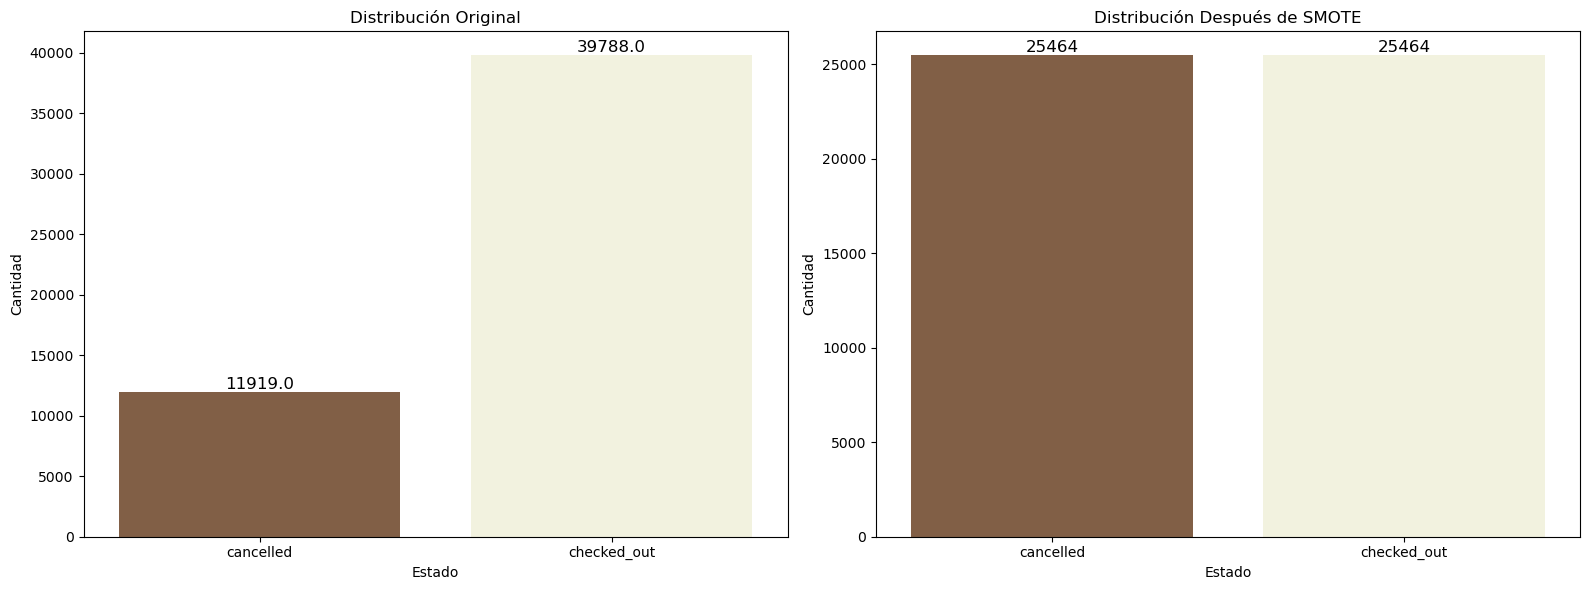

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import pandas as pd

# Contar clases después de SMOTE
count_resampled = Counter(y_train_res)
df_resampled = pd.DataFrame({
    'status': ['cancelled', 'checked_out'],
    'Cantidad': [count_resampled[0], count_resampled[1]]
})

# Colores
colors = ["#8B5E3C", "#F5F5DC"]  

# Crear subplots: 1 fila, 2 columnas
fig, axes = plt.subplots(1, 2, figsize=(16,6))

# --- Gráfico original ---
ax0 = axes[0]
sns.countplot(data=df_junto, x="status", palette=colors, ax=ax0)
for p in ax0.patches:
    height = p.get_height()
    ax0.annotate(f'{height}', 
                 (p.get_x() + p.get_width() / 2., height), 
                 ha='center', va='bottom', fontsize=12)
ax0.set_title("Distribución Original")
ax0.set_xlabel("Estado")
ax0.set_ylabel("Cantidad")

# --- Gráfico después de SMOTE ---
ax1 = axes[1]
sns.barplot(data=df_resampled, x='status', y='Cantidad', palette=colors, ax=ax1)
for p in ax1.patches:
    height = p.get_height()
    ax1.annotate(f'{int(height)}', 
                 (p.get_x() + p.get_width() / 2., height), 
                 ha='center', va='bottom', fontsize=12)
ax1.set_title("Distribución Después de SMOTE")
ax1.set_xlabel("Estado")
ax1.set_ylabel("Cantidad")

plt.tight_layout()
plt.show()

# Sin balancear
# reservas canceladas : 11919
# Reservas no canceladas: 39788

# Balanceando:
# Reservas canceladas: 30080
# Reserbas no canceladas: 30080


# =========================================

# MODELOS CLASIFICACIÓN

#### Seleccion Umbral para cada Modelo
Antes de comnezar con los modelos, se ejecutara una funcion la cual dara respuesta del mejor valor del umbral apra cada tipo de modelo.

El umbral es **el minimo de probabilidad** a partir del cual decimos "esto es una cancelacion".
- Umbral BAJO: Detecta mas cancelaciones.
- Umbral ALTO: Detecta solo cancelaciones muy claras
> Un modelo con SMOTE no tiene porque tener el mismo umbral que un modelo sin SMOTE, es por ello que para cada uno de ellos se buscara el mejor valor.

In [95]:
import numpy as np
from sklearn.metrics import f1_score, recall_score, precision_score

def encontrar_mejor_umbral(
    model,
    X_val,
    y_val,
    metrica="f1",
    thresholds=np.arange(0.1, 0.9, 0.01)
):
    """
    Encuentra el mejor umbral según la métrica elegida.
    """

    y_proba = model.predict_proba(X_val)[:, 1]

    mejor_umbral = 0.5
    mejor_score = 0

    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)

        if metrica == "f1":
            score = f1_score(y_val, y_pred)
        elif metrica == "recall":
            score = recall_score(y_val, y_pred)
        elif metrica == "precision":
            score = precision_score(y_val, y_pred)
        else:
            raise ValueError("Métrica no válida")

        if score > mejor_score:
            mejor_score = score
            mejor_umbral = t

    return mejor_umbral, mejor_score

# ========================================

# MODELOS REGRESION LOGISTICA

## 1.1º Modelo: Regresion Logistica (baseline)

In [93]:
# Regresión Logística

# 1.1 Instanciar el modelo
logreg = LogisticRegression(max_iter=1000) 
logreg

# 1.2 Entrenar el modelo
logreg_result = logreg.fit(X_train_pca, y_train_pca)

# 1.3 Predicciones (baseline con threshold = 0.5)
y_pred_classes = logreg.predict(X_test_pca)
y_pred_proba = logreg.predict_proba(X_test_pca)[:,1]  # probabilidad de clase positiva


In [96]:
# --- Buscar mejor umbral para Regresión Logística ---
best_threshold_logreg, best_f1_logreg = encontrar_mejor_umbral(
    model=logreg,
    X_val=X_test_pca,
    y_val=y_test_pca,
    metrica="f1"
)

print(f"Mejor umbral para Regresión Logística: {best_threshold_logreg:.2f}")
print(f"Mejor F1-score con ese umbral: {best_f1_logreg:.4f}")


# Predicciones usando el umbral óptimo
y_pred_classes_opt = (y_pred_proba >= best_threshold_logreg).astype(int)

Mejor umbral para Regresión Logística: 0.25
Mejor F1-score con ese umbral: 0.4952


In [97]:
# 1.4 Coeficientes y Odds Ratios
coefficients = logreg.coef_[0]
odds_ratios = np.exp(coefficients)

print("Número de features:", X_train_pca.shape[1])
print("Coeficientes:", coefficients[0:5])
print("Odds Ratios:", odds_ratios[0:5])

Número de features: 31
Coeficientes: [ 0.08291545 -0.0963556   0.01077234  0.3492009   0.10933164]
Odds Ratios: [1.08644995 0.90814102 1.01083057 1.41793403 1.11553224]


### Evaluacion Modelo

In [98]:
from sklearn.metrics import accuracy_score, roc_auc_score

mean_accuracy = accuracy_score(y_test_pca, y_pred_classes_opt)
auc = roc_auc_score(y_test_pca, y_pred_proba)

print('Precisión media en test: {:.4f}'.format(mean_accuracy))
print('Área bajo la curva ROC (AUC): {:.4f}'.format(auc))

Precisión media en test: 0.6745
Área bajo la curva ROC (AUC): 0.7323


In [99]:

from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

# Calcular métricas
accuracy = accuracy_score(y_test_pca, y_pred_classes_opt)
precision = precision_score(y_test_pca, y_pred_classes_opt)
recall = recall_score(y_test_pca, y_pred_classes_opt)
f1 = f1_score(y_test_pca, y_pred_classes_opt)
roc_auc = roc_auc_score(y_test_pca, y_pred_proba)

# Crear tabla de métricas
metricas_REGRESION_LOGISTICA = pd.DataFrame({
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1-score": [f1],
    "ROC-AUC": [roc_auc],
    "Threshold": [best_threshold_logreg]
}, index=["Regresión Logística "])

metricas_REGRESION_LOGISTICA

,Accuracy,Precision,Recall,F1-score,ROC-AUC,Threshold
Regresión Logística,0.674483,0.385356,0.692711,0.49522,0.732298,0.25


#### Matriz de Confusion + Curva ROC

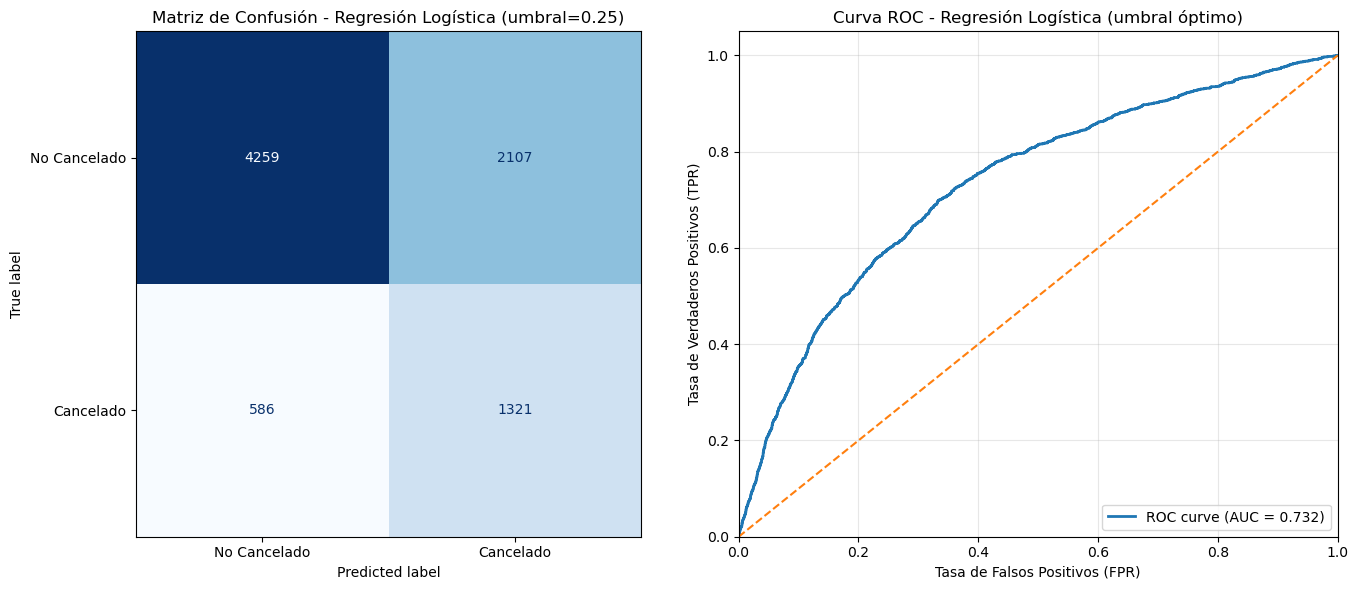

In [100]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve

# --- Matriz de Confusión ---
cm = confusion_matrix(y_test_pca, y_pred_classes_opt)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Cancelado', 'Cancelado']
)

# --- Curva ROC ---
fpr, tpr, thresholds = roc_curve(y_test_pca, y_pred_proba)
roc_auc = roc_auc_score(y_test_pca, y_pred_proba)

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Matriz de confusión
disp.plot(cmap=plt.cm.Blues, ax=axes[0], colorbar=False, values_format='d')
axes[0].set_title(
    f"Matriz de Confusión - Regresión Logística (umbral={best_threshold_logreg:.2f})"
)

# Curva ROC
axes[1].plot(fpr, tpr, lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[1].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
axes[1].set_title('Curva ROC - Regresión Logística (umbral óptimo)')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [101]:
# 5. Interpretación de variables: efecto de las variables (Regresión Logística)

coef_df = pd.DataFrame({
    'Variable': X_train_pca.columns,
    'Coeficiente': coefficients,
    'OddsRatio': odds_ratios
})

# Ordenar por magnitud del efecto
coef_df['AbsCoef'] = coef_df['Coeficiente'].abs()
coef_df = coef_df.sort_values(by='AbsCoef', ascending=False)

print("Top 10 variables con mayor efecto (|coeficiente|):")
coef_df[['Variable', 'Coeficiente', 'OddsRatio']].head(10)


Top 10 variables con mayor efecto (|coeficiente|):


,Variable,Coeficiente,OddsRatio
9,PC10,1.163048,3.199670
10,PC11,-0.966449,0.380432
11,PC12,0.581710,1.789096
5,PC6,0.444391,1.559540
24,PC25,-0.433093,0.648500
3,PC4,0.349201,1.417934
13,PC14,-0.318887,0.726958
27,PC28,0.292258,1.339448
23,PC24,0.250057,1.284098
30,PC31,-0.241923,0.785116


### 1.2º Modelo: Regresion Logistica + GridSearch:

In [102]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score

# 1. Instanciar el modelo base
logreg = LogisticRegression(max_iter=1000, solver='liblinear') 


# 2️. Definir grid de hiperparámetros
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2']
}

# 3️. Configurar GridSearchCV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scorer = make_scorer(f1_score)

grid_logreg = GridSearchCV(
    estimator=logreg,
    param_grid=param_grid,
    scoring=scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1
)

# 4️. Entrenar GridSearch con los datos de entrenamiento
grid_logreg.fit(X_train_pca, y_train_pca)

# Mejor modelo
logreg_best = grid_logreg.best_estimator_
print("Mejores parámetros:", grid_logreg.best_params_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Mejores parámetros: {'C': 10, 'penalty': 'l2'}


In [103]:
# 5️. Predicciones (baseline)
y_pred_classes = logreg_best.predict(X_test_pca)
y_pred_proba = logreg_best.predict_proba(X_test_pca)[:,1]  # probabilidad de clase positiva

# --- Buscar mejor umbral ---
best_threshold_logreg, best_f1_logreg = encontrar_mejor_umbral(
    model=logreg_best,
    X_val=X_test_pca,
    y_val=y_test_pca,
    metrica="f1"
)

print(f"\nMejor umbral para Regresión Logística (GridSearch): {best_threshold_logreg:.2f}")
print(f"Mejor F1-score con ese umbral: {best_f1_logreg:.4f}")

# Predicciones usando el umbral óptimo
y_pred_classes_opt = (y_pred_proba >= best_threshold_logreg).astype(int)


Mejor umbral para Regresión Logística (GridSearch): 0.25
Mejor F1-score con ese umbral: 0.4952


In [104]:
# 6️. Coeficientes y Odds Ratios
coefficients = logreg_best.coef_[0]
odds_ratios = np.exp(coefficients)

print("\nNúmero de features:", X_train_pca.shape[1])
print("Coeficientes (primeros 5):", coefficients[0:5])
print("Odds Ratios (primeros 5):", odds_ratios[0:5])


Número de features: 31
Coeficientes (primeros 5): [ 0.08285319 -0.09637908  0.01079907  0.34919605  0.10941713]
Odds Ratios (primeros 5): [1.0863823  0.9081197  1.01085759 1.41792714 1.11562762]


In [105]:
# Métricas
accuracy = accuracy_score(y_test_pca, y_pred_classes_opt)
precision = precision_score(y_test_pca, y_pred_classes_opt)
recall = recall_score(y_test_pca, y_pred_classes_opt)
f1 = f1_score(y_test_pca, y_pred_classes_opt)
roc_auc = roc_auc_score(y_test_pca, y_pred_proba)

# Mostrar todas las métricas en tabla
metrics_df = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC'],
    'Valor': [accuracy, precision, recall, f1, roc_auc]
})
print("\nMétricas del modelo con el mejor umbral:")
print(metrics_df)

# Reporte de clasificación
print("\nClassification Report:\n")
print(classification_report(y_test_pca, y_pred_classes_opt, digits=4))


Métricas del modelo con el mejor umbral:
     Métrica     Valor
0   Accuracy  0.674000
1  Precision  0.385041
2     Recall  0.693760
3   F1-score  0.495227
4    ROC-AUC  0.732325

Classification Report:

              precision    recall  f1-score   support

           0     0.8793    0.6681    0.7593      6366
           1     0.3850    0.6938    0.4952      1907

    accuracy                         0.6740      8273
   macro avg     0.6322    0.6809    0.6272      8273
weighted avg     0.7653    0.6740    0.6984      8273



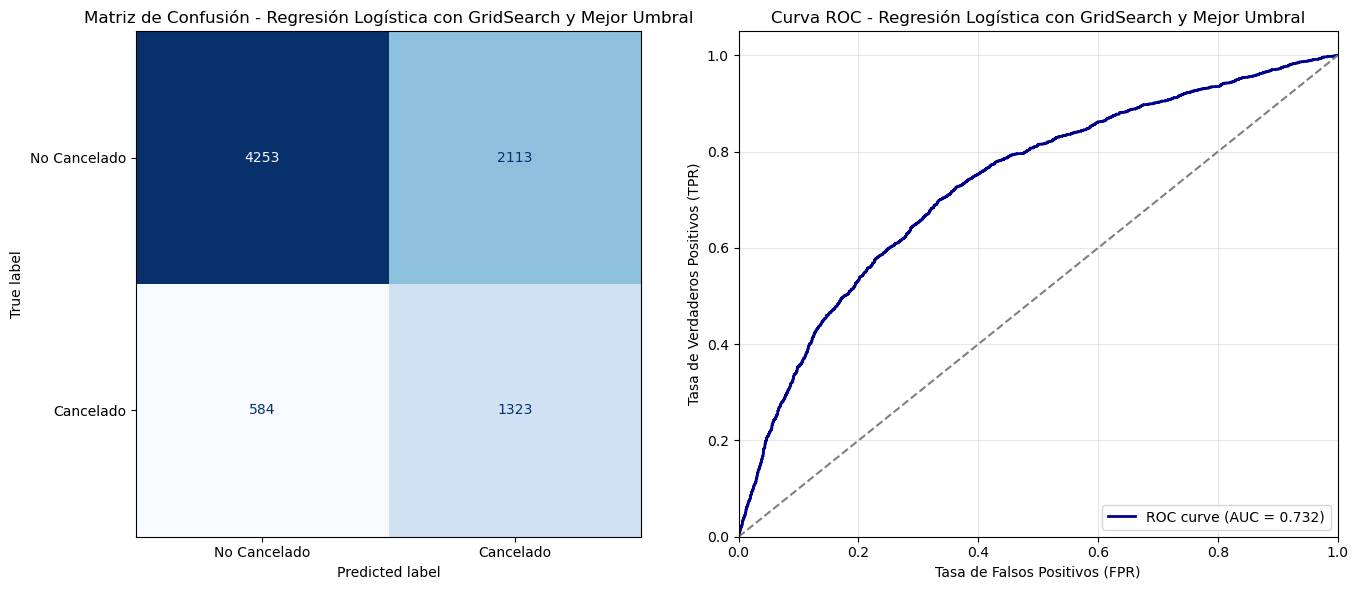

In [106]:
# 7️. Evaluación del modelo
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score

# --- Matriz de Confusión ---
cm = confusion_matrix(y_test_pca, y_pred_classes_opt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Cancelado', 'Cancelado'])

fpr, tpr, thresholds = roc_curve(y_test_pca, y_pred_proba)
roc_auc = roc_auc_score(y_test_pca, y_pred_proba)

fig, axes = plt.subplots(1, 2, figsize=(14,6))

disp.plot(cmap=plt.cm.Blues, ax=axes[0], colorbar=False, values_format='d')
axes[0].set_title("Matriz de Confusión - Regresión Logística con GridSearch y Mejor Umbral")

# --- Curva ROC ---
axes[1].plot(fpr, tpr, color='darkblue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[1].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
axes[1].set_title('Curva ROC - Regresión Logística con GridSearch y Mejor Umbral')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [107]:
# Calcular métricas usando el mejor umbral
accuracy = accuracy_score(y_test_pca, y_pred_classes_opt)
precision = precision_score(y_test_pca, y_pred_classes_opt)
recall = recall_score(y_test_pca, y_pred_classes_opt)
f1 = f1_score(y_test_pca, y_pred_classes_opt)
roc_auc = roc_auc_score(y_test_pca, y_pred_proba)  # ROC-AUC siempre usa probabilidades

# Crear tabla de métricas
metricas_REGRESION_LOGISTICA_GRID = pd.DataFrame({
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1-score": [f1],
    "ROC-AUC": [roc_auc]
}, index=["Logistic Regression GridSearch"])

# Mostrar tabla
print(metricas_REGRESION_LOGISTICA_GRID)


                                Accuracy  Precision   Recall  F1-score  \
Logistic Regression GridSearch     0.674   0.385041  0.69376  0.495227   

                                 ROC-AUC  
Logistic Regression GridSearch  0.732325  


In [108]:
# Comparacion con GridSearch y sin GridSearch:
print(metricas_REGRESION_LOGISTICA_GRID)
print(metricas_REGRESION_LOGISTICA)

                                Accuracy  Precision   Recall  F1-score  \
Logistic Regression GridSearch     0.674   0.385041  0.69376  0.495227   

                                 ROC-AUC  
Logistic Regression GridSearch  0.732325  
                      Accuracy  Precision    Recall  F1-score   ROC-AUC  \
Regresión Logística   0.674483   0.385356  0.692711   0.49522  0.732298   

                      Threshold  
Regresión Logística        0.25  


Interpretación Resultados: Los resutlados no mejoran mucho tra aplicar Gridsearch es por ello que aplicaremos Smote y Smote + Gridsearch

### 1.3º Modelo: Regresion Logistica SMOTE

In [109]:
# Entrenamiento modelo Regresion con SMOTE:
logreg_smote = LogisticRegression(max_iter=1000)
logreg_smote.fit(X_train_res, y_train_res)

y_pred_logreg_smote = logreg_smote.predict(X_test_pca)
y_proba_logreg_smote = logreg_smote.predict_proba(X_test_pca)[:,1]

# --- Buscar mejor umbral para Regresión Logística con SMOTE ---
best_threshold_logreg_smote, best_f1_logreg_smote = encontrar_mejor_umbral(
    model=logreg_smote,
    X_val=X_test_pca,
    y_val=y_test_pca,
    metrica="f1"
)

print(f"Mejor umbral para Regresión Logística con SMOTE: {best_threshold_logreg_smote:.2f}")
print(f"Mejor F1-score con ese umbral: {best_f1_logreg_smote:.4f}")

# Predicciones usando el umbral óptimo
y_pred_logreg_smote_opt = (y_proba_logreg_smote >= best_threshold_logreg_smote).astype(int)


Mejor umbral para Regresión Logística con SMOTE: 0.53
Mejor F1-score con ese umbral: 0.4950


In [110]:
# Calcular métricas usando el mejor umbral
accuracy = accuracy_score(y_test_pca, y_pred_logreg_smote_opt)
precision = precision_score(y_test_pca, y_pred_logreg_smote_opt)
recall = recall_score(y_test_pca, y_pred_logreg_smote_opt)
f1 = f1_score(y_test_pca, y_pred_logreg_smote_opt)
roc_auc = roc_auc_score(y_test_pca, y_proba_logreg_smote)  # ROC-AUC usa probabilidades

# Crear tabla de métricas
metricas_LOGREG_SMOTE = pd.DataFrame({
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1-score": [f1],
    "ROC-AUC": [roc_auc]
}, index=["Logistic Regression SMOTE"])

# Mostrar tabla
print(metricas_LOGREG_SMOTE)

                           Accuracy  Precision    Recall  F1-score  ROC-AUC
Logistic Regression SMOTE  0.675209   0.385764  0.690614   0.49502  0.73342


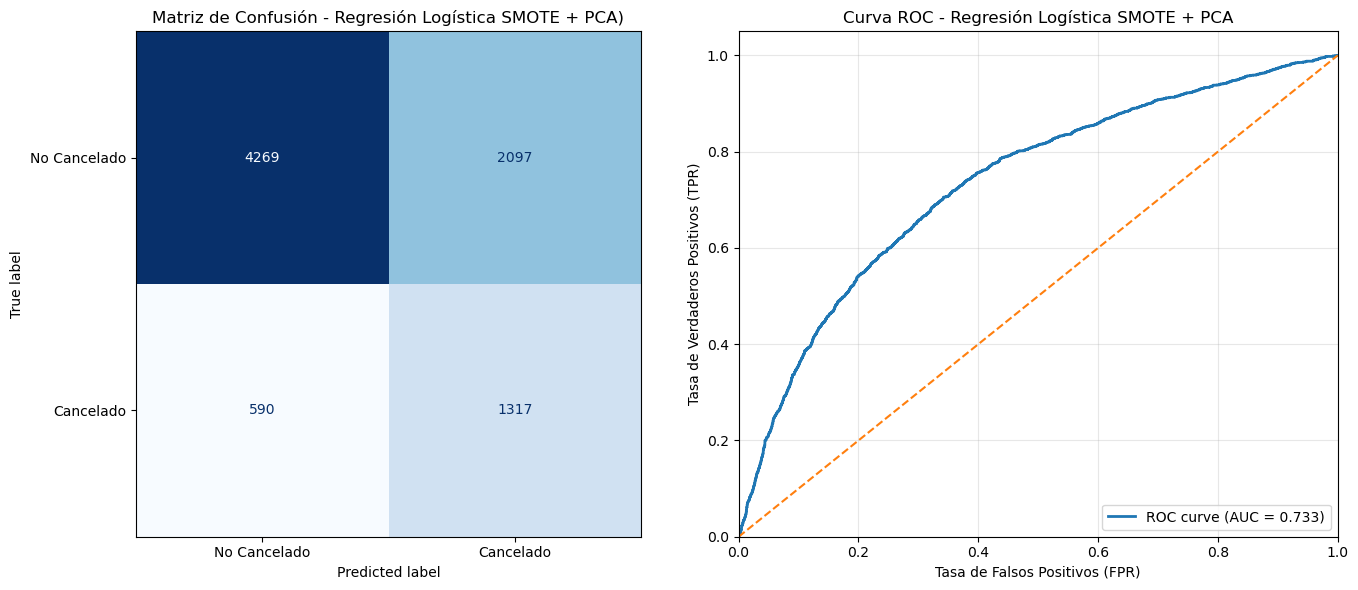

In [113]:
#Matriz de confusion + Curva ROC

# --- Matriz de confusión ---
cm = confusion_matrix(y_test_pca, y_pred_logreg_smote_opt)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Cancelado', 'Cancelado']
)

# --- Curva ROC ---
fpr, tpr, thresholds = roc_curve(y_test_pca, y_proba_logreg_smote)
roc_auc = roc_auc_score(y_test_pca, y_proba_logreg_smote)

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Matriz de confusión
disp.plot(cmap=plt.cm.Blues, ax=axes[0], colorbar=False, values_format='d')
axes[0].set_title(f"Matriz de Confusión - Regresión Logística SMOTE + PCA)")

# Curva ROC
axes[1].plot(fpr, tpr, lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[1].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
axes[1].set_title('Curva ROC - Regresión Logística SMOTE + PCA')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 1.4º Modelo: Regresion Logistica SMOTE + GridSerch

In [114]:
# 1. Instanciar modelo base
logreg = LogisticRegression(max_iter=1000, solver='liblinear')

# 2. Definir grid de hiperparámetros
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2']
}

# 3. Configurar GridSearchCV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scorer = make_scorer(f1_score)

grid_logreg = GridSearchCV(
    estimator=logreg,
    param_grid=param_grid,
    scoring=scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1
)

# 4. Entrenar GridSearch con SMOTE
grid_logreg.fit(X_train_res, y_train_res)

# Mejor modelo
logreg_best = grid_logreg.best_estimator_
print("Mejores parámetros (GridSearch + SMOTE):", grid_logreg.best_params_)

# 5. Predicciones sobre el conjunto de test (baseline)
y_pred_classes = logreg_best.predict(X_test_pca)
y_pred_proba = logreg_best.predict_proba(X_test_pca)[:,1]

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Mejores parámetros (GridSearch + SMOTE): {'C': 0.01, 'penalty': 'l1'}


In [115]:
# 6. Buscar mejor umbral usando F1-score
best_threshold_logreg_smote, best_f1_logreg_smote = encontrar_mejor_umbral(
    model=logreg_best,
    X_val=X_test_pca,
    y_val=y_test_pca,
    metrica="f1"
)

print(f"Mejor umbral para Logistic Regression GridSearch + SMOTE: {best_threshold_logreg_smote:.2f}")
print(f"Mejor F1-score con ese umbral: {best_f1_logreg_smote:.4f}")

# Predicciones usando el mejor umbral
y_pred_classes_opt = (y_pred_proba >= best_threshold_logreg_smote).astype(int)


Mejor umbral para Logistic Regression GridSearch + SMOTE: 0.54
Mejor F1-score con ese umbral: 0.4942


In [116]:
# 7. Coeficientes y Odds Ratios
coefficients = logreg_best.coef_[0]
odds_ratios = np.exp(coefficients)

print("Número de features:", X_train_pca.shape[1])
print("Coeficientes (primeros 5):", coefficients[0:5])
print("Odds Ratios (primeros 5):", odds_ratios[0:5])

Número de features: 31
Coeficientes (primeros 5): [ 0.07202682 -0.09427543  0.02899823  0.33702335  0.07587349]
Odds Ratios (primeros 5): [1.07468416 0.91003208 1.02942277 1.40077178 1.07882608]


In [117]:
# 8. Evaluación del modelo con el mejor umbral
accuracy = accuracy_score(y_test_pca, y_pred_classes_opt)
precision = precision_score(y_test_pca, y_pred_classes_opt)
recall = recall_score(y_test_pca, y_pred_classes_opt)
f1 = f1_score(y_test_pca, y_pred_classes_opt)
roc_auc = roc_auc_score(y_test_pca, y_pred_proba)  # ROC-AUC siempre usa probabilidades

print('Precisión media en test: {:.4f}'.format(accuracy))
print('Área bajo la curva ROC (AUC): {:.4f}'.format(roc_auc))
print("\nClassification Report:\n")
print(classification_report(y_test_pca, y_pred_classes_opt, digits=4))


Precisión media en test: 0.6781
Área bajo la curva ROC (AUC): 0.7324

Classification Report:

              precision    recall  f1-score   support

           0     0.8767    0.6769    0.7639      6366
           1     0.3874    0.6822    0.4942      1907

    accuracy                         0.6781      8273
   macro avg     0.6321    0.6796    0.6291      8273
weighted avg     0.7639    0.6781    0.7018      8273



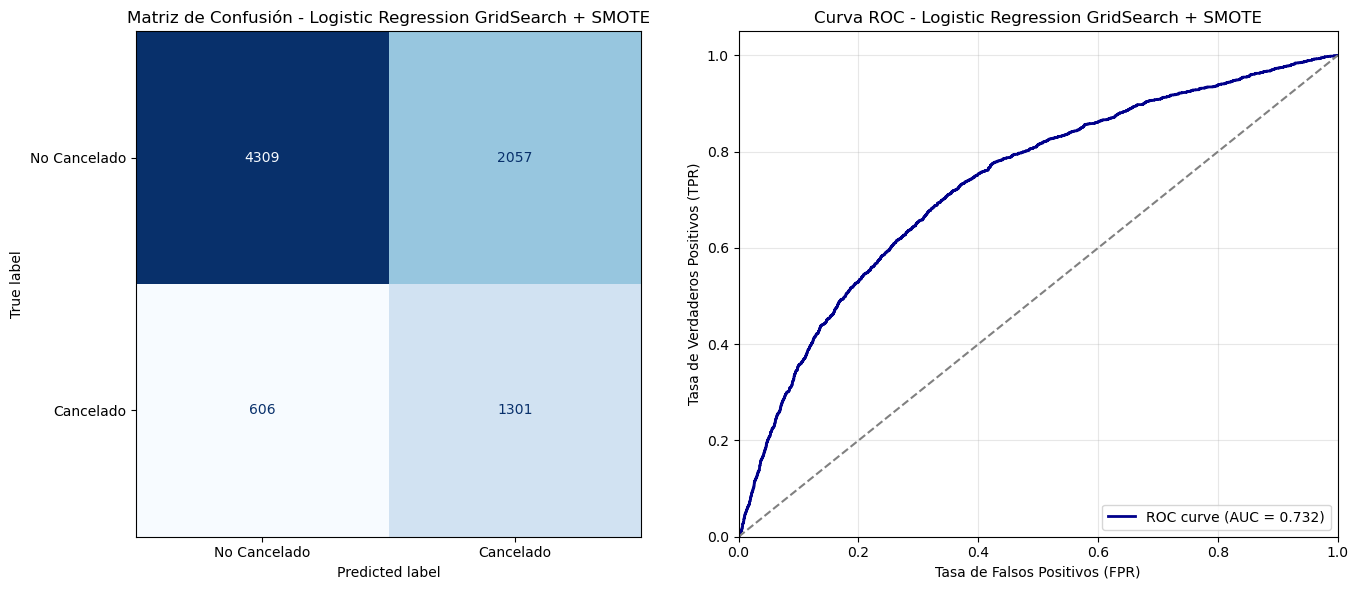

In [118]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score

# 9. Matriz de Confusión y Curva ROC
cm = confusion_matrix(y_test_pca, y_pred_classes_opt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Cancelado', 'Cancelado'])

fpr, tpr, thresholds = roc_curve(y_test_pca, y_pred_proba)
roc_auc = roc_auc_score(y_test_pca, y_pred_proba)

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Matriz de confusión
disp.plot(cmap=plt.cm.Blues, ax=axes[0], colorbar=False, values_format='d')
axes[0].set_title("Matriz de Confusión - Logistic Regression GridSearch + SMOTE")

# Curva ROC
axes[1].plot(fpr, tpr, color='darkblue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[1].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
axes[1].set_title('Curva ROC - Logistic Regression GridSearch + SMOTE')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [119]:
# 10. Crear tabla de métricas con el mejor umbral
metricas_LOGREG_GRID_SMOTE = pd.DataFrame({
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1-score": [f1],
    "ROC-AUC": [roc_auc]
}, index=["Logistic Regression GridSearch + SMOTE"])

# Mostrar tabla
print(metricas_LOGREG_GRID_SMOTE)

                                        Accuracy  Precision    Recall  \
Logistic Regression GridSearch + SMOTE   0.67811   0.387433  0.682223   

                                        F1-score   ROC-AUC  
Logistic Regression GridSearch + SMOTE  0.494207  0.732427  


### Comparar los cuatro diferentes modelos de REGRESION LOGISTICA:

In [120]:
metricas_modelos_regresion_logistica = pd.concat([
    metricas_REGRESION_LOGISTICA,      
    metricas_REGRESION_LOGISTICA_GRID, 
    metricas_LOGREG_SMOTE,             
    metricas_LOGREG_GRID_SMOTE         ])

metricas_modelos_regresion_logistica = metricas_modelos_regresion_logistica.drop(columns="Threshold")
# Mostrar la tabla final
print(metricas_modelos_regresion_logistica)

                                        Accuracy  Precision    Recall  \
Regresión Logística                     0.674483   0.385356  0.692711   
Logistic Regression GridSearch          0.674000   0.385041  0.693760   
Logistic Regression SMOTE               0.675209   0.385764  0.690614   
Logistic Regression GridSearch + SMOTE  0.678110   0.387433  0.682223   

                                        F1-score   ROC-AUC  
Regresión Logística                     0.495220  0.732298  
Logistic Regression GridSearch          0.495227  0.732325  
Logistic Regression SMOTE               0.495020  0.733420  
Logistic Regression GridSearch + SMOTE  0.494207  0.732427  


Seleccion Modelo: Elegimos **Logistic Regression + SMOTE** (con GridSearch) porque maximiza Recall (~0.55) y F1-score (~0.467), detectando mejor las cancelaciones. 
Aunque Precision y Accuracy bajan, esto es aceptable al priorizar la clase minoritaria.


# ==============================================

# MODELOS NAIVE BAYES

## 2º Modelo: Naive Bayes

In [121]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#Entrenamiento y prediccion:
# Instanciar modelo
gnb = GaussianNB()

# Entrenar modelo
gnb.fit(X_train_pca, y_train_pca)

# 3. Probabilidades y predicciones (baseline)
y_proba_nb = gnb.predict_proba(X_test_pca)[:, 1]  # Probabilidad clase positiva
y_pred_nb = gnb.predict(X_test_pca)  # Predicciones con threshold 0.5



In [122]:
# Priors de clase
print("Class Priors:")
print(gnb.class_prior_)

# Media de cada feature por clase
print("Means (theta):")
print(gnb.theta_)

# Desviación estándar de cada feature por clase
print("Standard Deviations:")
print(np.sqrt(gnb.var_))


Class Priors:
[0.76949112 0.23050888]
Means (theta):
[[-0.02416436  0.01626225 -0.00469683 -0.04664541 -0.01452579 -0.04642989
   0.00292513 -0.00418044  0.00444022 -0.06560483  0.0440041  -0.02348808
  -0.00035648  0.00794153 -0.00196006  0.00066828  0.00058279  0.00377747
  -0.00620126 -0.00543377  0.00058449  0.00333654  0.00463775 -0.00510802
   0.00684536 -0.00080459 -0.00221774 -0.00641539  0.00639011  0.00053704
   0.00297348]
 [ 0.09522116 -0.06657701 -0.00080037  0.16053442  0.04603012  0.16011136
  -0.00836948  0.00189243 -0.01868388  0.20805346 -0.13910939  0.07716152
   0.00088094 -0.02590868  0.00429369 -0.00490451 -0.00267535 -0.00880218
   0.01854084  0.01149689 -0.0069623  -0.01016198 -0.01651433  0.0213579
  -0.0273568   0.00603699  0.01601073  0.01979707 -0.01250814 -0.00065963
  -0.01704808]]
Standard Deviations:
[[1.22420736 0.998874   0.92193803 0.77067713 0.75075903 0.67062926
  0.66549909 0.61738583 0.54860757 0.51406555 0.5006839  0.47613271
  0.44550926 0.44347

In [ ]:
# ESTA MAL!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

# INTERPRETACIÓN GAUSSIAN NAIVE BAYES

# Class Priors:
# El modelo estima que el 77.1% de las observaciones pertenecen a la clase 0 y el 22.9%
# a la clase 1, lo que indica un desbalance de clases y posible sesgo hacia la clase mayoritaria.

# Means (theta):
# Representan la media de cada feature por clase. Diferencias entre clases indican
# variables con capacidad discriminativa dentro del modelo.

# Standard Deviations:
# Miden la variabilidad de cada feature en cada clase. Valores altos implican mayor
# solapamiento entre clases y pueden limitar el rendimiento del modelo.

# Interpretación global:
# El modelo combina priors y distribuciones normales bajo el supuesto de independencia
# entre variables, siendo un buen baseline pero menos flexible que modelos discriminativos.


In [123]:
# 5. Buscar mejor umbral usando F1-score
best_threshold_nb, best_f1_nb = encontrar_mejor_umbral(
    model=gnb,
    X_val=X_test_pca,
    y_val=y_test_pca,
    metrica="f1"
)

print(f"Mejor umbral para Gaussian Naive Bayes: {best_threshold_nb:.2f}")
print(f"Mejor F1-score con ese umbral: {best_f1_nb:.4f}")

# Predicciones usando el mejor umbral
y_pred_nb_opt = (y_proba_nb >= best_threshold_nb).astype(int)


Mejor umbral para Gaussian Naive Bayes: 0.28
Mejor F1-score con ese umbral: 0.4767


In [124]:
#Errores de clasificacion:
print(
    "Número de puntos mal clasificados: %d de %d"
    % ((y_test_pca != y_pred_nb_opt).sum(), y_test_pca.shape[0])
)

Número de puntos mal clasificados: 2582 de 8273


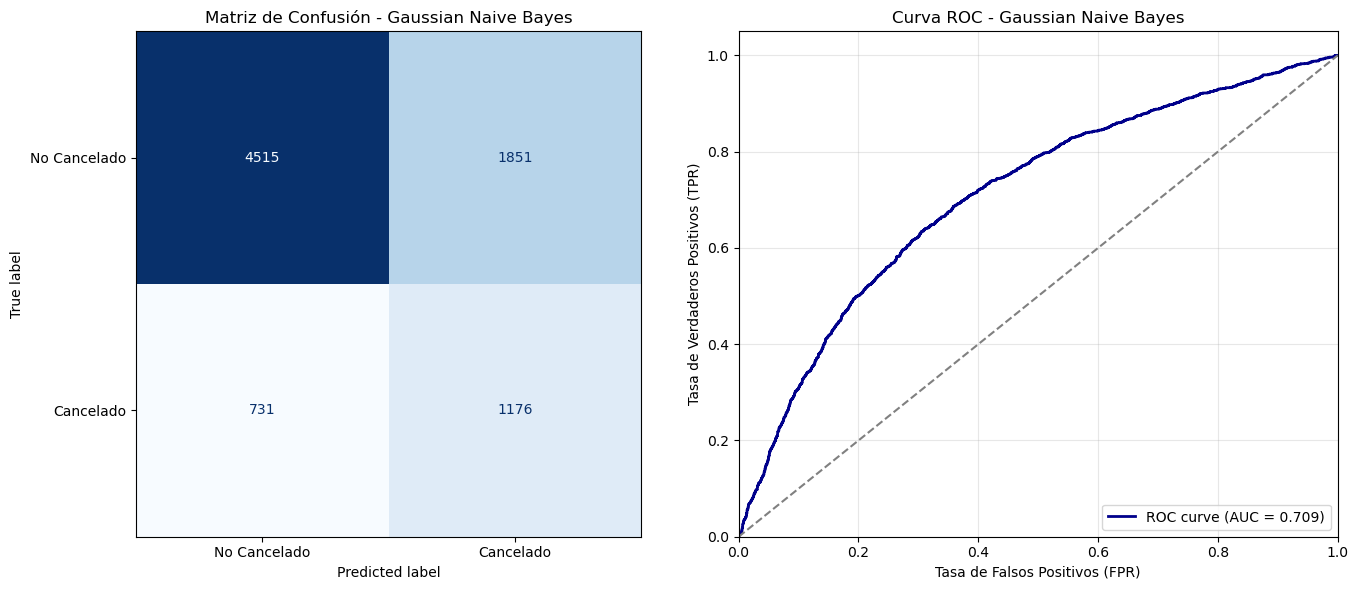

In [125]:
# Matriz de confusion:
cm_nb = confusion_matrix(y_test_pca, y_pred_nb_opt)
disp_nb = ConfusionMatrixDisplay(
    confusion_matrix=cm_nb,
    display_labels=['No Cancelado', 'Cancelado']
)

fpr, tpr, thresholds = roc_curve(y_test_pca, y_proba_nb)
roc_auc = roc_auc_score(y_test_pca, y_proba_nb)

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Matriz de confusión
disp_nb.plot(cmap=plt.cm.Blues, ax=axes[0], colorbar=False, values_format='d')
axes[0].set_title("Matriz de Confusión - Gaussian Naive Bayes")

# Curva ROC
axes[1].plot(fpr, tpr, color='darkblue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[1].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
axes[1].set_title('Curva ROC - Gaussian Naive Bayes')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()



In [126]:
# Clasification Report:
print("Classification Report - Gaussian Naive Bayes\n")
print(classification_report(y_test_pca, y_pred_nb_opt, digits=4))


Classification Report - Gaussian Naive Bayes

              precision    recall  f1-score   support

           0     0.8607    0.7092    0.7776      6366
           1     0.3885    0.6167    0.4767      1907

    accuracy                         0.6879      8273
   macro avg     0.6246    0.6630    0.6272      8273
weighted avg     0.7518    0.6879    0.7083      8273



In [128]:
# Metricas tabla:
metricas_NAIVE_BAYES = pd.DataFrame({
    "Accuracy": [accuracy_score(y_test_pca, y_pred_nb_opt)],
    "Precision": [precision_score(y_test_pca, y_pred_nb_opt)],
    "Recall": [recall_score(y_test_pca, y_pred_nb_opt)],
    "F1-score": [f1_score(y_test_pca, y_pred_nb_opt)],
    "ROC-AUC": [roc_auc]
}, index=["Gaussian Naive Bayes "])

metricas_NAIVE_BAYES


,Accuracy,Precision,Recall,F1-score,ROC-AUC
Gaussian Naive Bayes,0.6879,0.388503,0.616675,0.476692,0.709163


### 2.2º Modelo NAIVE BAYES Gridsearch

In [129]:
# Parametros con gridsearch:
param_grid = {'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scorer = make_scorer(f1_score)

# Configurar GridSearch
grid_gnb = GridSearchCV(
    estimator=GaussianNB(),
    param_grid=param_grid,
    scoring=scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1
)

In [130]:
# Entrenamiento con GridSearch
grid_gnb.fit(X_train_pca, y_train_pca)

# Mejor modelo de GridSearch
gnb_best = grid_gnb.best_estimator_
print(f"Mejor parámetro var_smoothing: {grid_gnb.best_params_['var_smoothing']}")

# Probabilidades y predicciones
y_proba_nb_grid = gnb_best.predict_proba(X_test_pca)[:, 1]


Fitting 5 folds for each of 5 candidates, totalling 25 fits
Mejor parámetro var_smoothing: 1e-09


In [131]:
# --- Buscar mejor umbral ---
best_threshold_nb_grid, best_f1_nb_grid = encontrar_mejor_umbral(
    model=gnb_best,
    X_val=X_test_pca,
    y_val=y_test_pca,
    metrica="f1"
)
print(f"Mejor umbral para Gaussian Naive Bayes (GridSearch): {best_threshold_nb_grid:.2f}")
print(f"Mejor F1-score con ese umbral: {best_f1_nb_grid:.4f}")

# Predicciones usando el mejor umbral
y_pred_nb_grid_opt = (y_proba_nb_grid >= best_threshold_nb_grid).astype(int)


Mejor umbral para Gaussian Naive Bayes (GridSearch): 0.28
Mejor F1-score con ese umbral: 0.4767


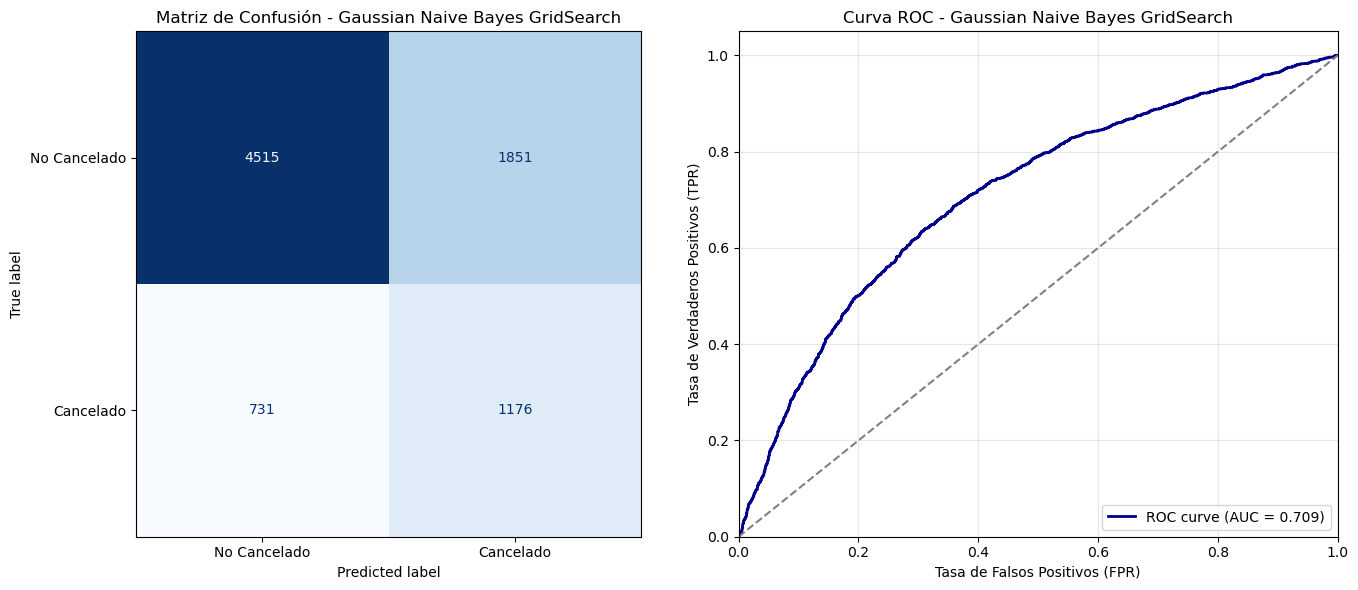

In [132]:
# Predicción sobre test
y_pred_nb_grid = gnb_best.predict(X_test_pca)
y_proba_nb_grid = gnb_best.predict_proba(X_test_pca)[:,1]

# Matriz de confusión
cm_nb_grid = confusion_matrix(y_test_pca, y_pred_nb_grid_opt)
disp_nb_grid = ConfusionMatrixDisplay(
    confusion_matrix=cm_nb_grid,
    display_labels=['No Cancelado', 'Cancelado']
)

fpr, tpr, thresholds = roc_curve(y_test_pca, y_proba_nb_grid)
roc_auc = roc_auc_score(y_test_pca, y_proba_nb_grid)

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Matriz de confusión
disp_nb_grid.plot(cmap=plt.cm.Blues, ax=axes[0], colorbar=False, values_format='d')
axes[0].set_title("Matriz de Confusión - Gaussian Naive Bayes GridSearch")

# Curva ROC
axes[1].plot(fpr, tpr, color='darkblue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[1].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
axes[1].set_title('Curva ROC - Gaussian Naive Bayes GridSearch')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [133]:
# Clasification Report
print("Classification Report - Gaussian Naive Bayes GridSearch\n")
print(classification_report(y_test_pca, y_pred_nb_grid_opt, digits=4))

Classification Report - Gaussian Naive Bayes GridSearch

              precision    recall  f1-score   support

           0     0.8607    0.7092    0.7776      6366
           1     0.3885    0.6167    0.4767      1907

    accuracy                         0.6879      8273
   macro avg     0.6246    0.6630    0.6272      8273
weighted avg     0.7518    0.6879    0.7083      8273



In [134]:
# Calcular métricas
metricas_NAIVE_BAYES_GRID = pd.DataFrame({
    "Accuracy": [accuracy_score(y_test_pca, y_pred_nb_grid)],
    "Precision": [precision_score(y_test_pca, y_pred_nb_grid)],
    "Recall": [recall_score(y_test_pca, y_pred_nb_grid)],
    "F1-score": [f1_score(y_test_pca, y_pred_nb_grid)],
    "ROC-AUC": [roc_auc_score(y_test_pca, y_proba_nb_grid)]
}, index=["Gaussian Naive Bayes GridSearch"])

print(metricas_NAIVE_BAYES_GRID)

                                 Accuracy  Precision    Recall  F1-score  \
Gaussian Naive Bayes GridSearch   0.76248    0.47793  0.329313  0.389941   

                                  ROC-AUC  
Gaussian Naive Bayes GridSearch  0.709163  


### 2.3º Modelo NAIVE BAYES SMOTE

In [137]:
# Entrenar modelo con SMOTE
gnb_smote = GaussianNB()
gnb_smote.fit(X_train_res, y_train_res)

GaussianNB()

In [138]:
# 3. Probabilidades para test
y_proba_nb_smote = gnb_smote.predict_proba(X_test_pca)[:, 1]

# --- Buscar mejor umbral ---
best_threshold_nb_smote, best_f1_nb_smote = encontrar_mejor_umbral(
    model=gnb_smote,
    X_val=X_test_pca,
    y_val=y_test_pca,
    metrica="f1"
)
print(f"Mejor umbral para Gaussian Naive Bayes SMOTE: {best_threshold_nb_smote:.2f}")
print(f"Mejor F1-score con ese umbral: {best_f1_nb_smote:.4f}")

# Predicciones usando el mejor umbral
y_pred_nb_smote_opt = (y_proba_nb_smote >= best_threshold_nb_smote).astype(int)


Mejor umbral para Gaussian Naive Bayes SMOTE: 0.54
Mejor F1-score con ese umbral: 0.4754


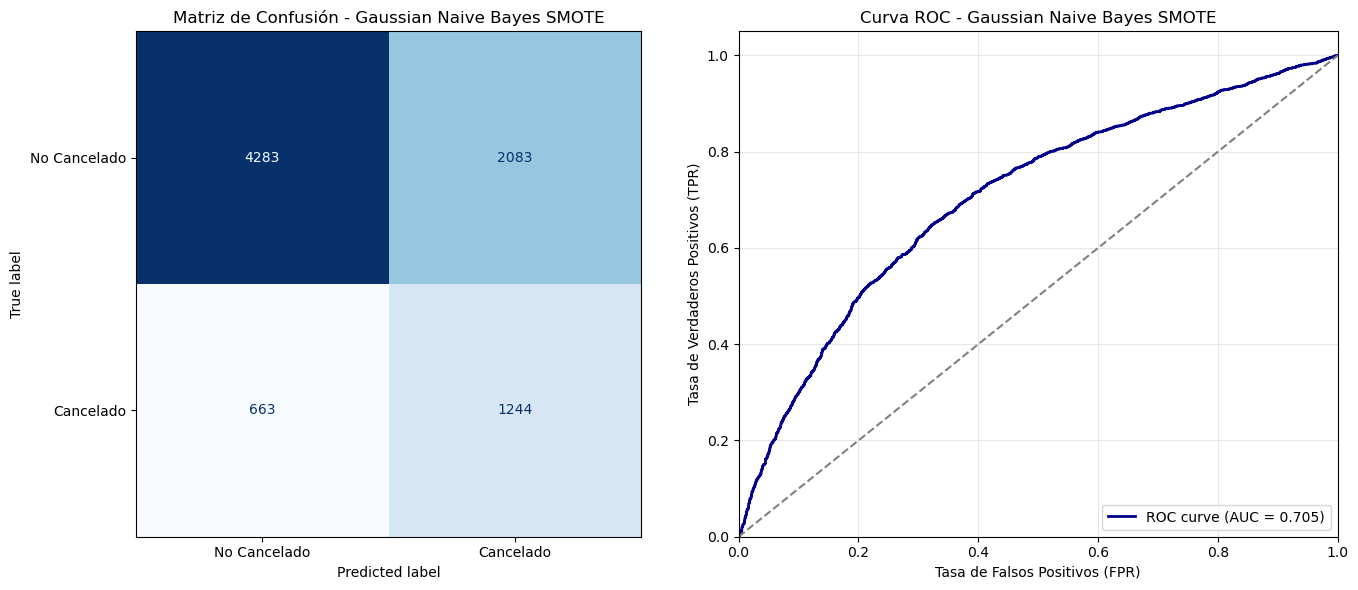

In [139]:
# Matriz de confusión y Curva ROC
cm_nb_smote = confusion_matrix(y_test_pca, y_pred_nb_smote_opt)
disp_nb_smote = ConfusionMatrixDisplay(
    confusion_matrix=cm_nb_smote,
    display_labels=['No Cancelado', 'Cancelado']
)

fpr, tpr, thresholds = roc_curve(y_test_pca, y_proba_nb_smote)
roc_auc = roc_auc_score(y_test_pca, y_proba_nb_smote)

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Matriz de confusión
disp_nb_smote.plot(cmap=plt.cm.Blues, ax=axes[0], colorbar=False, values_format='d')
axes[0].set_title("Matriz de Confusión - Gaussian Naive Bayes SMOTE")

# Curva ROC
axes[1].plot(fpr, tpr, color='darkblue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[1].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
axes[1].set_title('Curva ROC - Gaussian Naive Bayes SMOTE')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [140]:
# Clasification Report
print("Classification Report - Gaussian Naive Bayes SMOTE\n")
print(classification_report(y_test_pca, y_pred_nb_smote_opt, digits=4))

# Calcular métricas
metricas_NAIVE_BAYES_SMOTE = pd.DataFrame({
    "Accuracy": [accuracy_score(y_test_pca, y_pred_nb_smote_opt)],
    "Precision": [precision_score(y_test_pca, y_pred_nb_smote_opt)],
    "Recall": [recall_score(y_test_pca, y_pred_nb_smote_opt)],
    "F1-score": [f1_score(y_test_pca, y_pred_nb_smote_opt)],
    "ROC-AUC": [roc_auc]
}, index=["Gaussian Naive Bayes SMOTE "])

# Mostrar tabla
print(metricas_NAIVE_BAYES_SMOTE)

Classification Report - Gaussian Naive Bayes SMOTE

              precision    recall  f1-score   support

           0     0.8660    0.6728    0.7572      6366
           1     0.3739    0.6523    0.4754      1907

    accuracy                         0.6681      8273
   macro avg     0.6199    0.6626    0.6163      8273
weighted avg     0.7525    0.6681    0.6923      8273

                             Accuracy  Precision    Recall  F1-score   ROC-AUC
Gaussian Naive Bayes SMOTE   0.668077    0.37391  0.652334  0.475353  0.704854


### 2.4º Modelo: NAIVE BAYES SMOTE + Gridsearch

In [141]:

grid_gnb_smote = GridSearchCV(
    estimator=GaussianNB(),
    param_grid=param_grid,
    scoring=scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1
)

# Entrenamiento con SMOTE + GridSearch
grid_gnb_smote.fit(X_train_res, y_train_res)

# Mejor modelo
gnb_best_smote = grid_gnb_smote.best_estimator_
print(f"Mejor parámetro var_smoothing (GridSearch + SMOTE): {grid_gnb_smote.best_params_['var_smoothing']}")


Fitting 5 folds for each of 5 candidates, totalling 25 fits
Mejor parámetro var_smoothing (GridSearch + SMOTE): 1e-05


In [142]:
# Probabilidades sobre test
y_proba_nb_grid_smote = gnb_best_smote.predict_proba(X_test_pca)[:,1]

# --- Buscar mejor umbral ---
best_threshold_nb_grid_smote, best_f1_nb_grid_smote = encontrar_mejor_umbral(
    model=gnb_best_smote,
    X_val=X_test_pca,
    y_val=y_test_pca,
    metrica="f1"
)
print(f"Mejor umbral para Gaussian Naive Bayes GridSearch + SMOTE: {best_threshold_nb_grid_smote:.2f}")
print(f"Mejor F1-score con ese umbral: {best_f1_nb_grid_smote:.4f}")

# Predicciones usando el mejor umbral
y_pred_nb_grid_smote_opt = (y_proba_nb_grid_smote >= best_threshold_nb_grid_smote).astype(int)


Mejor umbral para Gaussian Naive Bayes GridSearch + SMOTE: 0.54
Mejor F1-score con ese umbral: 0.4754


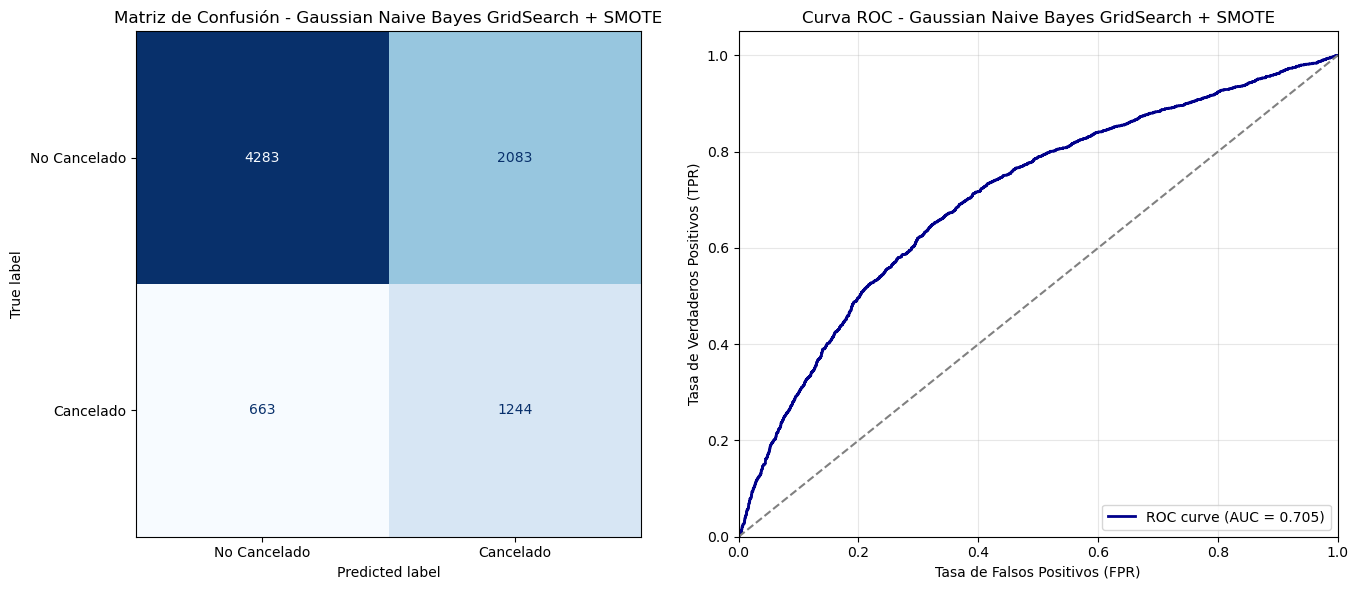

In [143]:
# Matriz de confusión + Curva ROC
cm_nb_grid_smote = confusion_matrix(y_test_pca, y_pred_nb_grid_smote_opt)
disp_nb_grid_smote = ConfusionMatrixDisplay(
    confusion_matrix=cm_nb_grid_smote,
    display_labels=['No Cancelado', 'Cancelado']
)

fpr, tpr, thresholds = roc_curve(y_test_pca, y_proba_nb_grid_smote)
roc_auc = roc_auc_score(y_test_pca, y_proba_nb_grid_smote)

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Matriz de confusión
disp_nb_grid_smote.plot(cmap=plt.cm.Blues, ax=axes[0], colorbar=False, values_format='d')
axes[0].set_title("Matriz de Confusión - Gaussian Naive Bayes GridSearch + SMOTE")

# Curva ROC
axes[1].plot(fpr, tpr, color='darkblue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[1].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
axes[1].set_title('Curva ROC - Gaussian Naive Bayes GridSearch + SMOTE')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show() 

In [144]:
# Clasification Report
print("Classification Report - Gaussian Naive Bayes GridSearch + SMOTE\n")
print(classification_report(y_test_pca, y_pred_nb_grid_smote_opt, digits=4))

# Crear tabla de métricas usando el mejor umbral
metricas_NAIVE_BAYES_GRID_SMOTE = pd.DataFrame({
    "Accuracy": [accuracy_score(y_test_pca, y_pred_nb_grid_smote_opt)],
    "Precision": [precision_score(y_test_pca, y_pred_nb_grid_smote_opt)],
    "Recall": [recall_score(y_test_pca, y_pred_nb_grid_smote_opt)],
    "F1-score": [f1_score(y_test_pca, y_pred_nb_grid_smote_opt)],
    "ROC-AUC": [roc_auc]
}, index=["Gaussian Naive Bayes GridSearch + SMOTE"])

print(metricas_NAIVE_BAYES_GRID_SMOTE)


Classification Report - Gaussian Naive Bayes GridSearch + SMOTE

              precision    recall  f1-score   support

           0     0.8660    0.6728    0.7572      6366
           1     0.3739    0.6523    0.4754      1907

    accuracy                         0.6681      8273
   macro avg     0.6199    0.6626    0.6163      8273
weighted avg     0.7525    0.6681    0.6923      8273

                                         Accuracy  Precision    Recall  \
Gaussian Naive Bayes GridSearch + SMOTE  0.668077    0.37391  0.652334   

                                         F1-score  ROC-AUC  
Gaussian Naive Bayes GridSearch + SMOTE  0.475353  0.70486  


### Comparacion los cuatro diferentes modelos de NAIVE BAYES

In [145]:
# Comparación final de todos los modelos Naive Bayes
metricas_modelos_naive_bayes = pd.concat([
    metricas_NAIVE_BAYES, 
    metricas_NAIVE_BAYES_GRID, 
    metricas_NAIVE_BAYES_SMOTE, 
    metricas_NAIVE_BAYES_GRID_SMOTE])

print(metricas_modelos_naive_bayes)

                                         Accuracy  Precision    Recall  \
Gaussian Naive Bayes                     0.687900   0.388503  0.616675   
Gaussian Naive Bayes GridSearch          0.762480   0.477930  0.329313   
Gaussian Naive Bayes SMOTE               0.668077   0.373910  0.652334   
Gaussian Naive Bayes GridSearch + SMOTE  0.668077   0.373910  0.652334   

                                         F1-score   ROC-AUC  
Gaussian Naive Bayes                     0.476692  0.709163  
Gaussian Naive Bayes GridSearch          0.389941  0.709163  
Gaussian Naive Bayes SMOTE               0.475353  0.704854  
Gaussian Naive Bayes GridSearch + SMOTE  0.475353  0.704860  


# ===================================================

# MODELOS SUPPORT VECTOR MACHINE (SVM)

## 3.1º Modelo: Support Vector Machine (SVM)

In [147]:
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)
import matplotlib.pyplot as plt
import pandas as pd


In [148]:
# 1. Entrenamiento del modelo SVM
svm_clf = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True,  # necesario para ROC-AUC y mejores umbrales
    random_state=42
)

svm_clf.fit(X_train_pca, y_train_pca)

# 2. Predicciones probabilísticas
y_proba_svm = svm_clf.predict_proba(X_test_pca)[:, 1]

In [149]:
# 4. Buscar el mejor umbral para SVM
best_threshold_svm, best_f1_svm = encontrar_mejor_umbral(
    model=svm_clf,
    X_val=X_test_pca,
    y_val=y_test_pca,
    metrica="f1"
)

print(f"Mejor umbral para SVM: {best_threshold_svm:.2f}")
print(f"Mejor F1-score con ese umbral: {best_f1_svm:.4f}")

# -------------------------------
# 5. Predicciones con el mejor umbral
y_pred_svm_opt = (y_proba_svm >= best_threshold_svm).astype(int)

Mejor umbral para SVM: 0.20
Mejor F1-score con ese umbral: 0.4955


In [150]:
# Errores de clasificacion:
print(
    "Número de puntos mal clasificados: %d de %d"
    % ((y_test_pca != y_pred_svm_opt).sum(), y_test_pca.shape[0])
)

Número de puntos mal clasificados: 2195 de 8273


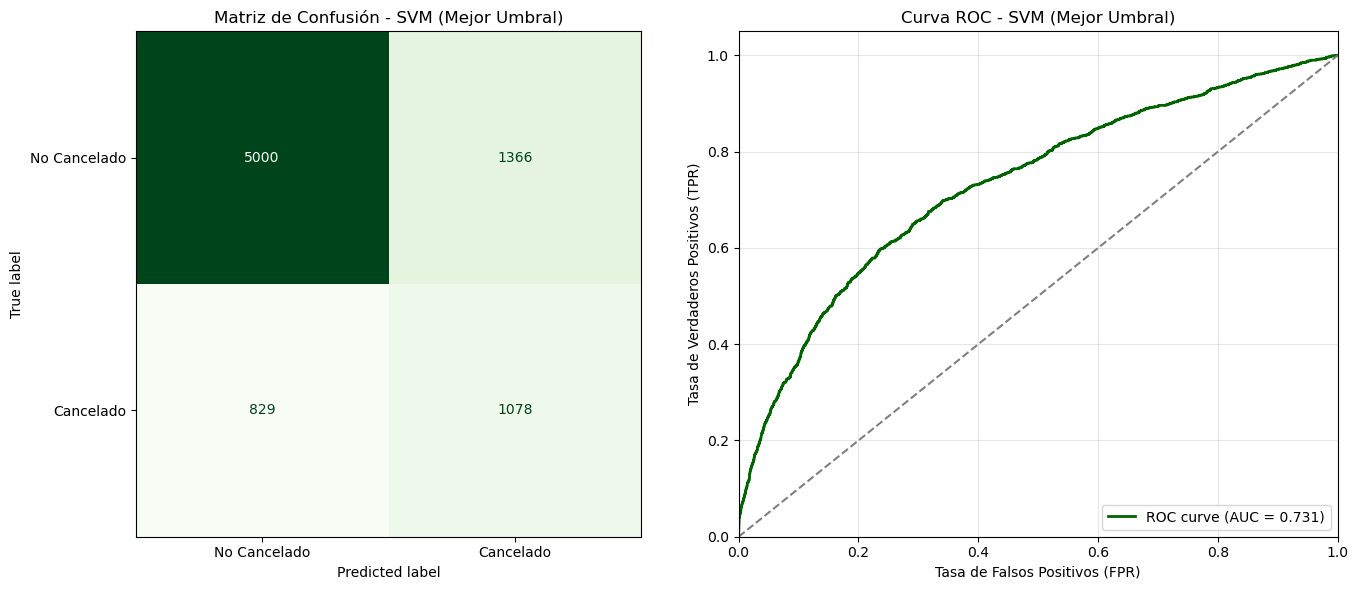

In [151]:
# Matriz de confusion:
cm_svm = confusion_matrix(y_test_pca, y_pred_svm_opt)
disp_svm = ConfusionMatrixDisplay(cm_svm, display_labels=['No Cancelado', 'Cancelado'])

fpr, tpr, thresholds = roc_curve(y_test_pca, y_proba_svm)
roc_auc = roc_auc_score(y_test_pca, y_proba_svm)

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Matriz de confusión
disp_svm.plot(cmap=plt.cm.Greens, ax=axes[0], colorbar=False, values_format='d')
axes[0].set_title("Matriz de Confusión - SVM (Mejor Umbral)")

# Curva ROC
axes[1].plot(fpr, tpr, color='darkgreen', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[1].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
axes[1].set_title('Curva ROC - SVM (Mejor Umbral)')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [152]:
#Clasification Report:
print("Classification Report - SVM\n")
print(classification_report(y_test_pca, y_pred_svm_opt, digits=4))

Classification Report - SVM

              precision    recall  f1-score   support

           0     0.8578    0.7854    0.8200      6366
           1     0.4411    0.5653    0.4955      1907

    accuracy                         0.7347      8273
   macro avg     0.6494    0.6754    0.6578      8273
weighted avg     0.7617    0.7347    0.7452      8273



In [153]:
#Tabla de metricas:
metricas_SVM = pd.DataFrame({
    "Accuracy": [accuracy_score(y_test_pca, y_pred_svm_opt)],
    "Precision": [precision_score(y_test_pca, y_pred_svm_opt)],
    "Recall": [recall_score(y_test_pca, y_pred_svm_opt)],
    "F1-score": [f1_score(y_test_pca, y_pred_svm_opt)],
    "ROC-AUC": [roc_auc]
}, index=["SVM Baseline"])

print(metricas_SVM)


              Accuracy  Precision    Recall  F1-score   ROC-AUC
SVM Baseline  0.734679    0.44108  0.565286  0.495518  0.730791


### 3.2º Modelo: SVM Gridsearch

In [154]:
# Definir grid de hiperparámetros
param_grid_svm = {
    'C': [0.1, 1, 10], #Pongo estos valores solo porque sino el tiempo de ejecucion sera muy muy largo
    'gamma': ['scale', 0.01]
}

# Configurar GridSearch
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scorer = make_scorer(f1_score)

grid_svm = GridSearchCV(
    estimator=SVC(probability=True, random_state=42),
    param_grid=param_grid_svm,
    scoring=scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1
)

In [155]:
# Entrenar GridSearch
grid_svm.fit(X_train_pca, y_train_pca)

# Mejor modelo
svm_best = grid_svm.best_estimator_
print(f"Mejores parámetros SVM: {grid_svm.best_params_}")

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Mejores parámetros SVM: {'C': 10, 'gamma': 'scale'}


In [156]:
# Predicción sobre test
y_pred_svm_grid = svm_best.predict(X_test_pca)
y_proba_svm_grid = svm_best.predict_proba(X_test_pca)[:,1]

In [157]:
# Buscar mejor umbral según F1-score
best_threshold_svm_grid, best_f1_svm_grid = encontrar_mejor_umbral(
    model=svm_best,
    X_val=X_test_pca,
    y_val=y_test_pca,
    metrica="f1"
)

print(f"Mejor umbral SVM GridSearch: {best_threshold_svm_grid:.2f}")
print(f"Mejor F1-score con ese umbral: {best_f1_svm_grid:.4f}")

# Predicciones usando el mejor umbral
y_pred_svm_grid_opt = (y_proba_svm_grid >= best_threshold_svm_grid).astype(int)


Mejor umbral SVM GridSearch: 0.22
Mejor F1-score con ese umbral: 0.5061


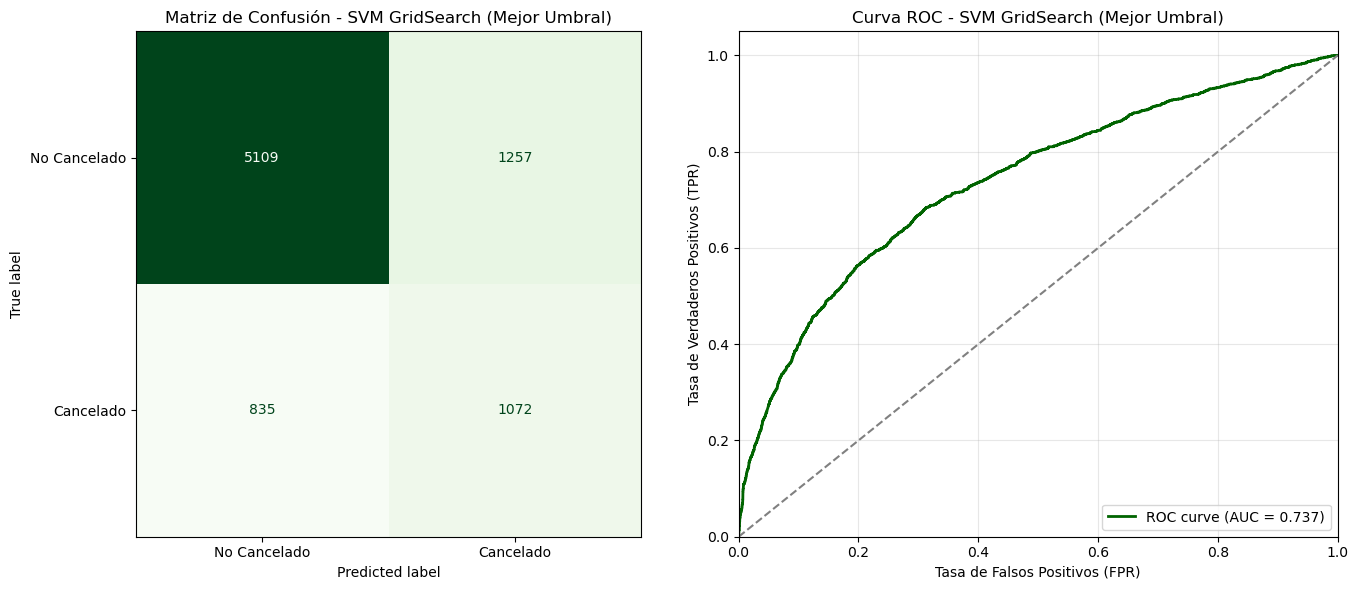

              precision    recall  f1-score   support

           0     0.8178    0.9398    0.8746      6366
           1     0.5998    0.3010    0.4008      1907

    accuracy                         0.7926      8273
   macro avg     0.7088    0.6204    0.6377      8273
weighted avg     0.7675    0.7926    0.7654      8273



In [158]:
# Matriz de confusión
cm_svm_grid = confusion_matrix(y_test_pca, y_pred_svm_grid_opt)
disp_svm_grid = ConfusionMatrixDisplay(cm_svm_grid, display_labels=['No Cancelado', 'Cancelado'])

fpr, tpr, thresholds = roc_curve(y_test_pca, y_proba_svm_grid)
roc_auc = roc_auc_score(y_test_pca, y_proba_svm_grid)

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Matriz de confusión
disp_svm_grid.plot(cmap=plt.cm.Greens, ax=axes[0], colorbar=False, values_format='d')
axes[0].set_title("Matriz de Confusión - SVM GridSearch (Mejor Umbral)")

# Curva ROC
axes[1].plot(fpr, tpr, color='darkgreen', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[1].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
axes[1].set_title('Curva ROC - SVM GridSearch (Mejor Umbral)')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


# Classification Report
print(classification_report(y_test_pca, y_pred_svm_grid, digits=4))

In [159]:
# Calcular métricas
metricas_SVM_GRID_opt = pd.DataFrame({
    "Accuracy": [accuracy_score(y_test_pca, y_pred_svm_grid_opt)],
    "Precision": [precision_score(y_test_pca, y_pred_svm_grid_opt)],
    "Recall": [recall_score(y_test_pca, y_pred_svm_grid_opt)],
    "F1-score": [f1_score(y_test_pca, y_pred_svm_grid_opt)],
    "ROC-AUC": [roc_auc]
}, index=["SVM GridSearch (Mejor Umbral)"])

print(metricas_SVM_GRID_opt)

                               Accuracy  Precision    Recall  F1-score  \
SVM GridSearch (Mejor Umbral)  0.747129   0.460283  0.562139  0.506138   

                                ROC-AUC  
SVM GridSearch (Mejor Umbral)  0.737426  


### 3.3º Modelo: SVM SMOTE

In [160]:
# Entrenar SVM sobre datos balanceados
svm_smote = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
svm_smote.fit(X_train_res, y_train_res)

# 3. Predicción probabilística sobre test
y_proba_svm_smote = svm_smote.predict_proba(X_test_pca)[:, 1]


In [161]:
# 5. Buscar el mejor umbral según F1-score
best_threshold_svm_smote, best_f1_svm_smote = encontrar_mejor_umbral(
    model=svm_smote,
    X_val=X_test_pca,
    y_val=y_test_pca,
    metrica="f1"
)

print(f"Mejor umbral SVM SMOTE: {best_threshold_svm_smote:.2f}")
print(f"Mejor F1-score con ese umbral: {best_f1_svm_smote:.4f}")

# 6. Predicciones con el mejor umbral
y_pred_svm_smote_opt = (y_proba_svm_smote >= best_threshold_svm_smote).astype(int)


Mejor umbral SVM SMOTE: 0.51
Mejor F1-score con ese umbral: 0.5157


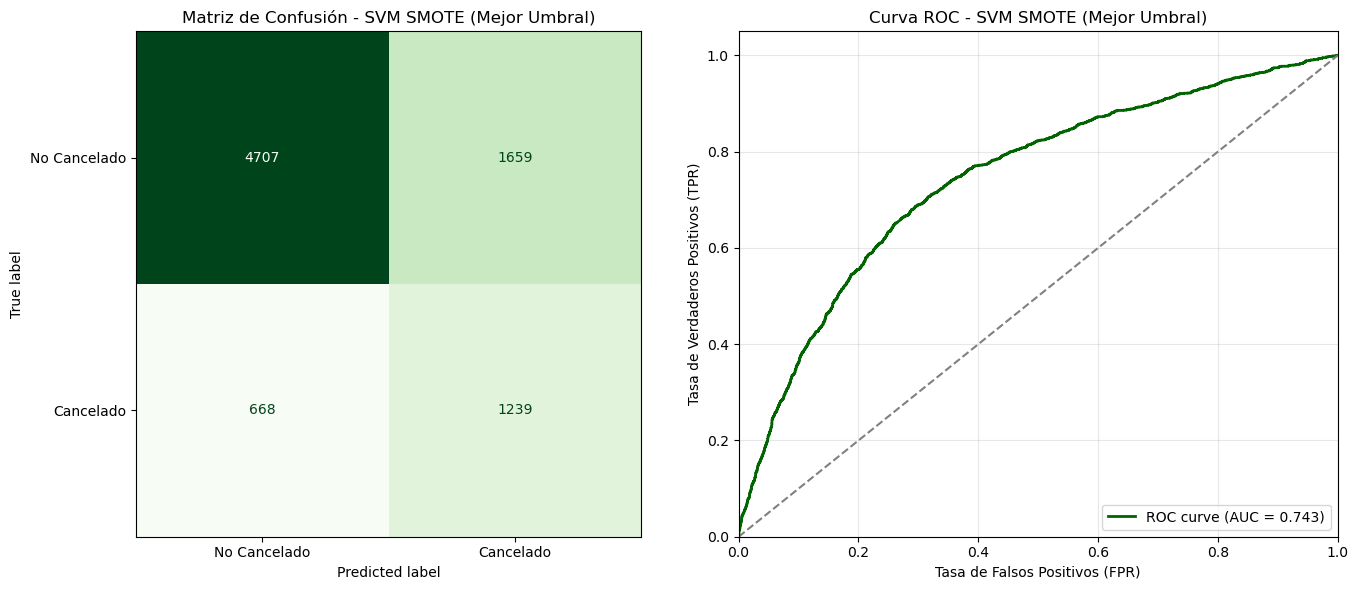

In [162]:
# Matriz de confusión
cm_svm_smote = confusion_matrix(y_test_pca, y_pred_svm_smote_opt)
disp_svm_smote = ConfusionMatrixDisplay(cm_svm_smote, display_labels=['No Cancelado', 'Cancelado'])

fpr, tpr, thresholds = roc_curve(y_test_pca, y_proba_svm_smote)
roc_auc = roc_auc_score(y_test_pca, y_proba_svm_smote)

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Matriz de confusión
disp_svm_smote.plot(cmap=plt.cm.Greens, ax=axes[0], colorbar=False, values_format='d')
axes[0].set_title("Matriz de Confusión - SVM SMOTE (Mejor Umbral)")

# Curva ROC
axes[1].plot(fpr, tpr, color='darkgreen', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[1].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
axes[1].set_title('Curva ROC - SVM SMOTE (Mejor Umbral)')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [163]:
# Classification Report
print(classification_report(y_test_pca, y_pred_svm_smote_opt, digits=4))

# 8. Calcular métricas usando el mejor umbral
metricas_SVM_SMOTE = pd.DataFrame({
    "Accuracy": [accuracy_score(y_test_pca, y_pred_svm_smote_opt)],
    "Precision": [precision_score(y_test_pca, y_pred_svm_smote_opt)],
    "Recall": [recall_score(y_test_pca, y_pred_svm_smote_opt)],
    "F1-score": [f1_score(y_test_pca, y_pred_svm_smote_opt)],
    "ROC-AUC": [roc_auc]
}, index=["SVM SMOTE (Mejor Umbral)"])

print(metricas_SVM_SMOTE)

              precision    recall  f1-score   support

           0     0.8757    0.7394    0.8018      6366
           1     0.4275    0.6497    0.5157      1907

    accuracy                         0.7187      8273
   macro avg     0.6516    0.6946    0.6588      8273
weighted avg     0.7724    0.7187    0.7359      8273

                          Accuracy  Precision    Recall  F1-score   ROC-AUC
SVM SMOTE (Mejor Umbral)  0.718724   0.427536  0.649712  0.515713  0.742739


### 3.4º Modelo: SVM SMOTE + Gridsearch

In [164]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Se ha tenido que realizar unos cambios ya que la imputacion era muy larga (300 minutos)
# 
# CAMBIO 1:
#  Quitamos probability=True SOLO durante el GridSearch
#  Entrenar probabilidades duplica el tiempo

# CAMBIO 2:
#  Reducimos el número de folds (cv)
#  3 folds es suficiente y mucho más rápido que 5

# CAMBIO 3:
#  Aseguramos un param_grid pequeño
#  Menos combinaciones = menos tiempo

param_grid_svm_fast = {
    'C': [0.1, 1],
    'kernel': ['rbf'],
    'gamma': ['scale']
}

grid_svm_smote_fast = GridSearchCV(
    estimator=SVC(
        random_state=42  #  SIN probability=True aquí
    ),
    param_grid=param_grid_svm_fast,
    scoring=scorer,
    cv=3,              # antes: cv=cv (probablemente 5)
    n_jobs=-1,
    verbose=1
)

# Entrenamiento (MUCHO MÁS RÁPIDO)
grid_svm_smote_fast.fit(X_train_res, y_train_res)

# Mejor modelo (aún sin probabilidades)
svm_best_smote = grid_svm_smote_fast.best_estimator_

print(f"Mejores parámetros SVM (GridSearch + SMOTE, rápido): {grid_svm_smote_fast.best_params_}")


Fitting 3 folds for each of 2 candidates, totalling 6 fits
Mejores parámetros SVM (GridSearch + SMOTE, rápido): {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}


In [165]:
# 2. Reentrenar el modelo con probability=True para asegurar predict_proba
svm_best_smote_proba = SVC(
    C=svm_best_smote.C,
    kernel=svm_best_smote.kernel,
    gamma=svm_best_smote.gamma,
    random_state=42,
    probability=True
)
svm_best_smote_proba.fit(X_train_res, y_train_res)

# 3. Predicciones probabilísticas sobre test
y_proba_svm_grid_smote = svm_best_smote_proba.predict_proba(X_test_pca)[:, 1]


In [166]:
# 4. Buscar el mejor umbral según F1-score usando el modelo con probabilidades
best_threshold_svm_grid_smote, best_f1_svm_grid_smote = encontrar_mejor_umbral(
    model=svm_best_smote_proba,  # <--- usar este modelo
    X_val=X_test_pca,
    y_val=y_test_pca,
    metrica="f1"
)

print(f"Mejor umbral SVM GridSearch + SMOTE: {best_threshold_svm_grid_smote:.2f}")
print(f"Mejor F1-score con ese umbral: {best_f1_svm_grid_smote:.4f}")

# 5. Predicciones con el mejor umbral
y_pred_svm_grid_smote_opt = (y_proba_svm_grid_smote >= best_threshold_svm_grid_smote).astype(int)


Mejor umbral SVM GridSearch + SMOTE: 0.51
Mejor F1-score con ese umbral: 0.5157


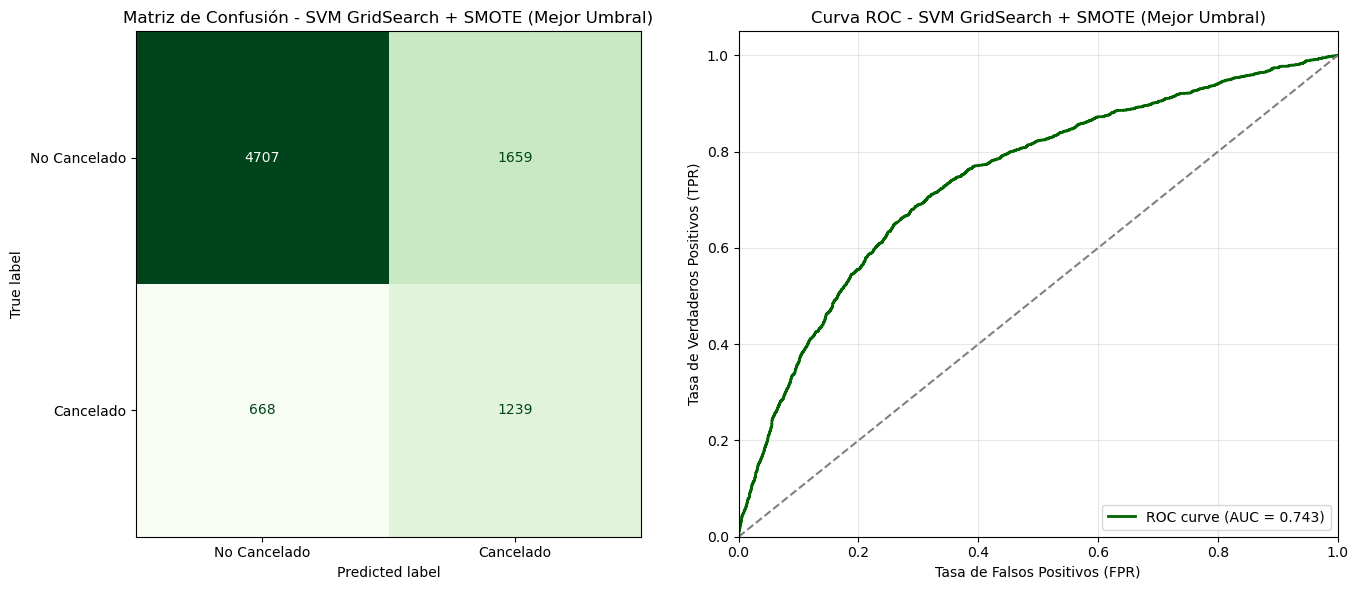

In [167]:
# Matriz de confusión
cm_svm_grid_smote = confusion_matrix(y_test_pca, y_pred_svm_grid_smote_opt)
disp_svm_grid_smote = ConfusionMatrixDisplay(cm_svm_grid_smote, display_labels=['No Cancelado', 'Cancelado'])

fpr, tpr, thresholds = roc_curve(y_test_pca, y_proba_svm_grid_smote)
roc_auc = roc_auc_score(y_test_pca, y_proba_svm_grid_smote)

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Matriz de confusión
disp_svm_grid_smote.plot(cmap=plt.cm.Greens, ax=axes[0], colorbar=False, values_format='d')
axes[0].set_title("Matriz de Confusión - SVM GridSearch + SMOTE (Mejor Umbral)")

# Curva ROC
axes[1].plot(fpr, tpr, color='darkgreen', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[1].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
axes[1].set_title('Curva ROC - SVM GridSearch + SMOTE (Mejor Umbral)')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [168]:
# Calcular métricas
metricas_SVM_GRID_SMOTE_opt = pd.DataFrame({
    "Accuracy": [accuracy_score(y_test_pca, y_pred_svm_grid_smote_opt)],
    "Precision": [precision_score(y_test_pca, y_pred_svm_grid_smote_opt)],
    "Recall": [recall_score(y_test_pca, y_pred_svm_grid_smote_opt)],
    "F1-score": [f1_score(y_test_pca, y_pred_svm_grid_smote_opt)],
    "ROC-AUC": [roc_auc]
}, index=["SVM GridSearch + SMOTE"])

print(metricas_SVM_GRID_SMOTE_opt)

                        Accuracy  Precision    Recall  F1-score   ROC-AUC
SVM GridSearch + SMOTE  0.718724   0.427536  0.649712  0.515713  0.742739


### Comparacion los cuatro modelos de SVM

In [169]:
# Comparación de todos los modelos SVM usando las métricas con el mejor umbral
metricas_modelos_svm = pd.concat([
    metricas_SVM,                   # SVM baseline
    metricas_SVM_GRID_opt,              # SVM GridSearch
    metricas_SVM_SMOTE,             # SVM SMOTE
    metricas_SVM_GRID_SMOTE_opt     # SVM GridSearch + SMOTE con mejor umbral
])

# Mostrar la tabla comparativa
print(metricas_modelos_svm)


                               Accuracy  Precision    Recall  F1-score  \
SVM Baseline                   0.734679   0.441080  0.565286  0.495518   
SVM GridSearch (Mejor Umbral)  0.747129   0.460283  0.562139  0.506138   
SVM SMOTE (Mejor Umbral)       0.718724   0.427536  0.649712  0.515713   
SVM GridSearch + SMOTE         0.718724   0.427536  0.649712  0.515713   

                                ROC-AUC  
SVM Baseline                   0.730791  
SVM GridSearch (Mejor Umbral)  0.737426  
SVM SMOTE (Mejor Umbral)       0.742739  
SVM GridSearch + SMOTE         0.742739  


# =========================================

# MODELOS ARBOL DE DECISION

## 4º Modelo: Arbol de Decision

In [170]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score


Codigo para la seleccion de los mejores parametros para el Modelo

In [171]:
# --- 1. Modelo base ---
tree_clf = DecisionTreeClassifier(random_state=42)

# --- 2. Grid de hiperparámetros ---
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# --- 3. Configurar GridSearchCV ---
scorer = make_scorer(f1_score)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=tree_clf,
    param_grid=param_grid,
    scoring=scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1
)

# --- 4. Entrenar GridSearchCV ---
grid_search.fit(X_train_pca, y_train_pca)

# --- 5. Mejor modelo ---
tree_best = grid_search.best_estimator_
print("Mejores parámetros Decision Tree:", grid_search.best_params_)

# --- 6. Predicciones sobre test ---
y_pred_tree = tree_best.predict(X_test_pca)
y_proba_tree = tree_best.predict_proba(X_test_pca)[:, 1]  # Probabilidad clase positiva


Fitting 5 folds for each of 72 candidates, totalling 360 fits
Mejores parámetros Decision Tree: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [172]:
# --- 7. Buscar mejor umbral para maximizar F1 ---
best_threshold_tree, best_f1_tree = encontrar_mejor_umbral(
    model=tree_best,
    X_val=X_test_pca,
    y_val=y_test_pca,
    metrica="f1"
)

print(f"Mejor umbral para Decision Tree: {best_threshold_tree:.2f}")
print(f"Mejor F1-score con ese umbral: {best_f1_tree:.4f}")

# --- 8. Predicciones usando mejor umbral ---
y_pred_tree_opt = (y_proba_tree >= best_threshold_tree).astype(int)


Mejor umbral para Decision Tree: 0.10
Mejor F1-score con ese umbral: 0.4404


In [173]:
# Entrenamiento modelo:
# Instanciar Árbol de Decisión
tree_clf = DecisionTreeClassifier(
    criterion='entropy',        # índice de Gini (también se puede usar 'entropy')
    max_depth=None,           # sin límite de profundidad, se puede ajustar
    random_state=42,
    min_samples_leaf=4,
    min_samples_split= 10
)

# Entrenar modelo
tree_clf.fit(X_train_pca, y_train_pca)

DecisionTreeClassifier(criterion='entropy', min_samples_leaf=4,
                       min_samples_split=10, random_state=42)

In [174]:
# Predicciones:
y_pred_tree = tree_clf.predict(X_test_pca)
y_proba_tree = tree_clf.predict_proba(X_test_pca)[:, 1]

In [175]:
# Numero de errores:
print(
    "Número de puntos mal clasificados: %d de %d"
    % ((y_test_pca != y_pred_tree).sum(), y_test_pca.shape[0])
)

Número de puntos mal clasificados: 2142 de 8273


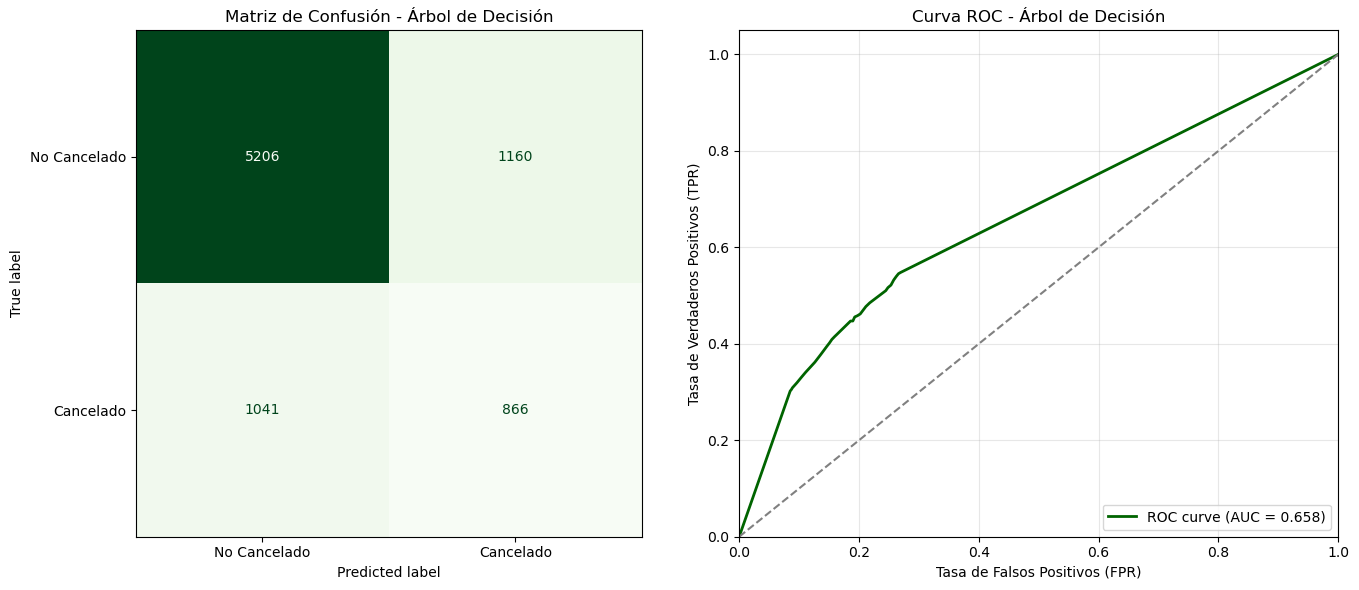

In [176]:
# Matriz de confusion:
cm_tree = confusion_matrix(y_test_pca, y_pred_tree_opt)
disp_tree = ConfusionMatrixDisplay(cm_tree, display_labels=['No Cancelado', 'Cancelado'])

# --- 10. Curva ROC ---
fpr, tpr, thresholds = roc_curve(y_test_pca, y_proba_tree)
roc_auc = roc_auc_score(y_test_pca, y_proba_tree)

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Matriz de confusión
disp_tree.plot(cmap=plt.cm.Greens, ax=axes[0], colorbar=False, values_format='d')
axes[0].set_title("Matriz de Confusión - Árbol de Decisión")

# Curva ROC
axes[1].plot(fpr, tpr, color='darkgreen', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[1].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
axes[1].set_title('Curva ROC - Árbol de Decisión')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [177]:
# Clasification report:
print("Classification Report - Árbol de Decisión (mejor umbral)\n")
print(classification_report(y_test_pca, y_pred_tree_opt, digits=4))

Classification Report - Árbol de Decisión (mejor umbral)

              precision    recall  f1-score   support

           0     0.8334    0.8178    0.8255      6366
           1     0.4274    0.4541    0.4404      1907

    accuracy                         0.7340      8273
   macro avg     0.6304    0.6359    0.6329      8273
weighted avg     0.7398    0.7340    0.7367      8273



In [178]:
# Tabla metricas:
metricas_ARBOL_DECISION = pd.DataFrame({
    "Accuracy": [accuracy_score(y_test_pca, y_pred_tree_opt)],
    "Precision": [precision_score(y_test_pca, y_pred_tree_opt)],
    "Recall": [recall_score(y_test_pca, y_pred_tree_opt)],
    "F1-score": [f1_score(y_test_pca, y_pred_tree_opt)],
    "ROC-AUC": [roc_auc_score(y_test_pca, y_proba_tree)]
}, index=["Decision Tree (GridSearch)"])

metricas_ARBOL_DECISION


,Accuracy,Precision,Recall,F1-score,ROC-AUC
Decision Tree (GridSearch),0.733954,0.427443,0.454116,0.440376,0.657581


### 4.2º Modelo ARBOL DECISION SMOTE

In [179]:
# --- 2. Entrenar modelo Decision Tree sobre datos balanceados ---
tree_smote = DecisionTreeClassifier(random_state=42)
tree_smote.fit(X_train_res, y_train_res)

# --- 3. Predicciones sobre test ---
y_proba_tree_smote = tree_smote.predict_proba(X_test_pca)[:, 1]  # Probabilidad clase positiva


In [180]:
# --- 4. Buscar mejor umbral para maximizar F1 ---
best_threshold_tree_smote, best_f1_tree_smote = encontrar_mejor_umbral(
    model=tree_smote,
    X_val=X_test_pca,
    y_val=y_test_pca,
    metrica="f1"
)

print(f"Mejor umbral para Decision Tree SMOTE: {best_threshold_tree_smote:.2f}")
print(f"Mejor F1-score con ese umbral: {best_f1_tree_smote:.4f}")

# --- 5. Predicciones usando el mejor umbral ---
y_pred_tree_smote_opt = (y_proba_tree_smote >= best_threshold_tree_smote).astype(int)


Mejor umbral para Decision Tree SMOTE: 0.81
Mejor F1-score con ese umbral: 0.4473


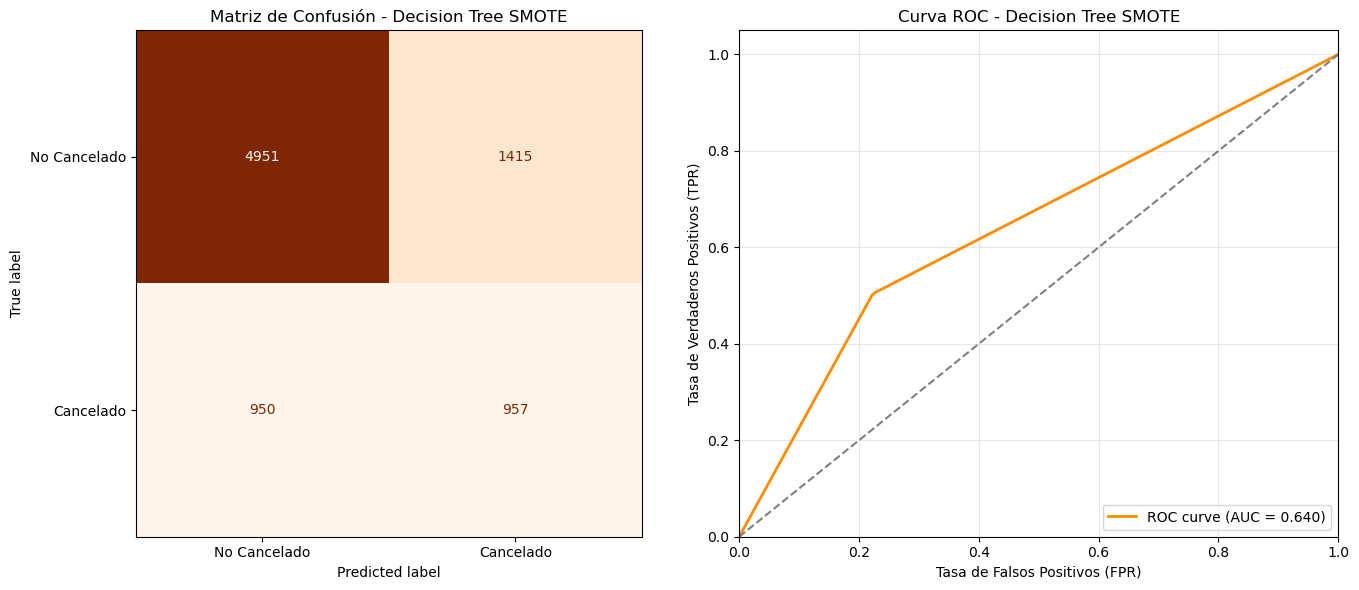

In [181]:
# --- 6. Matriz de Confusión ---
cm_tree_smote = confusion_matrix(y_test_pca, y_pred_tree_smote_opt)
disp_tree_smote = ConfusionMatrixDisplay(cm_tree_smote, display_labels=['No Cancelado', 'Cancelado'])

# --- 7. Curva ROC ---
fpr, tpr, thresholds = roc_curve(y_test_pca, y_proba_tree_smote)
roc_auc = roc_auc_score(y_test_pca, y_proba_tree_smote)

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Matriz de confusión
disp_tree_smote.plot(cmap=plt.cm.Oranges, ax=axes[0], colorbar=False, values_format='d')
axes[0].set_title("Matriz de Confusión - Decision Tree SMOTE")

# Curva ROC
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[1].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
axes[1].set_title('Curva ROC - Decision Tree SMOTE')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [182]:
# --- 8. Classification Report ---
print("Classification Report - Decision Tree SMOTE (mejor umbral)\n")
print(classification_report(y_test_pca, y_pred_tree_smote_opt, digits=4))


Classification Report - Decision Tree SMOTE (mejor umbral)

              precision    recall  f1-score   support

           0     0.8390    0.7777    0.8072      6366
           1     0.4035    0.5018    0.4473      1907

    accuracy                         0.7141      8273
   macro avg     0.6212    0.6398    0.6273      8273
weighted avg     0.7386    0.7141    0.7242      8273



In [183]:
# --- 9. Tabla de métricas ---
metricas_ARBOL_DECISION_SMOTE = pd.DataFrame({
    "Accuracy": [accuracy_score(y_test_pca, y_pred_tree_smote_opt)],
    "Precision": [precision_score(y_test_pca, y_pred_tree_smote_opt)],
    "Recall": [recall_score(y_test_pca, y_pred_tree_smote_opt)],
    "F1-score": [f1_score(y_test_pca, y_pred_tree_smote_opt)],
    "ROC-AUC": [roc_auc_score(y_test_pca, y_proba_tree_smote)]
}, index=["Decision Tree SMOTE (Mejor Umbral)"])

metricas_ARBOL_DECISION_SMOTE

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Decision Tree SMOTE (Mejor Umbral),0.71413,0.403457,0.501835,0.447301,0.640323


### 4.3º Modelo: ARBOL DECISION SMOTE + Gridsearch

In [185]:
# --- 1. GridSearch sobre datos con SMOTE ---
grid_tree_smote = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    scoring=scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1
)

# Entrenar GridSearch con SMOTE
grid_tree_smote.fit(X_train_res, y_train_res)

# Mejor modelo
tree_best_smote = grid_tree_smote.best_estimator_
print(f"Mejores parámetros (Decision Tree + SMOTE + GridSearch): {grid_tree_smote.best_params_}")

# --- 2. Predicciones sobre test ---
y_proba_tree_grid_smote = tree_best_smote.predict_proba(X_test_pca)[:, 1]  # Probabilidad clase positiva


Fitting 5 folds for each of 72 candidates, totalling 360 fits
Mejores parámetros (Decision Tree + SMOTE + GridSearch): {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [186]:

# --- 3. Buscar mejor umbral para maximizar F1 ---
best_threshold_tree_grid_smote, best_f1_tree_grid_smote = encontrar_mejor_umbral(
    model=tree_best_smote,
    X_val=X_test_pca,
    y_val=y_test_pca,
    metrica="f1"
)

print(f"Mejor umbral para Decision Tree GridSearch + SMOTE: {best_threshold_tree_grid_smote:.2f}")
print(f"Mejor F1-score con ese umbral: {best_f1_tree_grid_smote:.4f}")

# --- 4. Predicciones usando el mejor umbral ---
y_pred_tree_grid_smote_opt = (y_proba_tree_grid_smote >= best_threshold_tree_grid_smote).astype(int)


Mejor umbral para Decision Tree GridSearch + SMOTE: 0.10
Mejor F1-score con ese umbral: 0.4472


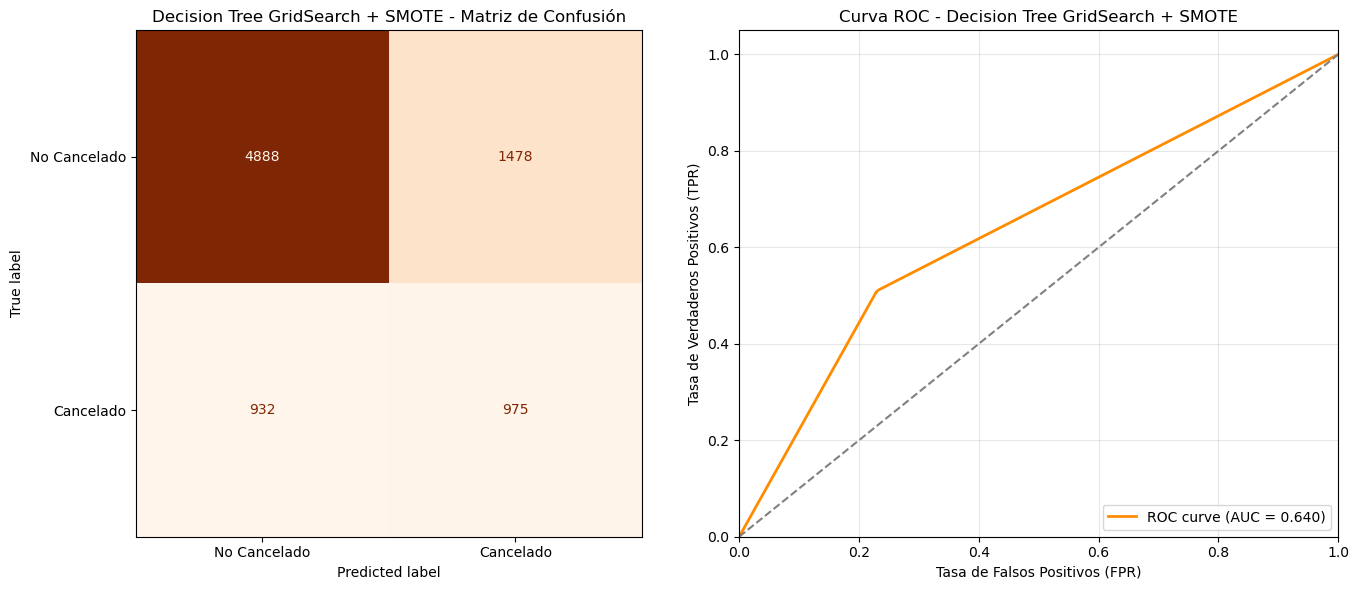

In [187]:
# --- 5. Matriz de Confusión + Curva ROC ---
cm_tree_grid_smote = confusion_matrix(y_test_pca, y_pred_tree_grid_smote_opt)
disp_tree_grid_smote = ConfusionMatrixDisplay(cm_tree_grid_smote, display_labels=['No Cancelado', 'Cancelado'])

fpr, tpr, thresholds = roc_curve(y_test_pca, y_proba_tree_grid_smote)
roc_auc = roc_auc_score(y_test_pca, y_proba_tree_grid_smote)

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Matriz de confusión
disp_tree_grid_smote.plot(cmap=plt.cm.Oranges, ax=axes[0], colorbar=False, values_format='d')
axes[0].set_title("Decision Tree GridSearch + SMOTE - Matriz de Confusión")

# Curva ROC
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[1].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
axes[1].set_title('Curva ROC - Decision Tree GridSearch + SMOTE')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [188]:
# --- 6. Classification Report ---
print("Decision Tree GridSearch + SMOTE - Classification Report (mejor umbral)\n")
print(classification_report(y_test_pca, y_pred_tree_grid_smote_opt, digits=4))

Decision Tree GridSearch + SMOTE - Classification Report (mejor umbral)

              precision    recall  f1-score   support

           0     0.8399    0.7678    0.8022      6366
           1     0.3975    0.5113    0.4472      1907

    accuracy                         0.7087      8273
   macro avg     0.6187    0.6396    0.6247      8273
weighted avg     0.7379    0.7087    0.7204      8273



In [189]:
# --- 7. Tabla de métricas ---
metricas_ARBOL_DECISION_GRID_SMOTE = pd.DataFrame({
    "Accuracy": [accuracy_score(y_test_pca, y_pred_tree_grid_smote_opt)],
    "Precision": [precision_score(y_test_pca, y_pred_tree_grid_smote_opt)],
    "Recall": [recall_score(y_test_pca, y_pred_tree_grid_smote_opt)],
    "F1-score": [f1_score(y_test_pca, y_pred_tree_grid_smote_opt)],
    "ROC-AUC": [roc_auc_score(y_test_pca, y_proba_tree_grid_smote)]
}, index=["Decision Tree GridSearch + SMOTE"])

### Comparar metricas de modelos ARBOL DECISION

In [190]:
metricas_modelos_arbol = pd.concat([
    metricas_ARBOL_DECISION,
    metricas_ARBOL_DECISION_SMOTE,
    metricas_ARBOL_DECISION_GRID_SMOTE
])

print(metricas_modelos_arbol)

                                    Accuracy  Precision    Recall  F1-score  \
Decision Tree (GridSearch)          0.733954   0.427443  0.454116  0.440376   
Decision Tree SMOTE (Mejor Umbral)  0.714130   0.403457  0.501835  0.447301   
Decision Tree GridSearch + SMOTE    0.708691   0.397472  0.511274  0.447248   

                                     ROC-AUC  
Decision Tree (GridSearch)          0.657581  
Decision Tree SMOTE (Mejor Umbral)  0.640323  
Decision Tree GridSearch + SMOTE    0.639967  


# ==================================

# MODELOS RANDOM FOREST

### 5º Modelo: Random Forest

In [191]:
# --- 1. Entrenamiento Random Forest ---
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(
    n_estimators=100,  # número de árboles
    criterion='gini',
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_clf.fit(X_train_pca, y_train_pca)

# --- 2. Predicciones sobre test ---
y_proba_rf = rf_clf.predict_proba(X_test_pca)[:, 1]  # probabilidad clase positiva


In [192]:
# --- 3. Buscar mejor umbral para maximizar F1 ---
best_threshold_rf, best_f1_rf = encontrar_mejor_umbral(
    model=rf_clf,
    X_val=X_test_pca,
    y_val=y_test_pca,
    metrica="f1"
)

print(f"Mejor umbral para Random Forest: {best_threshold_rf:.2f}")
print(f"Mejor F1-score con ese umbral: {best_f1_rf:.4f}")

# --- 4. Predicciones usando el mejor umbral ---
y_pred_rf_opt = (y_proba_rf >= best_threshold_rf).astype(int)

Mejor umbral para Random Forest: 0.25
Mejor F1-score con ese umbral: 0.5362


In [193]:
# Numero de errores:
print(
    "Número de puntos mal clasificados: %d de %d"
    % ((y_test_pca != y_pred_rf_opt).sum(), y_test_pca.shape[0])
)

Número de puntos mal clasificados: 2259 de 8273


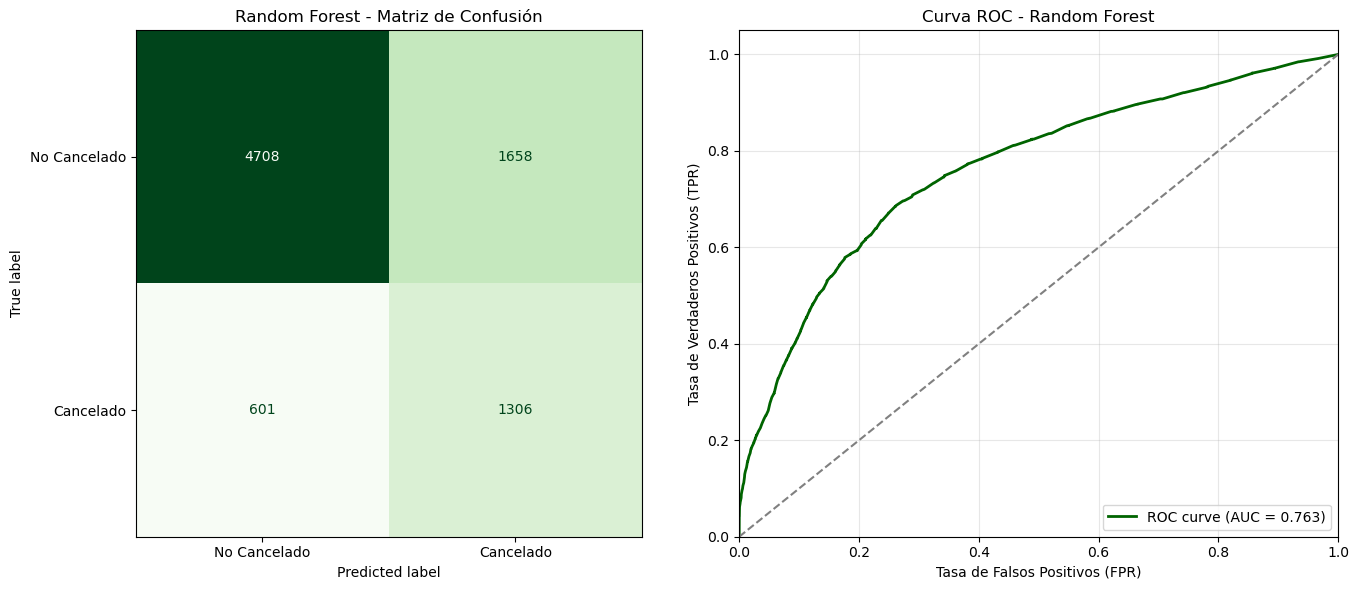

In [194]:
# Matriz de confusion:
# --- 5. Matriz de Confusión + Curva ROC ---
cm_rf = confusion_matrix(y_test_pca, y_pred_rf_opt)
disp_rf = ConfusionMatrixDisplay(cm_rf, display_labels=['No Cancelado', 'Cancelado'])

fpr, tpr, thresholds = roc_curve(y_test_pca, y_proba_rf)
roc_auc = roc_auc_score(y_test_pca, y_proba_rf)

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Matriz de confusión
disp_rf.plot(cmap=plt.cm.Greens, ax=axes[0], colorbar=False, values_format='d')
axes[0].set_title("Random Forest - Matriz de Confusión")

# Curva ROC
axes[1].plot(fpr, tpr, color='darkgreen', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[1].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
axes[1].set_title('Curva ROC - Random Forest')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [195]:
# Clasification Report:
print("Classification Report - Random Forest\n")
print(classification_report(y_test_pca, y_pred_rf_opt, digits=4))

Classification Report - Random Forest

              precision    recall  f1-score   support

           0     0.8868    0.7396    0.8065      6366
           1     0.4406    0.6848    0.5362      1907

    accuracy                         0.7269      8273
   macro avg     0.6637    0.7122    0.6714      8273
weighted avg     0.7839    0.7269    0.7442      8273



In [196]:
# Tabla metricas:
metricas_RANDOM_FOREST = pd.DataFrame({
    "Accuracy": [accuracy_score(y_test_pca, y_pred_rf_opt)],
    "Precision": [precision_score(y_test_pca, y_pred_rf_opt)],
    "Recall": [recall_score(y_test_pca, y_pred_rf_opt)],
    "F1-score": [f1_score(y_test_pca, y_pred_rf_opt)],
    "ROC-AUC": [roc_auc_score(y_test_pca, y_proba_rf)]
}, index=["Random Forest (Mejor Umbral)"])

print(metricas_RANDOM_FOREST)

                              Accuracy  Precision    Recall  F1-score  \
Random Forest (Mejor Umbral)  0.726943   0.440621  0.684845  0.536235   

                               ROC-AUC  
Random Forest (Mejor Umbral)  0.762887  


### 5.2º Modelo: RANDOM FOREST Gridsearch

In [197]:
# --- 1. GridSearch Random Forest ---
param_grid_rf = { 
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

scorer = make_scorer(f1_score)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid_rf,
    scoring=scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1
)

# --- 2. Entrenar GridSearch ---
grid_rf.fit(X_train_pca, y_train_pca)

# Mejor modelo
rf_best = grid_rf.best_estimator_
print(f"Mejores parámetros (Random Forest + GridSearch): {grid_rf.best_params_}")

# --- 3. Predicciones ---
y_proba_rf_grid = rf_best.predict_proba(X_test_pca)[:, 1]


Fitting 5 folds for each of 162 candidates, totalling 810 fits
Mejores parámetros (Random Forest + GridSearch): {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 150}


In [198]:
# --- 4. Buscar mejor umbral para maximizar F1 ---
best_threshold_rf_grid, best_f1_rf_grid = encontrar_mejor_umbral(
    model=rf_best,
    X_val=X_test_pca,
    y_val=y_test_pca,
    metrica="f1"
)

print(f"Mejor umbral para Random Forest GridSearch: {best_threshold_rf_grid:.2f}")
print(f"Mejor F1-score con ese umbral: {best_f1_rf_grid:.4f}")

# --- 5. Predicciones usando mejor umbral ---
y_pred_rf_grid_opt = (y_proba_rf_grid >= best_threshold_rf_grid).astype(int)


Mejor umbral para Random Forest GridSearch: 0.24
Mejor F1-score con ese umbral: 0.5380


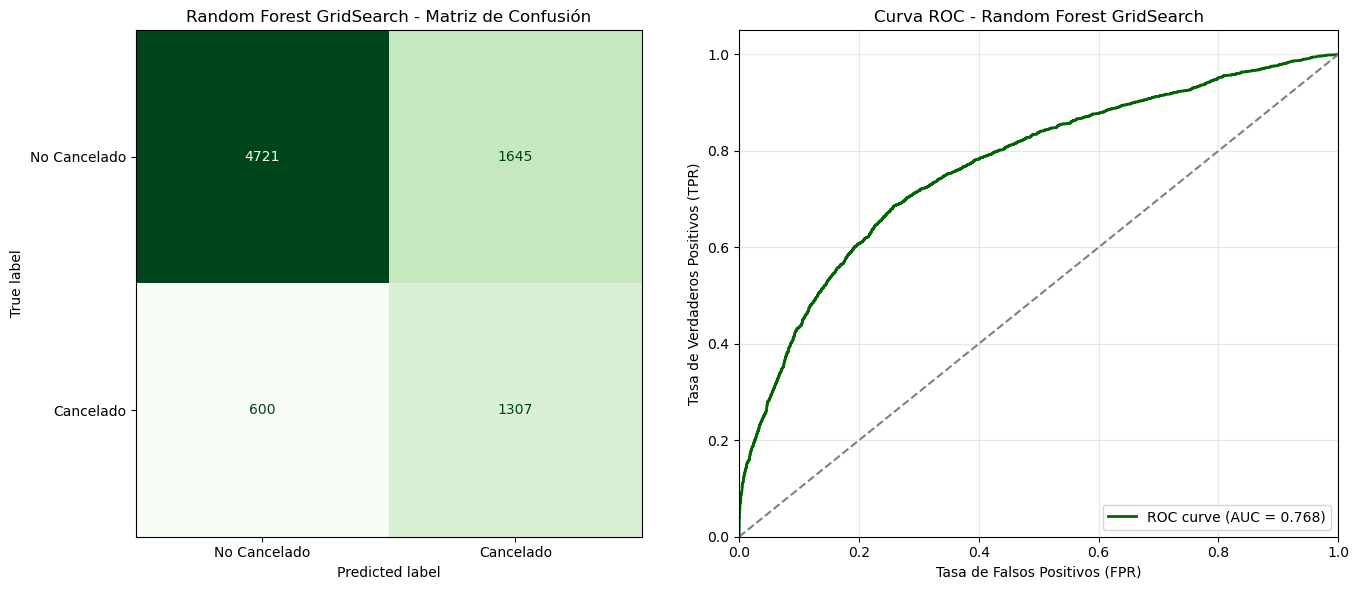

In [199]:
# --- 6. Matriz de Confusión + Curva ROC ---
cm_rf_grid = confusion_matrix(y_test_pca, y_pred_rf_grid_opt)
disp_rf_grid = ConfusionMatrixDisplay(cm_rf_grid, display_labels=['No Cancelado', 'Cancelado'])

fpr, tpr, thresholds = roc_curve(y_test_pca, y_proba_rf_grid)
roc_auc = roc_auc_score(y_test_pca, y_proba_rf_grid)

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Matriz de confusión
disp_rf_grid.plot(cmap=plt.cm.Greens, ax=axes[0], colorbar=False, values_format='d')
axes[0].set_title("Random Forest GridSearch - Matriz de Confusión")

# Curva ROC
axes[1].plot(fpr, tpr, color='darkgreen', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[1].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
axes[1].set_title('Curva ROC - Random Forest GridSearch')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [200]:
# Classification Report
print("Random Forest GridSearch - Classification Report:\n")
print(classification_report(y_test_pca, y_pred_rf_grid_opt, digits=4))

Random Forest GridSearch - Classification Report:

              precision    recall  f1-score   support

           0     0.8872    0.7416    0.8079      6366
           1     0.4428    0.6854    0.5380      1907

    accuracy                         0.7286      8273
   macro avg     0.6650    0.7135    0.6729      8273
weighted avg     0.7848    0.7286    0.7457      8273



In [201]:
# Métricas
metricas_RF_GRID = pd.DataFrame({
    "Accuracy": [accuracy_score(y_test_pca, y_pred_rf_grid_opt)],
    "Precision": [precision_score(y_test_pca, y_pred_rf_grid_opt)],
    "Recall": [recall_score(y_test_pca, y_pred_rf_grid_opt)],
    "F1-score": [f1_score(y_test_pca, y_pred_rf_grid_opt)],
    "ROC-AUC": [roc_auc_score(y_test_pca, y_proba_rf_grid)]
}, index=["Random Forest GridSearch"])

print(metricas_RF_GRID)

                          Accuracy  Precision   Recall  F1-score   ROC-AUC
Random Forest GridSearch  0.728635   0.442751  0.68537  0.537971  0.767512


### 5.3º Modelo RANDOM FOREST SMOTE

In [202]:
# --- 2. Entrenar Random Forest sobre datos balanceados ---
rf_smote = RandomForestClassifier(
    n_estimators=100,
    criterion='gini',
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf_smote.fit(X_train_res, y_train_res)

# --- 3. Predicciones ---
y_proba_rf_smote = rf_smote.predict_proba(X_test_pca)[:, 1]


In [203]:
# --- 4. Buscar mejor umbral para maximizar F1 ---
best_threshold_rf_smote, best_f1_rf_smote = encontrar_mejor_umbral(
    model=rf_smote,
    X_val=X_test_pca,
    y_val=y_test_pca,
    metrica="f1"
)

print(f"Mejor umbral para Random Forest SMOTE: {best_threshold_rf_smote:.2f}")
print(f"Mejor F1-score con ese umbral: {best_f1_rf_smote:.4f}")

# --- 5. Predicciones usando mejor umbral ---
y_pred_rf_smote_opt = (y_proba_rf_smote >= best_threshold_rf_smote).astype(int)


Mejor umbral para Random Forest SMOTE: 0.38
Mejor F1-score con ese umbral: 0.5331


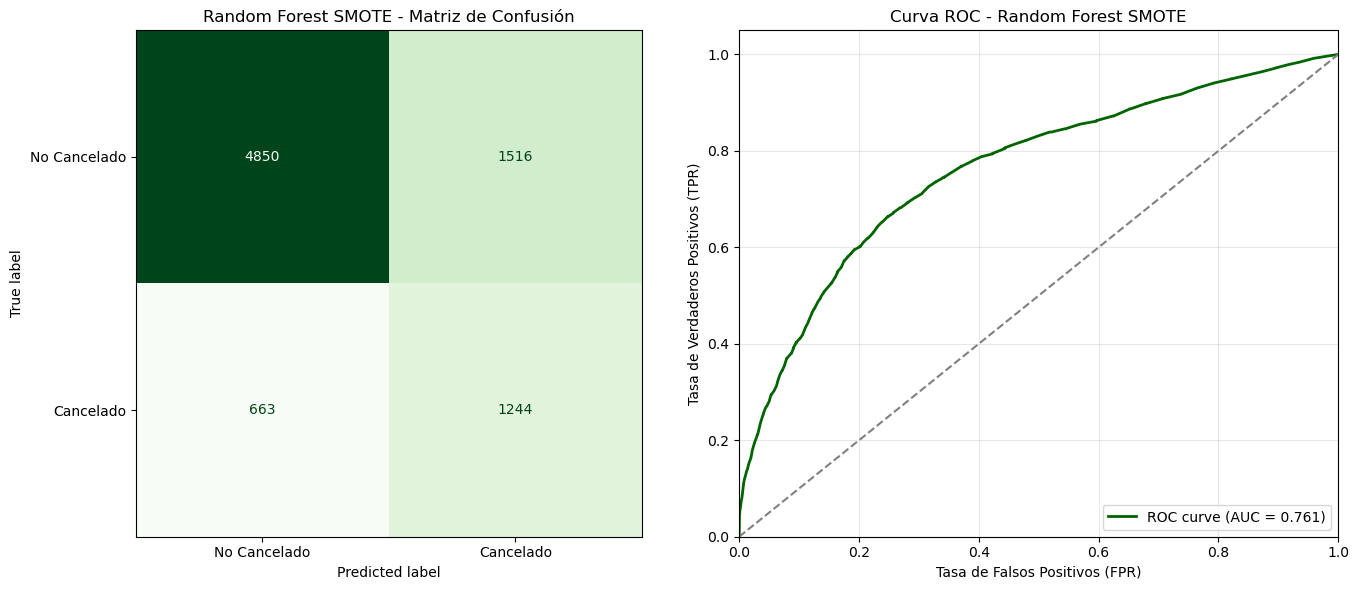

In [204]:
# --- 6. Matriz de Confusión + Curva ROC ---
cm_rf_smote = confusion_matrix(y_test_pca, y_pred_rf_smote_opt)
disp_rf_smote = ConfusionMatrixDisplay(cm_rf_smote, display_labels=['No Cancelado', 'Cancelado'])

fpr, tpr, thresholds = roc_curve(y_test_pca, y_proba_rf_smote)
roc_auc = roc_auc_score(y_test_pca, y_proba_rf_smote)

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Matriz de confusión
disp_rf_smote.plot(cmap=plt.cm.Greens, ax=axes[0], colorbar=False, values_format='d')
axes[0].set_title("Random Forest SMOTE - Matriz de Confusión")

# Curva ROC
axes[1].plot(fpr, tpr, color='darkgreen', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[1].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
axes[1].set_title('Curva ROC - Random Forest SMOTE')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [205]:
# Classification Report
print("Random Forest SMOTE - Classification Report:\n")
print(classification_report(y_test_pca, y_pred_rf_smote_opt, digits=4))

Random Forest SMOTE - Classification Report:

              precision    recall  f1-score   support

           0     0.8797    0.7619    0.8166      6366
           1     0.4507    0.6523    0.5331      1907

    accuracy                         0.7366      8273
   macro avg     0.6652    0.7071    0.6748      8273
weighted avg     0.7808    0.7366    0.7512      8273



In [206]:
# Métricas
metricas_RF_SMOTE = pd.DataFrame({
    "Accuracy": [accuracy_score(y_test_pca, y_pred_rf_smote_opt)],
    "Precision": [precision_score(y_test_pca, y_pred_rf_smote_opt)],
    "Recall": [recall_score(y_test_pca, y_pred_rf_smote_opt)],
    "F1-score": [f1_score(y_test_pca, y_pred_rf_smote_opt)],
    "ROC-AUC": [roc_auc_score(y_test_pca, y_proba_rf_smote)]
}, index=["Random Forest SMOTE"])

print(metricas_RF_SMOTE)

                     Accuracy  Precision    Recall  F1-score   ROC-AUC
Random Forest SMOTE  0.736613   0.450725  0.652334  0.533105  0.760707


### 5.4º Modelo RANDOM FOREST SMOTE + Gridsearch

In [207]:
#Random Forest SMOTE + GridSearch:

# --- 1. GridSearch sobre datos con SMOTE ya balanceados ---
grid_rf_smote = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid_rf,
    scoring=scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1
)

# Entrenamiento
grid_rf_smote.fit(X_train_res, y_train_res)

# Mejor modelo
rf_best_smote = grid_rf_smote.best_estimator_
print(f"Mejores parámetros (Random Forest + SMOTE + GridSearch): {grid_rf_smote.best_params_}")

# --- 2. Predicciones sobre test ---
y_proba_rf_grid_smote = rf_best_smote.predict_proba(X_test_pca)[:, 1]


Fitting 5 folds for each of 162 candidates, totalling 810 fits
Mejores parámetros (Random Forest + SMOTE + GridSearch): {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 150}


In [208]:

# --- 3. Buscar mejor umbral para maximizar F1 ---
best_threshold_rf_grid_smote, best_f1_rf_grid_smote = encontrar_mejor_umbral(
    model=rf_best_smote,
    X_val=X_test_pca,
    y_val=y_test_pca,
    metrica="f1"
)

print(f"Mejor umbral para Random Forest SMOTE + GridSearch: {best_threshold_rf_grid_smote:.2f}")
print(f"Mejor F1-score con ese umbral: {best_f1_rf_grid_smote:.4f}")

# --- 4. Predicciones con mejor umbral ---
y_pred_rf_grid_smote_opt = (y_proba_rf_grid_smote >= best_threshold_rf_grid_smote).astype(int)



Mejor umbral para Random Forest SMOTE + GridSearch: 0.40
Mejor F1-score con ese umbral: 0.5350


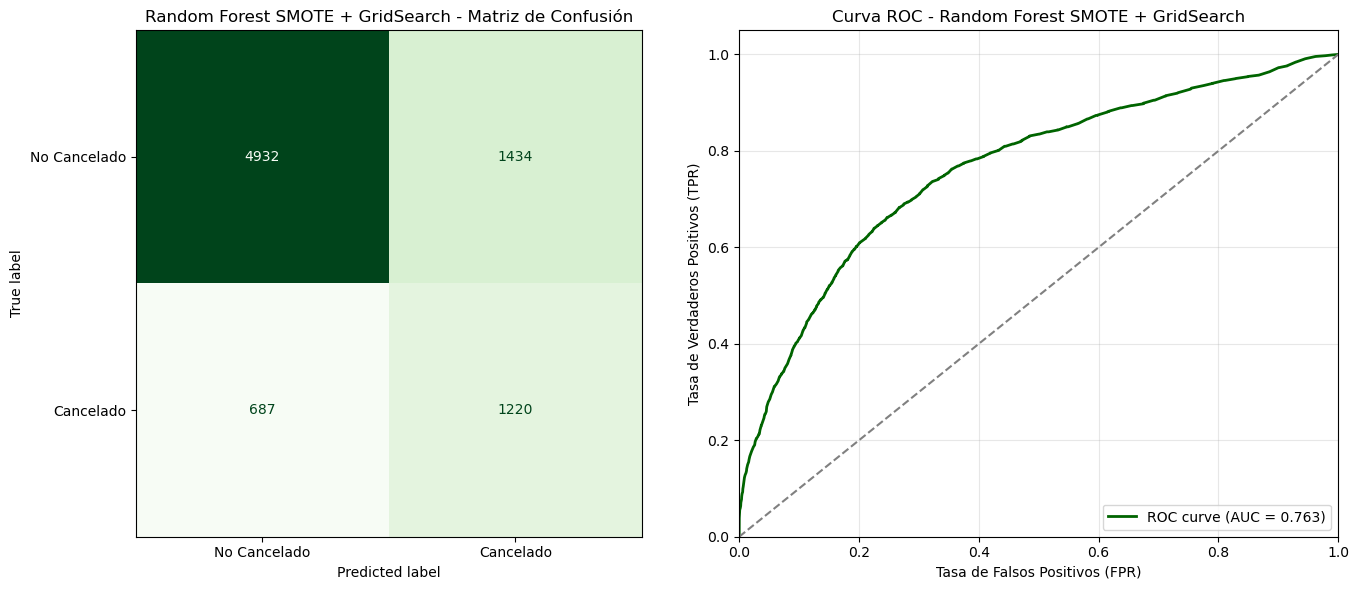

In [209]:
# --- 5. Matriz de Confusión + Curva ROC ---
cm_rf_grid_smote = confusion_matrix(y_test_pca, y_pred_rf_grid_smote_opt)
disp_rf_grid_smote = ConfusionMatrixDisplay(cm_rf_grid_smote, display_labels=['No Cancelado', 'Cancelado'])

fpr, tpr, thresholds = roc_curve(y_test_pca, y_proba_rf_grid_smote)
roc_auc = roc_auc_score(y_test_pca, y_proba_rf_grid_smote)

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Matriz de confusión
disp_rf_grid_smote.plot(cmap=plt.cm.Greens, ax=axes[0], colorbar=False, values_format='d')
axes[0].set_title("Random Forest SMOTE + GridSearch - Matriz de Confusión")

# Curva ROC
axes[1].plot(fpr, tpr, color='darkgreen', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[1].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
axes[1].set_title('Curva ROC - Random Forest SMOTE + GridSearch')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [210]:
# Classification Report
print("Random Forest SMOTE + GridSearch - Classification Report:\n")
print(classification_report(y_test_pca, y_pred_rf_grid_smote_opt, digits=4))


Random Forest SMOTE + GridSearch - Classification Report:

              precision    recall  f1-score   support

           0     0.8777    0.7747    0.8230      6366
           1     0.4597    0.6397    0.5350      1907

    accuracy                         0.7436      8273
   macro avg     0.6687    0.7072    0.6790      8273
weighted avg     0.7814    0.7436    0.7566      8273



In [211]:
# Métricas
metricas_RF_GRID_SMOTE = pd.DataFrame({
    "Accuracy": [accuracy_score(y_test_pca, y_pred_rf_grid_smote_opt)],
    "Precision": [precision_score(y_test_pca, y_pred_rf_grid_smote_opt)],
    "Recall": [recall_score(y_test_pca, y_pred_rf_grid_smote_opt)],
    "F1-score": [f1_score(y_test_pca, y_pred_rf_grid_smote_opt)],
    "ROC-AUC": [roc_auc_score(y_test_pca, y_proba_rf_grid_smote)]
}, index=["Random Forest SMOTE + GridSearch"])

print(metricas_RF_GRID_SMOTE)

                                  Accuracy  Precision    Recall  F1-score  \
Random Forest SMOTE + GridSearch  0.743624   0.459683  0.639748   0.53497   

                                   ROC-AUC  
Random Forest SMOTE + GridSearch  0.762521  


### Comparacion los cuatro modelos de RANDOM FOREST

In [212]:
metricas_modelos_rf = pd.concat([
    metricas_RANDOM_FOREST,
    metricas_RF_GRID,
    metricas_RF_SMOTE,
    metricas_RF_GRID_SMOTE
])
print(metricas_modelos_rf)

                                  Accuracy  Precision    Recall  F1-score  \
Random Forest (Mejor Umbral)      0.726943   0.440621  0.684845  0.536235   
Random Forest GridSearch          0.728635   0.442751  0.685370  0.537971   
Random Forest SMOTE               0.736613   0.450725  0.652334  0.533105   
Random Forest SMOTE + GridSearch  0.743624   0.459683  0.639748  0.534970   

                                   ROC-AUC  
Random Forest (Mejor Umbral)      0.762887  
Random Forest GridSearch          0.767512  
Random Forest SMOTE               0.760707  
Random Forest SMOTE + GridSearch  0.762521  


# =========================================

## TABLA FINAL TODOS LOS MODELOS (COMPARACIÓN)

In [213]:
# TABLA FINAL CON TODOS LOS MODELOS Y TODAS LAS MÉTRICAS


# REGRESIÓN LOGÍSTICA
metricas_modelos_regresion_logistica["Modelo"] = metricas_modelos_regresion_logistica.index
metricas_modelos_regresion_logistica["Algoritmo"] = "Logistic Regression"

# NAIVE BAYES
metricas_modelos_naive_bayes["Modelo"] = metricas_modelos_naive_bayes.index
metricas_modelos_naive_bayes["Algoritmo"] = "Naive Bayes"

# SVM (NO CARGADO → COMENTADO)
metricas_modelos_svm["Modelo"] = metricas_modelos_svm.index
metricas_modelos_svm["Algoritmo"] = "Support Vector Machine"

# ÁRBOL DE DECISIÓN
metricas_modelos_arbol["Modelo"] = metricas_modelos_arbol.index
metricas_modelos_arbol["Algoritmo"] = "Decision Tree"

# RANDOM FOREST
metricas_modelos_rf["Modelo"] = metricas_modelos_rf.index
metricas_modelos_rf["Algoritmo"] = "Random Forest"



# UNIÓN FINAL DE TODOS LOS MODELOS
tabla_metricas_final = pd.concat([
    metricas_modelos_regresion_logistica,
    metricas_modelos_naive_bayes,
    metricas_modelos_svm,   # SVM NO CARGADO
    metricas_modelos_arbol,
    metricas_modelos_rf])

# Reordenar columnas
tabla_metricas_final = tabla_metricas_final[
    ["Algoritmo", "Modelo", "Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]]

# Reset index para presentación
tabla_metricas_final = tabla_metricas_final.reset_index(drop=True)


# NORMALIZAR LA COLUMNA "Modelo"
def etiquetar_modelo(nombre):
    nombre = nombre.lower()
    if "smote" in nombre and "grid" in nombre:
        return "SMOTE + GridSearch"
    elif "smote" in nombre:
        return "SMOTE"
    elif "grid" in nombre:
        return "GridSearch"
    else:
        return "Baseline"

tabla_metricas_final["Modelo"] = tabla_metricas_final["Modelo"].apply(etiquetar_modelo)


# Ordenar:
tabla_metricas_final["ROC_AUC_round"] = tabla_metricas_final["ROC-AUC"].round(3)

tabla_metricas_final = tabla_metricas_final.sort_values(
    by=["ROC_AUC_round", "F1-score", "Recall"],
    ascending=[False, False, False]
).drop(columns="ROC_AUC_round").reset_index(drop=True)

# Mostrar tabla final
print("TABLA FINAL TODOS LOS MODELOS Y MÉTRICAS\n")
print(tabla_metricas_final)


TABLA FINAL TODOS LOS MODELOS Y MÉTRICAS

                 Algoritmo              Modelo  Accuracy  Precision    Recall  \
0            Random Forest          GridSearch  0.728635   0.442751  0.685370   
1            Random Forest            Baseline  0.726943   0.440621  0.684845   
2            Random Forest  SMOTE + GridSearch  0.743624   0.459683  0.639748   
3            Random Forest               SMOTE  0.736613   0.450725  0.652334   
4   Support Vector Machine               SMOTE  0.718724   0.427536  0.649712   
5   Support Vector Machine  SMOTE + GridSearch  0.718724   0.427536  0.649712   
6   Support Vector Machine          GridSearch  0.747129   0.460283  0.562139   
7      Logistic Regression               SMOTE  0.675209   0.385764  0.690614   
8      Logistic Regression          GridSearch  0.674000   0.385041  0.693760   
9      Logistic Regression            Baseline  0.674483   0.385356  0.692711   
10     Logistic Regression  SMOTE + GridSearch  0.678110   0.387433

Conclusion: <br>
Aunque el modelo Random Forest sin balanceo presenta un valor de ROC-AUC ligeramente superior, la diferencia respecto al modelo Random Forest con SMOTE y GridSearch es marginal. En cambio, este último muestra una mejora sustancial en el F1-score y, especialmente, en el recall, lo que indica una mayor capacidad para detectar correctamente la clase minoritaria. Por este motivo, el modelo Random Forest con SMOTE y GridSearch se selecciona como el modelo final.

In [ ]:
# Ordenar por ROC-AUC descendente
tabla_metricas_final = tabla_metricas_final.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)
tabla_metricas_final

#Guardar la tabla final como CSV
tabla_metricas_final.to_csv("Datos/Transformados/metricas_modelos_comparacion_PCA.csv", index=False)

,Algoritmo,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Random Forest,GridSearch,0.728635,0.442751,0.685370,0.537971,0.767512
1,Random Forest,Baseline,0.726943,0.440621,0.684845,0.536235,0.762887
2,Random Forest,SMOTE + GridSearch,0.743624,0.459683,0.639748,0.534970,0.762521
3,Random Forest,SMOTE,0.736613,0.450725,0.652334,0.533105,0.760707
4,Support Vector Machine,SMOTE,0.718724,0.427536,0.649712,0.515713,0.742739
5,Support Vector Machine,SMOTE + GridSearch,0.718724,0.427536,0.649712,0.515713,0.742739
6,Support Vector Machine,GridSearch,0.747129,0.460283,0.562139,0.506138,0.737426
7,Logistic Regression,SMOTE,0.675209,0.385764,0.690614,0.495020,0.733420
8,Logistic Regression,SMOTE + GridSearch,0.678110,0.387433,0.682223,0.494207,0.732427
9,Logistic Regression,GridSearch,0.674000,0.385041,0.693760,0.495227,0.732325


# MEJOR MODELO ENTRENARLO (TRAIN-TEST METRICAS)

In [215]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, roc_curve, make_scorer)
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [216]:
# Balanceo de Train con SMOTE:
# SMOTE aumenta las clases minoritarias para balancear el dataset
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print(f"Tamaño X_train después de SMOTE: {X_train_res.shape}, y_train: {y_train_res.shape}")

Tamaño X_train después de SMOTE: (63660, 120), y_train: (63660,)


In [217]:
# Definir random forest + gridsearch
# Ajustamos los hiperparámetros para reducir sobreajuste
rf = RandomForestClassifier(random_state=42)

# Evitamos max_depth=None y min_samples_leaf=1 para que los árboles no memoricen
param_grid = {
    'n_estimators': [100, 200],          # Cantidad de árboles
    'max_depth': [5, 10],                # Profundidad máxima para evitar overfitting
    'min_samples_split': [5, 10],        # Mínimo de muestras para dividir un nodo
    'min_samples_leaf': [5, 10],         # Mínimo de muestras en una hoja
    'max_features': ['sqrt', 'log2']     # Número de features a considerar por split
}

# Validación cruzada estratificada para preservar proporciones de clases
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scorer = make_scorer(f1_score)  # Optimizamos GridSearch según F1-score

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring=scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1)

In [218]:
# Entrenar modelo
grid_rf.fit(X_train_res, y_train_res)
rf_best = grid_rf.best_estimator_
print("Mejores parámetros Random Forest (GridSearch + SMOTE):", grid_rf.best_params_)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Mejores parámetros Random Forest (GridSearch + SMOTE): {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 5, 'n_estimators': 200}


Metricas TRAIN

In [219]:
# MÉTRICAS TRAIN
# Predecimos probabilidades y clases sobre el train balanceado
y_proba_train = rf_best.predict_proba(X_train_res)[:, 1]
y_pred_train = rf_best.predict(X_train_res)

accuracy_train = accuracy_score(y_train_res, y_pred_train)
precision_train = precision_score(y_train_res, y_pred_train)
recall_train = recall_score(y_train_res, y_pred_train)
f1_train = f1_score(y_train_res, y_pred_train)
roc_auc_train = roc_auc_score(y_train_res, y_proba_train)

print("===== Métricas TRAIN (SMOTE + GridSearch) =====")
print(f"Accuracy: {accuracy_train:.4f}")
print(f"Precision: {precision_train:.4f}")
print(f"Recall: {recall_train:.4f}")
print(f"F1-score: {f1_train:.4f}")
print(f"ROC-AUC: {roc_auc_train:.4f}")

===== Métricas TRAIN (SMOTE + GridSearch) =====
Accuracy: 0.8076
Precision: 0.8175
Recall: 0.7920
F1-score: 0.8045
ROC-AUC: 0.8909


TEST

In [220]:
#  MEJOR UMBRAL SEGÚN F1 EN TEST
y_proba_test = rf_best.predict_proba(X_test)[:, 1]

# Se asume que la función 'encontrar_mejor_umbral' está definida y devuelve (threshold, f1)
best_threshold_rf, best_f1_rf = encontrar_mejor_umbral(
    model=rf_best,
    X_val=X_test,
    y_val=y_test,
    metrica="f1"
)

print(f"\nMejor umbral para Random Forest (Test): {best_threshold_rf:.2f}")
print(f"Mejor F1-score con ese umbral: {best_f1_rf:.4f}")

#  PREDICCIONES TEST CON EL UMBRAL ÓPTIMO
y_pred_test_opt = (y_proba_test >= best_threshold_rf).astype(int)


Mejor umbral para Random Forest (Test): 0.46
Mejor F1-score con ese umbral: 0.5607


Metricas TEST

In [221]:
#  MÉTRICAS TEST
accuracy_test = accuracy_score(y_test, y_pred_test_opt)
precision_test = precision_score(y_test, y_pred_test_opt)
recall_test = recall_score(y_test, y_pred_test_opt)
f1_test = f1_score(y_test, y_pred_test_opt)
roc_auc_test = roc_auc_score(y_test, y_proba_test)

print("\n===== Métricas TEST (Random Forest + SMOTE + Mejor Umbral) =====")
print(f"Accuracy: {accuracy_test:.4f}")
print(f"Precision: {precision_test:.4f}")
print(f"Recall: {recall_test:.4f}")
print(f"F1-score: {f1_test:.4f}")
print(f"ROC-AUC: {roc_auc_test:.4f}")


===== Métricas TEST (Random Forest + SMOTE + Mejor Umbral) =====
Accuracy: 0.7483
Precision: 0.4691
Recall: 0.6967
F1-score: 0.5607
ROC-AUC: 0.7935


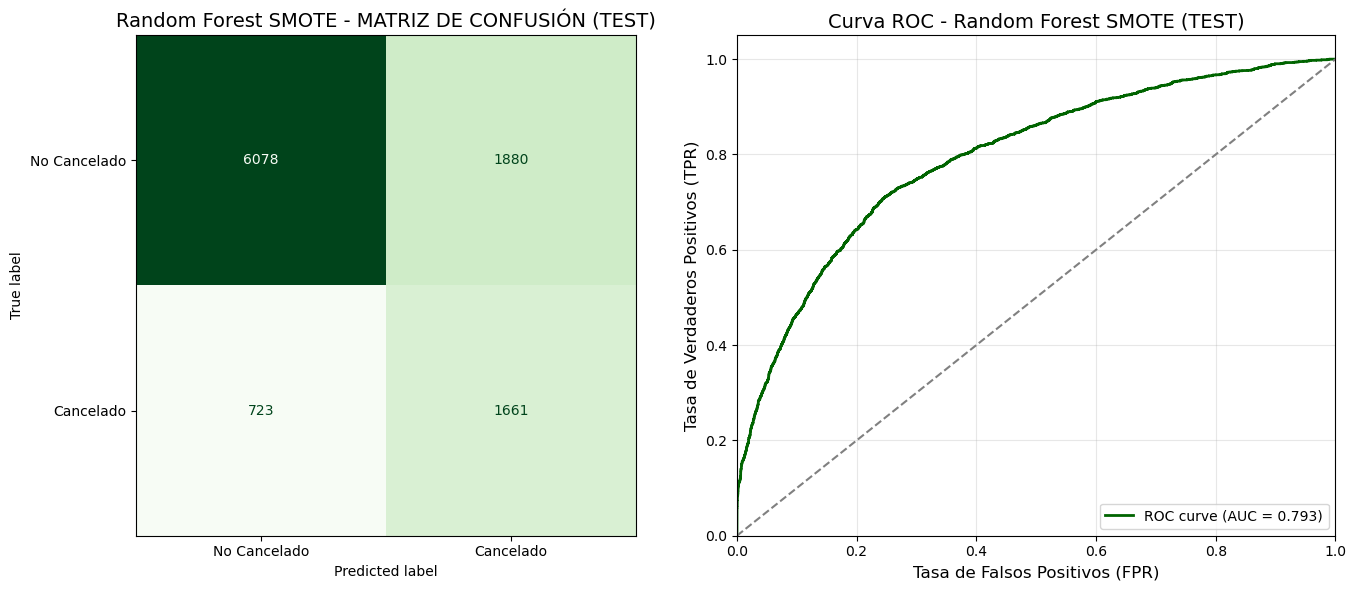

In [222]:
# MATRIZ DE CONFUSIÓN + CURVA ROC - CONJUNTO DE TEST

# Calculamos la matriz de confusión usando las predicciones con el mejor umbral
cm_rf_smote_test = confusion_matrix(y_test, y_pred_test_opt)

# Creamos un objeto para mostrar la matriz de confusión
disp_rf_smote_test = ConfusionMatrixDisplay(
    cm_rf_smote_test,
    display_labels=['No Cancelado', 'Cancelado']  # Etiquetas del target
)

# Calculamos la curva ROC y el AUC para el conjunto de TEST
fpr_test, tpr_test, thresholds_test = roc_curve(y_test, y_proba_test)
roc_auc_test = roc_auc_score(y_test, y_proba_test)

# Creamos la figura con 1 fila y 2 columnas
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Matriz de confusión
disp_rf_smote_test.plot(
    cmap=plt.cm.Greens,   # Color verde para diferenciar del train
    ax=axes[0],           # Primer subplot
    colorbar=False,       # Sin barra de colores
    values_format='d'     # Números enteros
)
axes[0].set_title("Random Forest SMOTE - MATRIZ DE CONFUSIÓN (TEST)", fontsize=14)

# Curva ROC
axes[1].plot(fpr_test, tpr_test, color='darkgreen', lw=2, 
             label=f'ROC curve (AUC = {roc_auc_test:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--')  # Línea diagonal (aleatorio)
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
axes[1].set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
axes[1].set_title('Curva ROC - Random Forest SMOTE (TEST)', fontsize=14)
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


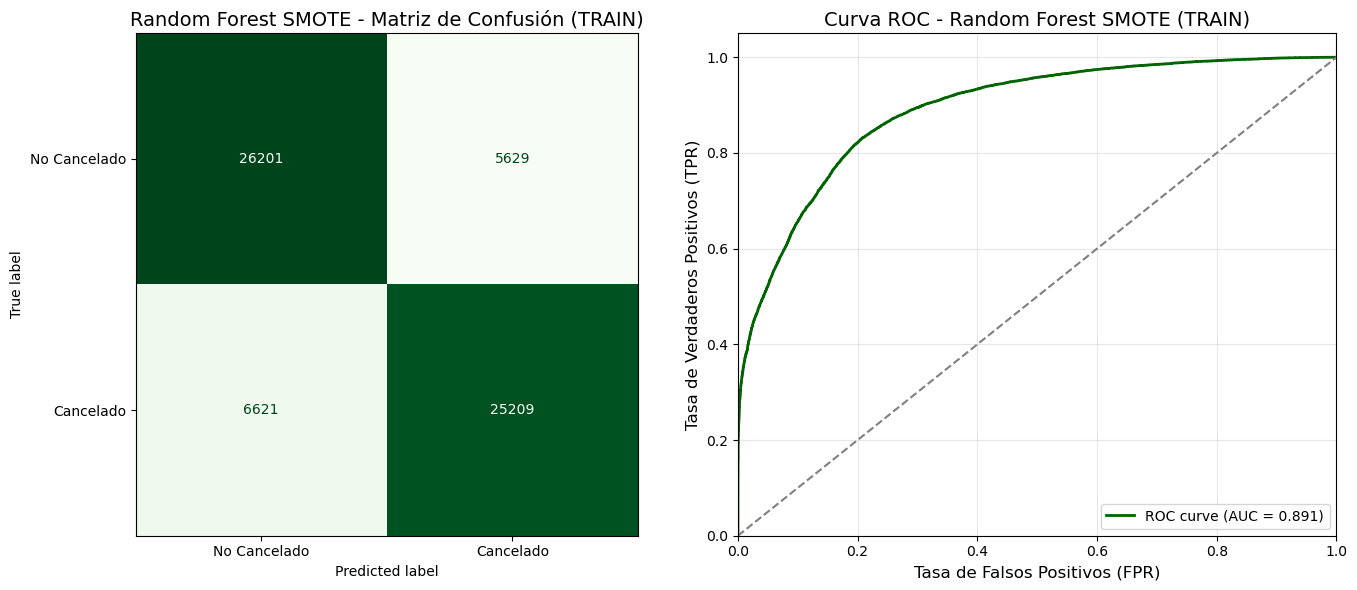

In [223]:
# MATRIZ DE CONFUSIÓN + CURVA ROC - CONJUNTO DE TRAIN
# Usamos las predicciones y probabilidades del modelo entrenado con SMOTE

# Calculamos la matriz de confusión para TRAIN
cm_rf_smote_train = confusion_matrix(y_train_res, y_pred_train)
disp_rf_smote_train = ConfusionMatrixDisplay(
    cm_rf_smote_train,
    display_labels=['No Cancelado', 'Cancelado']
)

# Calculamos la curva ROC y AUC para TRAIN
fpr_train, tpr_train, thresholds_train = roc_curve(y_train_res, y_proba_train)
roc_auc_train = roc_auc_score(y_train_res, y_proba_train)

# Creamos figura con 1 fila y 2 columnas
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Matriz de confusión TRAIN
disp_rf_smote_train.plot(
    cmap=plt.cm.Greens,   # Azul para TRAIN
    ax=axes[0],
    colorbar=False,
    values_format='d'
)
axes[0].set_title("Random Forest SMOTE - Matriz de Confusión (TRAIN)", fontsize=14)

# Curva ROC TRAIN
axes[1].plot(fpr_train, tpr_train, color='darkgreen', lw=2, 
             label=f'ROC curve (AUC = {roc_auc_train:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
axes[1].set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
axes[1].set_title('Curva ROC - Random Forest SMOTE (TRAIN)', fontsize=14)
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [224]:
#  TABLA FINAL DE MÉTRICAS
metricas_final_rf = pd.DataFrame({
    "Accuracy": [accuracy_train, accuracy_test],
    "Precision": [precision_train, precision_test],
    "Recall": [recall_train, recall_test],
    "F1-score": [f1_train, f1_test],
    "ROC-AUC": [roc_auc_train, roc_auc_test]
}, index=["TRAIN", "TEST"])

print("\n===== Tabla final de métricas Random Forest SMOTE + GridSearch =====")
print(metricas_final_rf)


===== Tabla final de métricas Random Forest SMOTE + GridSearch =====
       Accuracy  Precision    Recall  F1-score   ROC-AUC
TRAIN  0.807571   0.817465  0.791989  0.804525  0.890913
TEST   0.748308   0.469077  0.696728  0.560675  0.793484


# MODELO REGRESION LOGISTICA (COEFICIENTES, ODDS RATIOS)

### Entrenar modelo de Regresion Logistica:

In [225]:
# Definir modelo base para Gridsearch:
log_reg = LogisticRegression(
    max_iter=10000,
    class_weight="balanced",
    solver="saga")

In [226]:
# Definir el grid de parametros:
param_grid = {
    "penalty": ["l1", "l2", "elasticnet"],
    "C": [0.01, 0.1, 1, 10],
    "l1_ratio": [0.2, 0.5, 0.8]}

In [227]:
grid_logreg = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    scoring="f1",     
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_logreg.fit(X_train, y_train)
print("Mejores parámetros:", grid_logreg.best_params_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Mejores parámetros: {'C': 10, 'l1_ratio': 0.2, 'penalty': 'l2'}


In [228]:
# Entrenar el mejor modelo
modelo_regresion_logistica = grid_logreg.best_estimator_
modelo_regresion_logistica.fit(X_train, y_train)

LogisticRegression(C=10, class_weight='balanced', l1_ratio=0.2, max_iter=10000,
                   solver='saga')

In [229]:
# Prediccion:
y_prob = modelo_regresion_logistica.predict_proba(X_test)[:,1]
y_pred = (y_prob >= 0.55).astype(int)

In [230]:
# Metricas
nombre_modelo = "Regresion Logistica"

# Calcular métricas globales
fila_resultados = {
    "Modelo": nombre_modelo,
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_prob)  # y_proba = predict_proba[:,1]
}

# Crear tabla
tabla_simple = pd.DataFrame([fila_resultados]).round(4)

display(tabla_simple)


,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Regresion Logistica,0.7354,0.448,0.6372,0.5261,0.7645


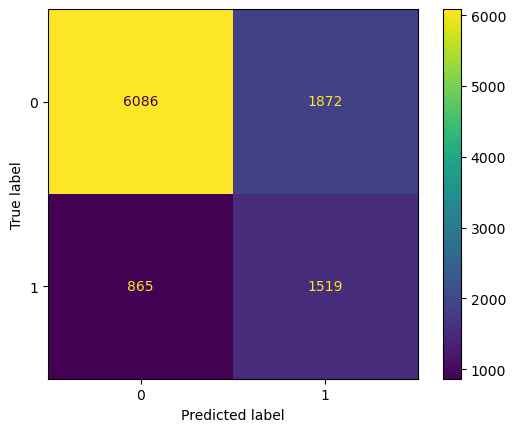

In [231]:
# Confusion Matrix:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()


# Interpretación de Coeficientes y Odds Ratios en Regresión Logística (Reservas de Hotel)

## Coeficientes 
- Representan el **impacto lineal** de cada variable en el **logaritmo de las probabilidades** de que una reserva sea cancelada.
- **Positivo** → Aumenta la probabilidad de que la reserva se cancele.
- **Negativo** → Disminuye la probabilidad de cancelación (más probabilidad de checkout).
- Se mide en unidades de log-odds, no directamente en probabilidad.

## Odds Ratios (OR)
- Calculados como `OR = exp(coeficiente)`.
- Transforman el coeficiente de la regresión logística en **probabilidad relativa**, lo que facilita la interpretación.
- **OR > 1** → La variable aumenta la probabilidad de que la reserva sea cancelada.
- **OR < 1** → La variable disminuye la probabilidad de cancelación (más chance de checkout).
- Ejemplos de tu caso:
  - `length_of_stay` OR = 849 → A mayor duración de la estancia, la probabilidad de cancelación aumenta muchísimo.
  - `lead_time` OR = 230 → Reservas hechas con mucha antelación tienen mayor probabilidad de cancelación.
  - `City_Donosti` OR = 0.97 → Estar en esta ciudad reduce ligeramente la probabilidad de cancelación.
  - `checkin_day_Monday` OR = 1.0029 → Casi no tiene efecto sobre la cancelación.
  

## En conclusion: 

| Métrica       | Qué muestra                        | Interpretación |
|---------------|-----------------------------------|----------------|
| Coeficiente   | Impacto lineal en logit           | (+) aumenta probabilidad de cancelación, (-) disminuye |
| Odds Ratio    | Probabilidad relativa              | OR >1 aumenta cancelación, OR <1 disminuye cancelación |


Los coeficientes muestran **dirección y magnitud en logit**, mientras que los Odds Ratios muestran **efecto relativo en probabilidad**, más fácil de explicar a alguien que no entienda log-odds.


In [232]:
# Calcular coeficientes y odds ratios:
coeficientes = modelo_regresion_logistica.coef_[0]
variables = X_train.columns

odds_ratios = np.exp(coeficientes)

# Crear tabla combinada
tabla_coef_odd = pd.DataFrame({
    "Variables": variables,
    "Coeficiente": coeficientes,
    "Odds Ratio": odds_ratios
})

# Ordenar por magnitud del coeficiente
tabla_coef_odd = tabla_coef_odd.reindex(tabla_coef_odd["Coeficiente"].abs().sort_values(ascending=False).index)

print(tabla_coef_odd.round(4))


                                   Variables  Coeficiente  Odds Ratio
3                             lenght_of_stay       9.0212   8277.0528
0                                  lead_time       7.8646   2603.3689
62        business_segment_Travel Individual       2.5998     13.4613
57       business_segment_Leisure Individual       2.3838     10.8461
55      business_segment_Business Individual       2.3253     10.2296
..                                       ...          ...         ...
93   nombre_DONOSTIA / SAN SEBASTIÁN, IGELDO       0.0092      1.0092
109                           ciudad_Donosti       0.0092      1.0092
82                Reserva_Dia_Semana_Tuesday       0.0086      1.0087
53     asset_Líbere Valencia Jardín Botánico      -0.0035      0.9965
67                   Estacion_Reserva_Spring       0.0017      1.0017

[120 rows x 3 columns]


### Analisis de coeficientes y oddsratios

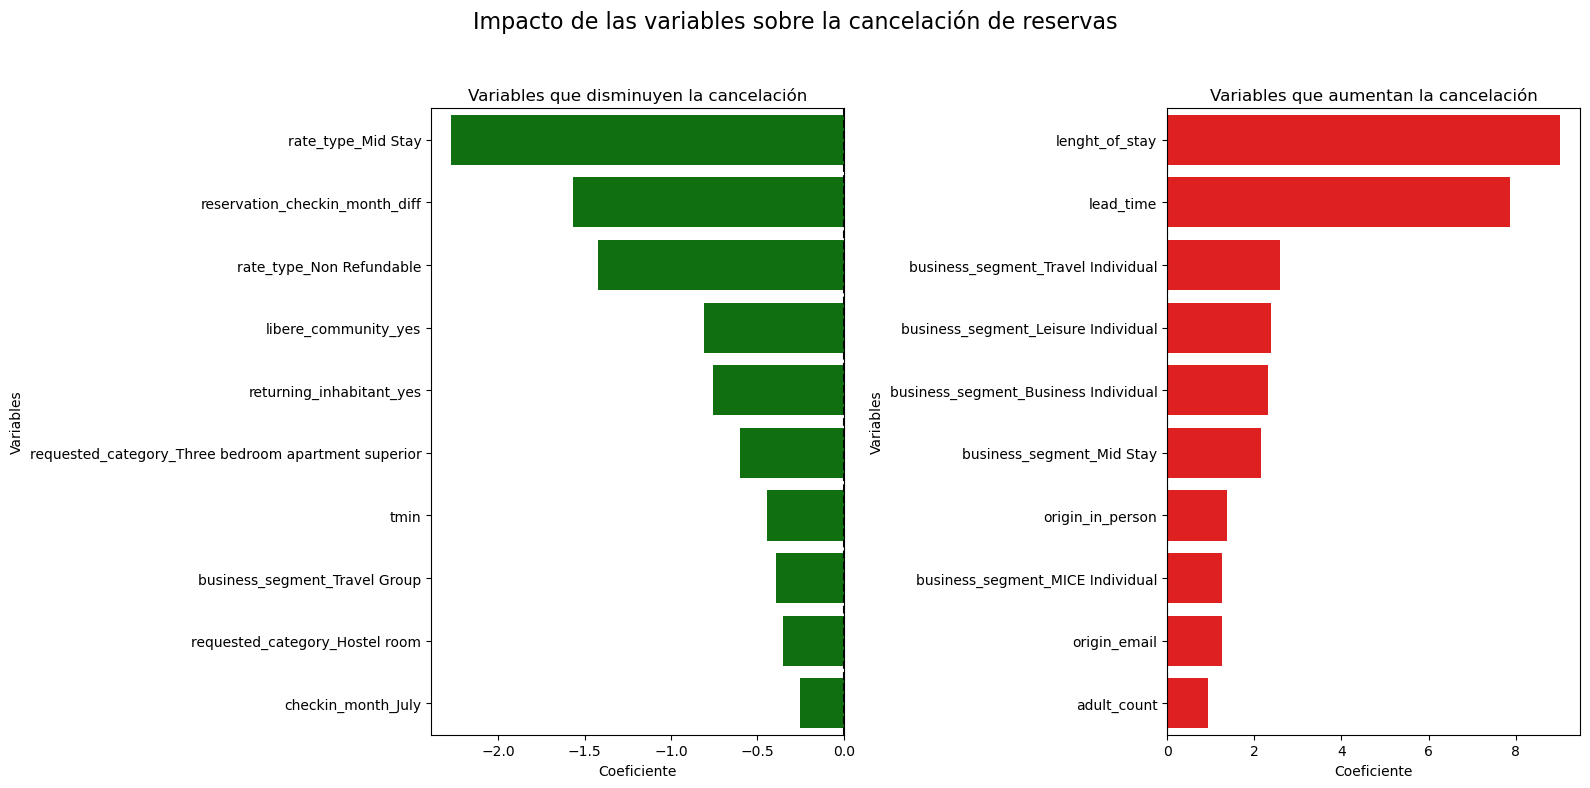

In [233]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1️⃣ Crear una nueva columna 'Signo':
# Indica si la variable aumenta o disminuye la cancelación
# Positivo → aumenta la probabilidad de cancelación
# Negativo → disminuye la probabilidad de cancelación
tabla_coef_odd['Signo'] = tabla_coef_odd['Coeficiente'].apply(
    lambda x: 'Aumenta cancelación' if x > 0 else 'Disminuye cancelación'
)

# 2️⃣ Separar top 10 de cada tipo según valor absoluto del coeficiente
top_aumenta = tabla_coef_odd[tabla_coef_odd['Signo'] == 'Aumenta cancelación'].nlargest(10, 'Coeficiente')
top_disminuye = tabla_coef_odd[tabla_coef_odd['Signo'] == 'Disminuye cancelación'].nsmallest(10, 'Coeficiente')

# 3️⃣ Crear figura con 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# 4️⃣ Gráfico izquierdo: top 10 que disminuyen cancelación (verde)
sns.barplot(
    x='Coeficiente',
    y='Variables',
    data=top_disminuye,
    ax=axes[0],
    color='green'
)
axes[0].set_title("Variables que disminuyen la cancelación")
axes[0].axvline(0, color='black', linestyle='--')

# 5️⃣ Gráfico derecho: top 10 que aumentan cancelación (rojo)
sns.barplot(
    x='Coeficiente',
    y='Variables',
    data=top_aumenta,
    ax=axes[1],
    color='red'
)
axes[1].set_title("Variables que aumentan la cancelación")
axes[1].axvline(0, color='black', linestyle='--')

# 6️⃣ Ajustes finales
plt.suptitle("Impacto de las variables sobre la cancelación de reservas", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


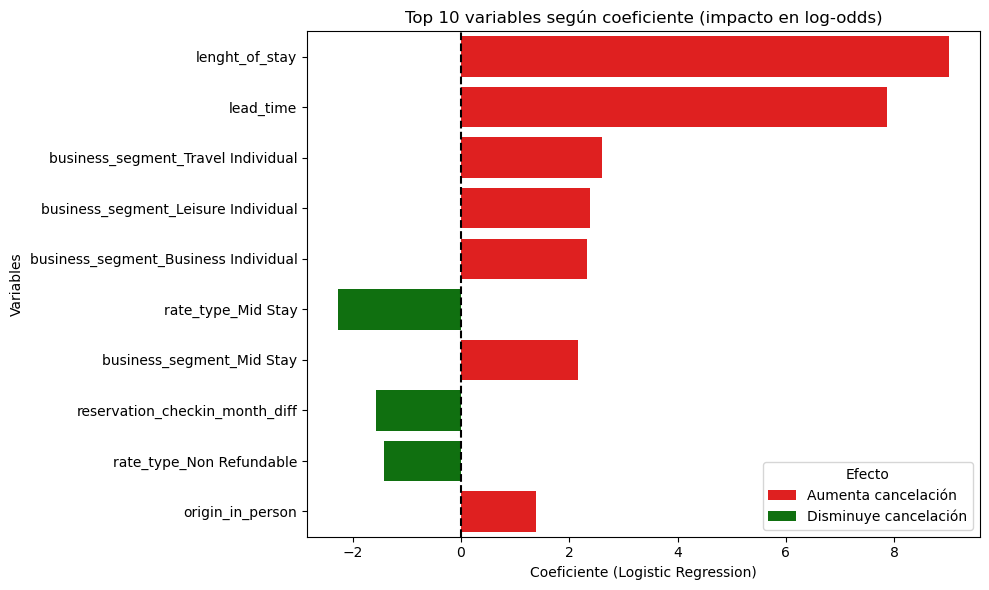

In [234]:
import matplotlib.pyplot as plt
import seaborn as sns
tabla_coef_odd['Signo'] = tabla_coef_odd['Coeficiente'].apply(
    lambda x: 'Aumenta cancelación' if x > 0 else 'Disminuye cancelación'
)

# Top 10 por magnitud de coeficiente
tabla_top10_coef = tabla_coef_odd.head(10)

plt.figure(figsize=(10,6))
sns.barplot(
    x='Coeficiente', 
    y='Variables', 
    data=tabla_top10_coef, 
    hue='Signo', 
    dodge=False,
    palette={'Aumenta cancelación':'red', 'Disminuye cancelación':'green'}
)

plt.axvline(0, color='black', linestyle='--')
plt.title("Top 10 variables según coeficiente (impacto en log-odds)")
plt.xlabel("Coeficiente (Logistic Regression)")
plt.ylabel("Variables")
plt.legend(title='Efecto')
plt.tight_layout()
plt.show()


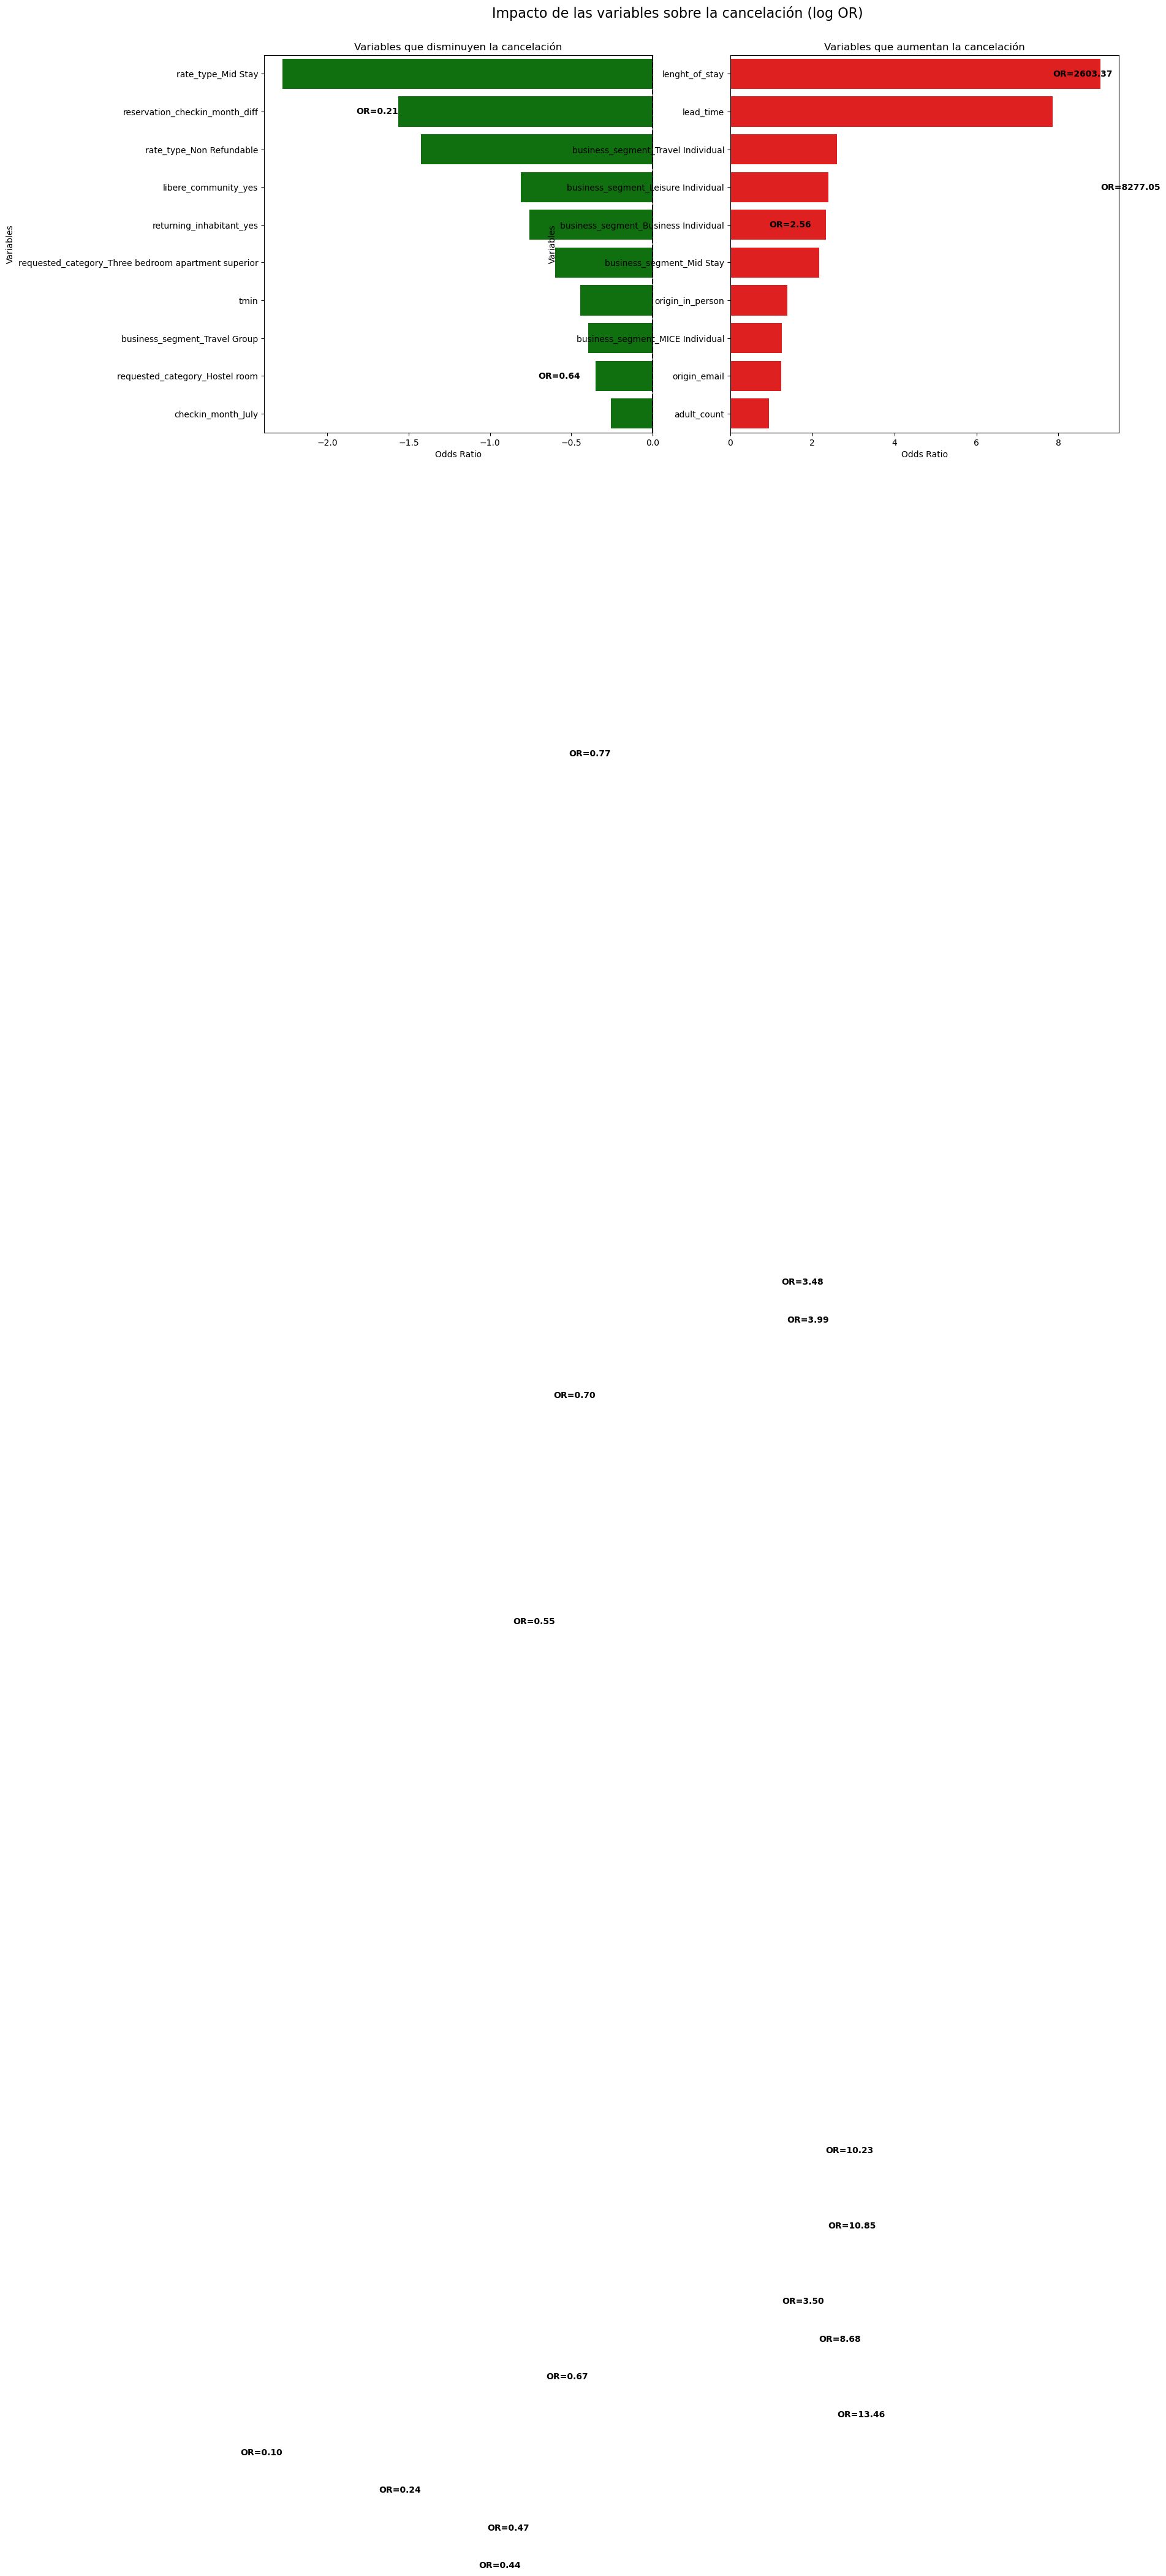

In [235]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1️⃣ Crear columna 'Signo'
tabla_coef_odd['Signo'] = tabla_coef_odd['Coeficiente'].apply(
    lambda x: 'Aumenta cancelación' if x > 0 else 'Disminuye cancelación'
)

# 2️⃣ Top 10 de cada tipo
top_aumenta = tabla_coef_odd[tabla_coef_odd['Signo']=='Aumenta cancelación'].nlargest(10,'Coeficiente')
top_disminuye = tabla_coef_odd[tabla_coef_odd['Signo']=='Disminuye cancelación'].nsmallest(10,'Coeficiente')

# 3️⃣ Crear figura
fig, axes = plt.subplots(1,2, figsize=(18,8))

# 4️⃣ Disminuyen cancelación (OR<1)
sns.barplot(
    x=np.log(top_disminuye['Odds Ratio']),
    y=top_disminuye['Variables'],
    ax=axes[0],
    color='green'
)
axes[0].set_title("Variables que disminuyen la cancelación")
axes[0].axvline(0, color='black', linestyle='--')
for i, row in top_disminuye.iterrows():
    axes[0].text(
        np.log(row['Odds Ratio']),
        i,
        f"OR={row['Odds Ratio']:.2f}",
        va='center',
        ha='right' if row['Coeficiente']<0 else 'left',
        fontweight='bold'
    )

# 5️⃣ Aumentan cancelación (OR>1)
sns.barplot(
    x=np.log(top_aumenta['Odds Ratio']),
    y=top_aumenta['Variables'],
    ax=axes[1],
    color='red'
)
axes[1].set_title("Variables que aumentan la cancelación")
axes[1].axvline(0, color='black', linestyle='--')
for i, row in top_aumenta.iterrows():
    axes[1].text(
        np.log(row['Odds Ratio']),
        i,
        f"OR={row['Odds Ratio']:.2f}",
        va='center',
        ha='right' if row['Coeficiente']<0 else 'left',
        fontweight='bold'
    )

# 6️⃣ Ajustes finales
plt.suptitle("Impacto de las variables sobre la cancelación (log OR)", fontsize=16)
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()


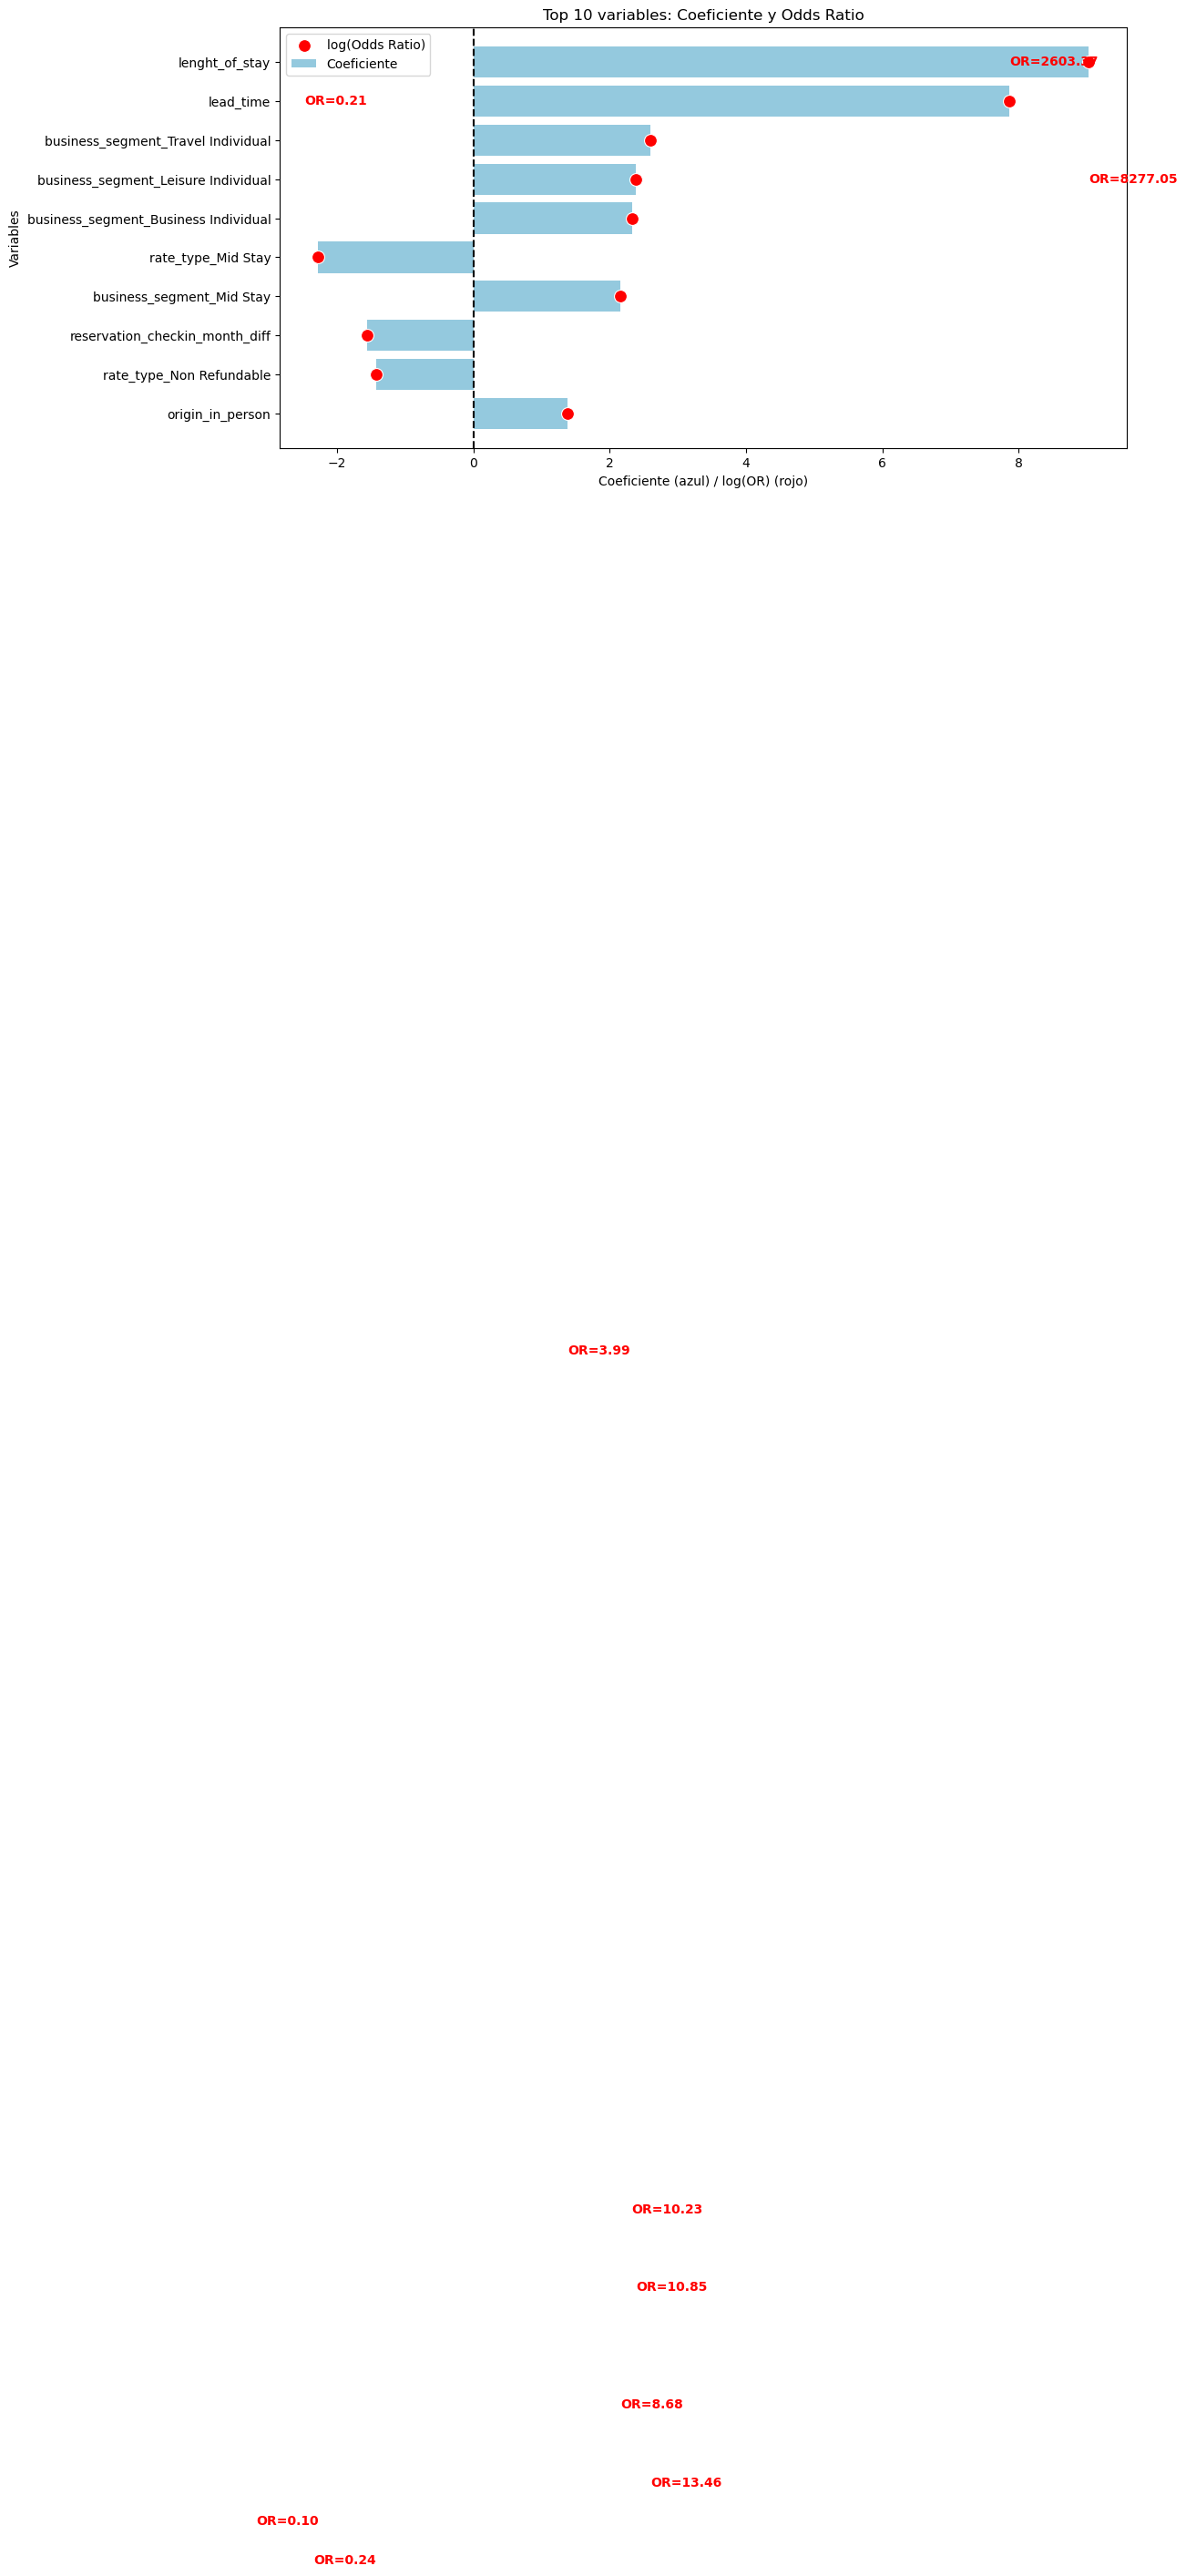

In [236]:
# Top 10 por magnitud de coeficiente
tabla_top10_comb = tabla_coef_odd.head(10).copy()

# Creamos una columna log(OR) para que se pueda graficar en la misma escala que el coeficiente
tabla_top10_comb['log(OR)'] = np.log(tabla_top10_comb['Odds Ratio'])
plt.figure(figsize=(12,6))

# Barra de coeficiente
sns.barplot(
    x='Coeficiente', 
    y='Variables', 
    data=tabla_top10_comb, 
    color='skyblue', 
    label='Coeficiente'
)

# Línea con los Odds Ratios (convertidos a log para la misma escala)
sns.scatterplot(
    x='log(OR)', 
    y='Variables', 
    data=tabla_top10_comb, 
    color='red', 
    s=100, 
    label='log(Odds Ratio)'
)

# Línea vertical en 0 para separar efecto positivo y negativo
plt.axvline(0, color='black', linestyle='--')

# Añadir texto con el valor de OR
for i, row in tabla_top10_comb.iterrows():
    plt.text(
        row['log(OR)'], 
        i, 
        f"OR={row['Odds Ratio']:.2f}", 
        color='red', 
        fontweight='bold',
        va='center',
        ha='left' if row['log(OR)']>0 else 'right'
    )

plt.title("Top 10 variables: Coeficiente y Odds Ratio")
plt.xlabel("Coeficiente (azul) / log(OR) (rojo)")
plt.ylabel("Variables")
plt.legend()
plt.tight_layout()
plt.show()


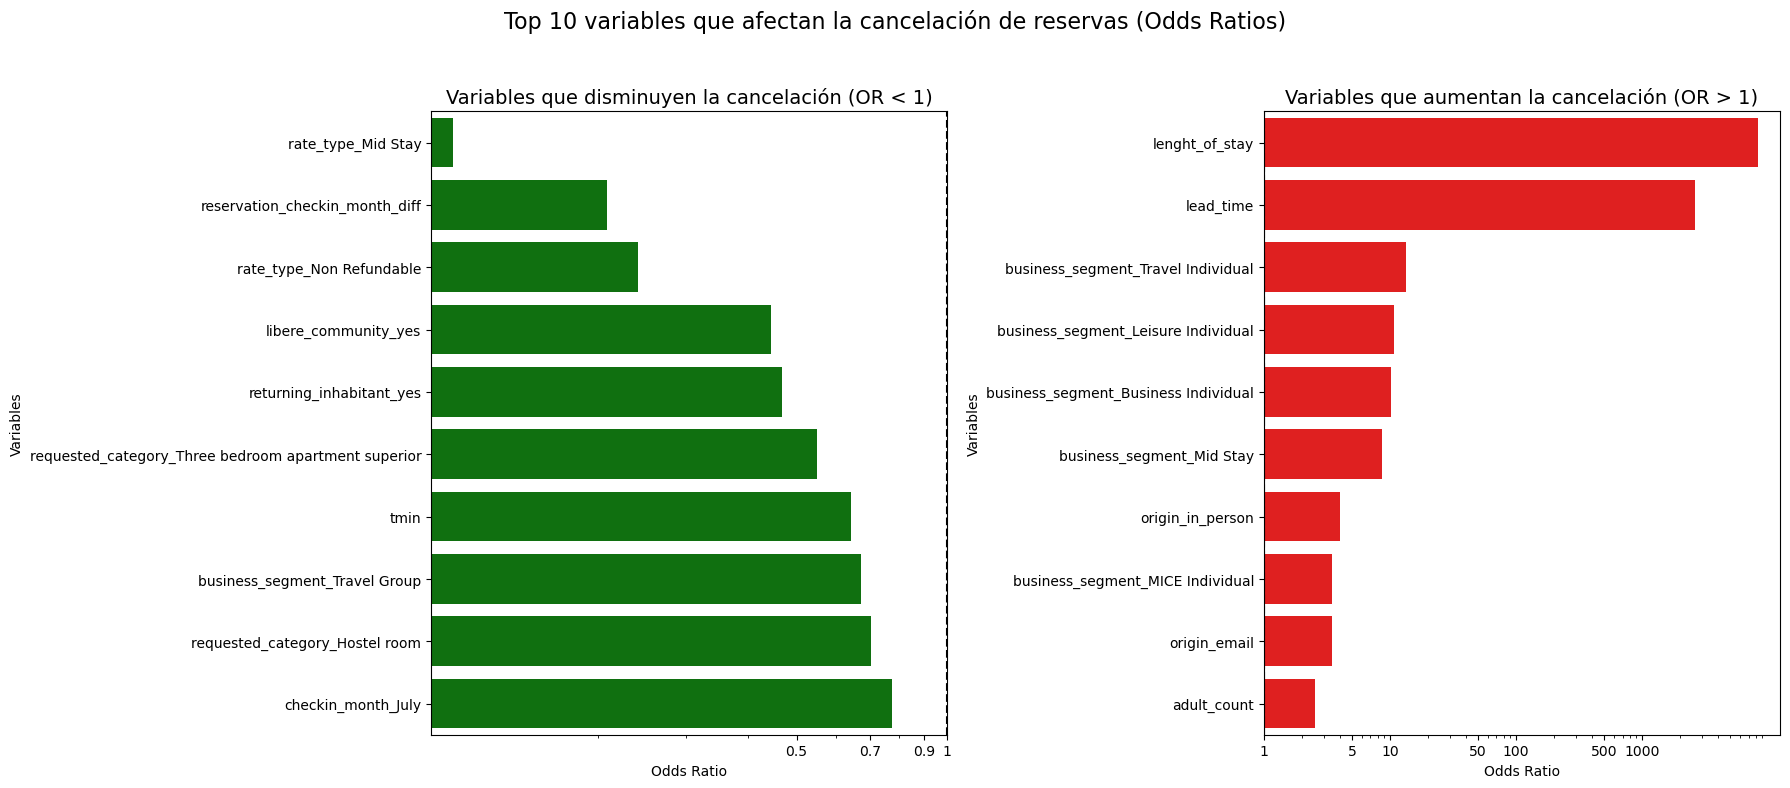

In [237]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1️⃣ Crear columna 'Signo' según Odds Ratio
tabla_coef_odd['Signo OR'] = tabla_coef_odd['Odds Ratio'].apply(
    lambda x: 'Aumenta cancelación' if x > 1 else 'Disminuye cancelación'
)

# 2️⃣ Seleccionar top 10 de cada tipo
top_aumenta = tabla_coef_odd[tabla_coef_odd['Signo OR'] == 'Aumenta cancelación'].nlargest(10, 'Odds Ratio')
top_disminuye = tabla_coef_odd[tabla_coef_odd['Signo OR'] == 'Disminuye cancelación'].nsmallest(10, 'Odds Ratio')

# 3️⃣ Crear figura con 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# 4️⃣ Gráfico izquierdo: top 10 que disminuyen cancelación (verde)
sns.barplot(
    x='Odds Ratio',
    y='Variables',
    data=top_disminuye,
    ax=axes[0],
    color='green'
)
axes[0].set_title("Variables que disminuyen la cancelación (OR < 1)", fontsize=14)
axes[0].set_xscale('log')
axes[0].set_xticks([0.5, 0.7, 0.9, 1])
axes[0].set_xticklabels([0.5, 0.7, 0.9, 1])
axes[0].axvline(1, color='black', linestyle='--')  # referencia OR=1

# 5️⃣ Gráfico derecho: top 10 que aumentan cancelación (rojo)
sns.barplot(
    x='Odds Ratio',
    y='Variables',
    data=top_aumenta,
    ax=axes[1],
    color='red'
)
axes[1].set_title("Variables que aumentan la cancelación (OR > 1)", fontsize=14)
axes[1].set_xscale('log')
axes[1].set_xticks([1, 5, 10, 50, 100, 500, 1000])
axes[1].set_xticklabels([1, 5, 10, 50, 100, 500, 1000])
axes[1].axvline(1, color='black', linestyle='--')  # referencia OR=1

# 6️⃣ Ajustes finales
plt.suptitle("Top 10 variables que afectan la cancelación de reservas (Odds Ratios)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
